# *Setup*

In [ ]:
# 1. SETUP
source("/mc_disk1/data/Maiia_hemato_images/Image_analysis_functions.R")
load_project_libraries()

In [10]:
type_colors <- c(
    "CD41"   = "#FF00FF",   # Neon Magenta
    "F4_80"  = "#00FFFF",   # Electric Cyan
    "S100A8" = "#FFD700",   # Solid Gold / Yellow
    "none"   = "gray50"     # Distinct, readable mid-gray text/borders
)
# Master Lowercase Palette for Composites & Reference Maps
GLOBAL_MAP_COLORS <- c(
  "cd41"   = "#FF00FF", 
  "f4_80"  = "#00FFFF", 
  "s100a8" = "#FFD700", 
  "none"   = "#E0E0E0"
)

# Master Uppercase Palette for Base R Text Plots
GLOBAL_TEXT_COLORS <- c(
  "CD41"   = "#FF00FF", 
  "F4_80"  = "#00FFFF", 
  "S100A8" = "#FFD700", 
  "none"   = "gray50"
)

# Functions
## vecsplit

In [11]:
vecsplit = function(strvec, del, i) {
#	 unlist(lapply(sapply(strvec, strsplit, del), "[[", i))
    apply(sapply(i, function(j) unlist(lapply(sapply(strvec, strsplit, del), "[[", j))),
        1, paste0, collapse = del)
}

## Date str

In [12]:

date_str <- function(year, month, day, format = "%Y_%m_%d") {
  format(as.Date(sprintf("%04d-%02d-%02d", year, month, day)), format)
}

## Calc poly Area

In [13]:
poly_area <- function(x, y) {
  abs(sum(x * c(y[-1], y[1]) - y * c(x[-1], x[1]))) / 2
}

## Intensity helper

In [14]:

measure_intensity_q95 <- function(pixels) {
  # Fast 95th percentile calculation
  return(collapse::fquantile(pixels, probs = 0.95, names = FALSE))
}

measure_intensity_q90 <- function(pixels) {
  # Fast 90th percentile calculation
  return(collapse::fquantile(pixels, probs = 0.90, names = FALSE))
}

## Get Image Marker 

In [15]:
get_image_marker_conf <- function(data_roi, series_name) {
  # 1. Find all image keys that belong to this specific series
  series_keys <- grep(series_name, names(data_roi), value = TRUE, ignore.case = TRUE)
  # 2. Extract the marker by explicitly removing the series prefix
  # e.g., Remove "M2_Series001_" so "M2_Series001_F4_80" safely becomes "F4_80"
  prefix_to_remove <- paste0(series_name, "_")
  extracted_labels <- gsub(prefix_to_remove, "", series_keys, ignore.case = TRUE)
  # Optional: return as a named vector for easy mapping
  names(series_keys) <- extracted_labels
  return(series_keys)
}

## Rename Images Names 

channels:
- ch00 <-> Dapi
- ch01 <-> S100A8
- ch02 <-> CD41
- ch03 <-> F4_80

In [16]:
robust_rename_images_il1b <- function(current_names) {
  library(stringr)
  library(dplyr) # Required for case_when
  # 1. Extract components (Vectorized)
  # Extract everything BEFORE the channel indicator
  prefix_part <- str_extract(current_names, "^.*?(?=[Cc]h\\d+)")
  # Extract the file extension (e.g., .tif, .tiff, .png)
  ext_part <- str_extract(current_names, "\\.[a-zA-Z0-9]+$")
  ext_part <- ifelse(is.na(ext_part), "", ext_part) # Failsafe for no extension
  # Extract just the NUMERIC part of the channel (solves the 01 vs 001 problem entirely!)
  channel_num <- as.numeric(str_extract(tolower(current_names), "(?<=ch)\\d+"))
  # Extract the batch (m1, m2, m3, etc.)
  batch_pattern <- str_extract(tolower(current_names), "m\\d+")
  # 2. Vectorized logic for marker assignment
  channel_name <- case_when(
  channel_num == 0 ~ "Dapi",
  channel_num == 1 ~ "Il1b",
  channel_num == 2 ~ "CD41",
  channel_num == 3 ~ "F4_80",
  TRUE ~ "unknown"
  )
  
  # 3. Combine safely (Prefix + Marker Name + Extension)
  new_names <- paste0(prefix_part, channel_name, ext_part)
  
  return(new_names)
}


## Image Loader 

**Replaces all magick loading routines EBimage package**

One channel image files can sometimes be saved as multi-plane images with one plane containing the actual data and the others being empty.

Preserve the same logic as the function using magick(R) and process the dimension matrix of images IF.

In [17]:
read_image_to_matrix_ebimage <- function(file_path, transpose = FALSE) {
  if (!file.exists(file_path)) stop("[ERROR] Target file not found: ", file_path)

  img <- EBImage::readImage(file_path)
  img_dims <- dim(img)

  if (length(img_dims) > 2) {
    n_planes <- img_dims[3]
    plane_sd <- vapply(seq_len(n_planes), function(i) sd(img[, , i]), numeric(1))
    best_plane <- which.max(plane_sd)
    mat_array <- as.array(img[, , best_plane])
  } else {
    mat_array <- as.array(img)
  }

  if (transpose) mat_array <- t(mat_array)

  return(mat_array * 255)
}

## Load series image matrics 

In [18]:
library(stringr)

# Extracted File Loader Function
load_series_matrices <- function(series_id, markers_list, files_dict) {
  # Find keys belonging ONLY to this series (e.g., "M1_Series010_...")
  series_regex <- paste0("^", series_id, "_")
  series_keys  <- stringr::str_subset(names(files_dict), stringr::regex(series_regex, ignore_case = TRUE))
  
  if (length(series_keys) == 0) return(NULL)
  
  ch_paths <- sapply(markers_list, function(marker) {
    clean_marker <- stringr::str_remove_all(marker, "_")
    clean_keys   <- stringr::str_remove_all(series_keys, "_")
    
    # Find the exact match
    match_idx <- which(stringr::str_detect(clean_keys, stringr::regex(clean_marker, ignore_case = TRUE)))
    
    if (length(match_idx) > 0) {
      return(files_dict[[ series_keys[match_idx[1]] ]])
    } else {
      return(NA_character_)
    }
  }, simplify = FALSE)
  
  # Drop missing markers and load the matrices
  ch_paths <- ch_paths[!is.na(ch_paths)]
  viz_images <- lapply(ch_paths, read_image_to_matrix_ebimage)
  names(viz_images) <- names(ch_paths)
  
  return(viz_images)
}

## Filters
should be done accordingly:
- Dapi, Il1b → No Filter
- F4/80, Clec4f, S100A8 → Gaussian Filter
- CD41 → Morphological Filter  - Shape & size, in order to discard the platelets.

### Morphological Filter 

Morphological filtering function by shape & size used for CD41

In [19]:
filter_cd41_morphological <- function(
  img_matrix,
  bg_brush_size = 255,
  median_size = 5,
  noise_floor = 0.03,
  min_cell_area = 2800,
  max_irregularity = 0.65,
  min_radius_mean = 40,
  return_mask = TRUE,
  otsu_multiplier = 0.50,
  max_intensity_image_pixel = 255,
  intensity_threshold_for_glare = 160,
  epsilon = 1e-5
) {
  zero_var  <-  0
  img_temp <- EBImage::Image(t(img_matrix) / max_intensity_image_pixel, colormode = "Grayscale")
  bg_kern  <- EBImage::makeBrush(size = bg_brush_size, shape = "disc")
  top_hat  <- EBImage::whiteTopHat(img_temp, bg_kern)
  smoothed  <- EBImage::medianFilter(top_hat, size = median_size)

  proc_mat <- t(as.array(smoothed))

  otsu_thresh <- EBImage::otsu(smoothed)
  mask_thresh <- max(noise_floor, otsu_thresh * otsu_multiplier)

  binary_mask <- proc_mat > mask_thresh
  filled_mask  <- EBImage::fillHull(binary_mask)

  labeled_components <- EBImage::bwlabel(filled_mask)
  object_features    <- EBImage::computeFeatures.shape(labeled_components)

  final_clean_mat   <- proc_mat * zero_var
  valid_pixels_mask <- matrix(FALSE, nrow = nrow(proc_mat), ncol = ncol(proc_mat))
  valid_cell_ids    <- integer(0)

  if (!is.null(object_features) && is.matrix(object_features) && nrow(object_features) > 0) {
    areas    <- object_features[, "s.area"]
    rad_sd   <- object_features[, "s.radius.sd"]
    rad_mean <- object_features[, "s.radius.mean"]
    shape_irregularity <- rad_sd / (rad_mean + epsilon)

    valid_cell_ids <- which(
      areas >= min_cell_area &
      shape_irregularity < max_irregularity &
      rad_mean >= min_radius_mean
    )

    if (length(valid_cell_ids) > zero_var) {
      valid_pixels_mask <- labeled_components %in% valid_cell_ids
      final_clean_mat[valid_pixels_mask] <- proc_mat[valid_pixels_mask]

      raw_glare_mask <- (img_matrix > intensity_threshold_for_glare) & valid_pixels_mask
      if (any(raw_glare_mask)) {
        final_clean_mat[raw_glare_mask] <- img_matrix[raw_glare_mask] / max_intensity_image_pixel
      }
    }
  }

  out <- list(
    clean_image = final_clean_mat * max_intensity_image_pixel,
    mk_mask = valid_pixels_mask,
    labels = labeled_components,
    features = object_features,
    kept_ids = valid_cell_ids
  )

  if (return_mask) out else out$clean_image
}

### Gaussian Filter

Image noise reduction used for the following markers: F4/80, Clec4f & S100A8.

In [20]:
filter_matrix_gaussian <- function(img_matrix, sigma = 1.5) {
  if (is.null(img_matrix) || !is.matrix(img_matrix)) {
    stop("Error in Gaussian: Input is NOT a matrix.")
  }
  # EBImage::Image expects (x,y), img_matrix is (row,col)
  img <- EBImage::Image(t(img_matrix) / 255, colormode = "Grayscale")
  # Gaussian blur (gblur) in EBImage is column-major aligned
  filtered <- EBImage::gblur(img, sigma = sigma)
  # Restore original R row-major orientation
  return(as.matrix(t(as.array(filtered)) * 255))
}

## PLot all channels

In [21]:
# plot all channels with labels (Updated to use color coding for labels and improved layout)

plot_all_channels <- function(nuclei_sub, data_sub, tiles, cell_types, output_file, image_height = 4000, image_width = 4000, mfrow_num = 2, mfcol_num = 2) {
    # Cells classified as "CD41" get Red, "F4_80" get Green & "none" get gray
    library(grid) 
    # type_colors <- c(
    #     "CD41" = "red", # Red
    #     "F4_80" = "green", # Green
    #     "CD41,F4_80" = "navy", # Yellow
    #     "F4_80,CD41" = "navy", # Yellow (order safety)
    #     "none" = "gray" # gray for unclassified cells
    # )
    type_colors <- c(
        "CD41"   = "magenta",      # Replaces Red
        "F4_80" = "springgreen4", # Darker, more legible Green
        # "S100A8" = "dodgerblue",   # Distinct from the other two
        "none"   = "gray70"
    )

    png(output_file, height = image_height, width = image_width)
    # Apply the requested 2x2 layout
    par(mfrow = c(mfrow_num, mfcol_num))
    # Loop through EVERY image (Dapi, Il1b, etc.)
    sapply(names(data_sub), function(img_name) {
        # 1. Draw Image
        image(seq_len(nrow(data_sub[[img_name]])), seq_len(ncol(data_sub[[img_name]])),
            data_sub[[img_name]],
            main = img_name, # Title is the channel name
            col = colorRampPalette(c("white", "chocolate", "black"))(1000),
            zlim = c(0, 255), axes = FALSE
        )

        grid(col = "black", lwd = 1)

        # 2. Draw Tiles (ALL channels) - This happens for Dapi, Il1b, CD41, and F4_80
        plot(tiles, pch = 20, cex = 0, add = TRUE, border = "blue", lwd = 1)

        if (grepl("Dapi|Il1b", img_name, ignore.case = TRUE)) {
            # --- ROW 1: PLOT OBJECT NUMBERS ---
            text(
                x = nuclei_sub$location_center_x,
                y = nuclei_sub$location_center_y,
                labels = nuclei_sub$number_object_number,
                col = "black", # Black is very visible on light backgrounds
                cex = 1.6, font = 2
            )
        } else {
            # --- ROW 2: PLOT CLASSIFICATION LABELS ---
            # (Matches anything NOT Dapi/Il1b, e.g. CD41, F4_80)

            txt_cols <- type_colors[cell_types]
            has_label <- !is.na(txt_cols)
            if (any(has_label)) {
                text(
                    x = nuclei_sub$location_center_x[has_label],
                    y = nuclei_sub$location_center_y[has_label],
                    labels = cell_types[has_label],
                    col = txt_cols[has_label],
                    cex = 1.6, font = 2
                )
            }
        }
    })
    dev.off()
}

 

## User Settings
### Dates Files

In [22]:
home_path <- "/mc_disk1/data/Maiia_hemato_images"
if (dir.exists(home_path)) {
    setwd(home_path)
} else {
    stop("Dir missing!")
}

In [23]:
JUN13 <- date_str(2026, 6, 13)
JUN14 <- date_str(2026, 6, 14)
# Create figs folders if they don't exist
image_analysis_results <- file.path(home_path, "image_analysis_results")
cellprofiler_output <- file.path(image_analysis_results, "cellprofiler_output")
cellprofiler_output_v2 <- file.path(image_analysis_results, "cellprofiler_output","v2")
image_analysis_results_figs <- file.path(image_analysis_results, "figures")
image_analysis_results_data <- file.path(image_analysis_results, "data")
JUN13_data <-  file.path(image_analysis_results_data, JUN13)
JUN13_figs <-  file.path(image_analysis_results_figs, JUN13)

nuclei_res_combined_path <- file.path(JUN13_data, paste0(JUN13, "_nuclei_data_combined.csv"))
updated_nuclei_full_data_path <-  file.path(JUN13_data, paste0(JUN13 ,"_cell_markers_and_intensity_combined_q95.csv"))
JUN13_figs_markers <- file.path(image_analysis_results_figs, paste0(JUN13,"_marker_labels"))
JUN13_data_markers <- file.path(image_analysis_results_data, paste0(JUN13,"_marker_labels"))
master_cluster_df_f  <- file.path(image_analysis_results_data, paste0(JUN13 ,"_E16_first5_images_neighbor_analysis_and_Il1b_mean_shuf.csv"))
master_cluster_df_new_f  <- file.path(image_analysis_results_data, paste0(JUN14 ,"_E16_all_clusters_neighbor_analysis_updated_batch_names.csv"))
JUN13_figs_neighbors <- file.path(image_analysis_results_figs, paste0(JUN13,"_neighbor_analysis_E16_5"))
JUN13_data_neighbors <- file.path(image_analysis_results_data, paste0(JUN13,"_neighbor_analysis_E16_5"))

dir_vec <- c( 
    image_analysis_results,
    cellprofiler_output,
    image_analysis_results_figs,
    image_analysis_results_data,
    JUN13_data,
    JUN13_figs,
    JUN13_figs_markers,
    JUN13_data_markers,
    JUN13_figs_neighbors,
    JUN13_data_neighbors
)
for (d in dir_vec) dir.create(d, recursive = TRUE, showWarnings = FALSE)

# *Config*

In [24]:
CONFIG <- list(
  INTENSITY_THRESH = 100,
  CORR_THRESH = 0.3,
  MIN_PIXELS = 20,
  MAX_RADIUS = 60,
  SIGMA_NOISE = 1.5,
  NEIGHBOR_TYPE = "F4_80",
  TARGET_TYPE = "CD41",
  MAX_DIST = 100,
  K_PERM = 5000,
  MAX_SIZE_IDX = 4e3,
  MIN_NUM_CLUST = 2,
  MARKERS_ALL = c("Dapi", "Il1b", "CD41", "F4_80"),
  MARKERS_CALC_INTENSITY = c("Il1b", "CD41", "F4_80"),
  MARKERS_ANALYSIS = c("CD41", "F4_80"),
  NOISY_CHANNELS = c("F4_80","CD41"),
  IL1B = "Il1b"
)


# Load Data

## Nuclei CSV
old version is commented 

In [37]:
nuclei_csv  <-  file.path(cellprofiler_output_v2, "Il1b_v2_nuclei.csv")
message(">>> Loading Metadata...")
nuclei_res <- read.csv(nuclei_csv) %>% 
    dplyr::select(where(~ !any(is.na(.)))) %>%
    rename_with(tolower) %>% 
    rename_with(str_trim) %>%
    rename_with(~ str_replace(., "^metadata_", "")) %>%
    dplyr::select(-starts_with("X"),-any_of(c("seriesfile.1","batch.1","frame","series")))   %>% 
    mutate(cell_id = paste(batch, seriesfile, number_object_number, sep = "_"),
        image_batch = paste(batch, seriesfile, sep = "_"),file_path = pathname_cd41) %>% 
    # as_factor(batch) %>% 
    relocate(cell_id,image_batch,batch,file_path)
nuclei_res %>% head()

>>> Loading Metadata...



,cell_id,image_batch,batch,file_path,imagenumber,objectnumber,seriesfile,sizec,sizet,sizez,⋯,pathname_cd41,pathname_f4_80,pathname_il1b,pathname_dapi,pathname_rgb,location_center_x,location_center_y,location_center_z,number_object_number,parent_identifyprimaryobjects
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<int>
1,M2_Series001_1,M2_Series001,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,1,Series001,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,535.9718,16.60484,0,1,1
2,M2_Series001_2,M2_Series001,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,2,Series001,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,668.1879,21.67953,0,2,2
3,M2_Series001_3,M2_Series001,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,3,Series001,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,152.7568,21.16717,0,3,3
4,M2_Series001_4,M2_Series001,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,4,Series001,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1388.0415,32.04751,0,4,4
5,M2_Series001_5,M2_Series001,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,5,Series001,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution

In [38]:
nuclei_res  %>%  dplyr::select(starts_with("filename"))

filename_cd41,filename_f4_80,filename_il1b,filename_dapi,filename_rgb
<chr>,<chr>,<chr>,<chr>,<chr>
Il1B_2048_Resolution_Series001_Ch02.tif,Il1B_2048_Resolution_Series001_Ch03.tif,Il1B_2048_Resolution_Series001_Ch01.tif,Il1B_2048_Resolution_Series001_Ch00.tif,Il1B_2048_Resolution_Series001.tif
Il1B_2048_Resolution_Series001_Ch02.tif,Il1B_2048_Resolution_Series001_Ch03.tif,Il1B_2048_Resolution_Series001_Ch01.tif,Il1B_2048_Resolution_Series001_Ch00.tif,Il1B_2048_Resolution_Series001.tif
Il1B_2048_Resolution_Series001_Ch02.tif,Il1B_2048_Resolution_Series001_Ch03.tif,Il1B_2048_Resolution_Series001_Ch01.tif,Il1B_2048_Resolution_Series001_Ch00.tif,Il1B_2048_Resolution_Series001.tif
Il1B_2048_Resolution_Series001_Ch02.tif,Il1B_2048_Resolution_Series001_Ch03.tif,Il1B_2048_Resolution_Series001_Ch01.tif,Il1B_2048_Resolution_Series001_Ch00.tif,Il1B_2048_Resolution_Series001.tif
Il1B_2048_Resolution_Series001_Ch02.tif,Il1B_2048_Resolution_Series001_Ch03.tif,Il1B_2048_Resolution_Series001_Ch01.tif,Il1B_2048_Resolution_Series001_Ch00.tif,Il1B_2048_Resolution_Series001.tif
Il1B_2048_Resolution_Series001_Ch02.tif,Il1B_2048_Resolution_Series001_Ch03.tif,Il1B_2048_Resolution_Series001_Ch01.tif,Il1B_2048_Resolution_Series001_Ch00.tif,Il1B_2048_Resolution_Series001.tif
Il1B_2048_Resolution_Series001_Ch02.tif,Il1B_2048_Resolution_Series001_Ch03.tif,Il1B_2048_Resolution_Series001_Ch01.tif,Il1B_2048_Resolution_Series001_Ch00.tif,Il1B_2048_Resolution_Series001.tif
Il1B_2048_Resolution_Series001_Ch02.tif,Il1B_2048_Resolution_Series001_Ch03.tif,Il1B_2048_Resolution_Series001_Ch01.tif,Il1B_2048_Resolution_Series001_Ch00.tif,Il1B_2048_Resolution_Series001.tif
Il1B_2048_Resolution_Series001_Ch02.tif,Il1B_2048_Resolution_Series001_Ch03.tif,Il1B_2048_Resolution_Series001_Ch01.tif,Il1B_2048_Resolution_Series001_Ch00.tif,Il1B_2048_Resolution_Series001.tif


In [39]:
nuclei_csv_old  <- file.path(cellprofiler_output, "Il1b_nuclei.csv")
message(">>> Loading Metadata...")
nuclei_res_old <- read.csv(nuclei_csv_old) %>% 
    dplyr::select(where(~ !any(is.na(.)))) %>%
    rename_with(tolower) %>% 
    rename_with(str_trim) %>%
    rename_with(~ str_replace(., "^metadata_", "")) %>%
    dplyr::select(-starts_with("X"),-any_of(c("seriesfile.1","batch.1","frame","series")))   %>% 
    mutate(cell_id = paste(batch, seriesfile, number_object_number, sep = "_"),
        image_batch = paste(batch, seriesfile, sep = "_"),file_path = pathname_cd41) %>% 
    # as_factor(batch) %>% 
    relocate(cell_id,image_batch,batch,file_path)
nuclei_res_old %>% head()

>>> Loading Metadata...



,cell_id,image_batch,batch,file_path,imagenumber,objectnumber,seriesfile,filename_cd41,filename_dapi,filename_f4_80,⋯,pathname_cd41,pathname_dapi,pathname_f4_80,pathname_il1b,pathname_rgb,location_center_x,location_center_y,location_center_z,number_object_number,parent_identifyprimaryobjects
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<int>
1,M2_Series001_1,M2_Series001,M2,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,1,Series001,Il1B_2048_Resolution_Series001_Ch02.tif,Il1B_2048_Resolution_Series001_Ch00.tif,Il1B_2048_Resolution_Series001_Ch03.tif,⋯,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,668.3807,22.48203,0,1,1
2,M2_Series001_2,M2_Series001,M2,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,2,Series001,Il1B_2048_Resolution_Series001_Ch02.tif,Il1B_2048_Resolution_Series001_Ch00.tif,Il1B_2048_Resolution_Series001_Ch03.tif,⋯,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1172.6362,20.16617,0,2,2
3,M2_Series001_3,M2_Series001,M2,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,3,Series001,Il1B_2048_Resolution_Series001_Ch02.tif,Il1B_2048_Resolution_Series001_Ch00.tif,Il1B_2048_Resolution_Series001_Ch03.tif,⋯,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1389.8961,32.66500,0,3,3
4,M2_Series001_4,M2_Series001,M2,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,4,Series001,Il1B_2048_Resolution_Series001_Ch02.tif,Il1B_2048_Resolution_Series001_Ch00.tif,Il1B_2048_Resolution_Series001_Ch03.tif,⋯,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/mc_disk1/data/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048

In [40]:
dim(nuclei_res)

[1] 73121    25

In [41]:
dim(nuclei_res_old)

[1] 76250    22

In [42]:
nuclei_res %>% slice_sample(n = 5)

cell_id,image_batch,batch,file_path,imagenumber,objectnumber,seriesfile,sizec,sizet,sizez,⋯,pathname_cd41,pathname_f4_80,pathname_il1b,pathname_dapi,pathname_rgb,location_center_x,location_center_y,location_center_z,number_object_number,parent_identifyprimaryobjects
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<int>
M6_Series012_785,M6_Series012,M6,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series012,49,785,Series012,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series012,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series012,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series012,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series012,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series012,1450.3097,1215.6869,0,785,785
M5_Series001_682,M5_Series001,M5,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M5_2048_resolution/E16_5_M5_Il1B_Series001,29,682,Series001,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M5_2048_resolution/E16_5_M5_Il1B_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M5_2048_resolution/E16_5_M5_Il1B_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M5_2048_resolution/E16_5_M5_Il1B_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M5_2048_resolution/E16_5_M5_Il1B_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M5_2048_resolution/E16_5_M5_Il1B_Series001,930.4387,1205.3238,0,682,682
M2_Series003_841,M2_Series003,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series003,3,841,Series003,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series003,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series003,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series003,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series003,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series003,909.6598,1510.9677,0,841,841
M6_Series001_131,M6_Series001,M6,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series001,38,131,Series001,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series001,1054.6288,373.5473,0,131,131
M3_Series005_1326,M3_Series005,M3,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M3_2048_resolution/M3_Il1B_Series005,10,1326,Series005,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M3_2048_resolution/M3_Il1B_Series005,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M3_2048_resolution/M3_Il1B_Series005,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M3_2048_resolution/M3_Il1B_Series005,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M3_2048_resolution/M3_Il1B_Series005,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M3_2048_resolution/M3_Il1B_Series005,199.1614,16

## save nuclei res updated

In [43]:
write.csv(nuclei_res, nuclei_res_combined_path, row.names = FALSE)

## load

In [44]:
nuclei_res <-  read.csv(nuclei_res_combined_path)
nuclei_res %>% tail()

,cell_id,image_batch,batch,file_path,imagenumber,objectnumber,seriesfile,sizec,sizet,sizez,⋯,pathname_cd41,pathname_f4_80,pathname_il1b,pathname_dapi,pathname_rgb,location_center_x,location_center_y,location_center_z,number_object_number,parent_identifyprimaryobjects
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<int>
73116,M6_Series013_1419,M6_Series013,M6,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,50,1419,Series013,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,1379.474,2017.126,0,1419,1419
73117,M6_Series013_1420,M6_Series013,M6,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,50,1420,Series013,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,1267.959,2018.542,0,1420,1420
73118,M6_Series013_1421,M6_Series013,M6,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,50,1421,Series013,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,1726.154,2014.341,0,1421,1421
73119,M6_Series013_1422,M6_Series013,M6,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,50,1422,Series013,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,1238.554,2025.000,0,1422,1422
73120,M6_Series013_1423,M6_Series013,M6,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,50,1423,Series013,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,1876.863,2024.244,0,1423,1423
73121,M6_Series013_1424,M6_Series013,M6,/home/avivl/Maiia_hemato_imag

In [45]:
nuclei_res %>% pull(batch) %>% unique()

[1] "M2" "M3" "M4" "M5" "M6"

## Images Files Names

Organize image names and images path from cellprofiler csv (analyzed images)

In [46]:
images_files <- nuclei_res %>%
  rename_with(tolower) %>%
  distinct(image_batch, file_path, .keep_all = TRUE) %>%
  dplyr::select(image_batch, batch, file_path, starts_with("filename_")) %>%
  rename_with(~ stringr::str_remove(.x, "^filename_"), starts_with("filename_")) %>%
  tidyr::pivot_longer(
    cols = -c(image_batch, batch, file_path),
    names_to = "marker_from_table",
    values_to = "file_name"
  ) %>%
  dplyr::filter(
    !is.na(file_name),
    file_name != "",
    stringr::str_detect(stringr::str_to_lower(file_name), "_ch\\d+")
  ) %>%
  dplyr::mutate(
    file_name = stringr::str_trim(file_name),
    channel = stringr::str_extract(stringr::str_to_lower(file_name), "ch\\d+"),
    full_path = file.path(file_path, file_name),
    image_id = paste(image_batch, channel, sep = "_")
  ) %>%
  dplyr::distinct(image_id, .keep_all = TRUE) %>%
  dplyr::select(image_id, full_path) %>%
  tibble::deframe()

In [47]:
images_files %>% head()

M2_Series001_ch02 
"/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001/Il1B_2048_Resolution_Series001_Ch02.tif" 
                                                                                                                                            M2_Series001_ch03 
"/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001/Il1B_2048_Resolution_Series001_Ch03.tif" 
                                                                                                                                            M2_Series001_ch01 
"/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001/Il1B_2048_Resolution_Series001_Ch01.tif" 
                                                                                                                                            M2_Series001_ch00 
"/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001/Il1B_2048_Resolution_Series001_Ch00.tif" 
                                                                                                                                            M2_Series002_ch02 
"/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series002/Il1B_2048_Resolution_Series002_Ch02.tif" 
                                                                                                                                            M2_Series002_ch03 
"/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series002/Il1B_2048_Resolution_Series002_Ch03.tif"

In [48]:
new_names  <-  robust_rename_images_il1b(names(images_files))
new_names %>% head()
new_names %>% tail()

[1] "M2_Series001_CD41"  "M2_Series001_F4_80" "M2_Series001_Il1b" 
[4] "M2_Series001_Dapi"  "M2_Series002_CD41"  "M2_Series002_F4_80"

[1] "M6_Series012_Il1b"  "M6_Series012_Dapi"  "M6_Series013_CD41" 
[4] "M6_Series013_F4_80" "M6_Series013_Il1b"  "M6_Series013_Dapi"

<!-- ## Load Images

rds path file for each image in case its exists it will be used.

each batch of images where cleaned, in the end i merged all to one rds file. -->

In [49]:
images_files_markers  <-  images_files 
names(images_files_markers) <-  new_names

In [50]:
names(images_files_markers) %>%  head()

[1] "M2_Series001_CD41"  "M2_Series001_F4_80" "M2_Series001_Il1b" 
[4] "M2_Series001_Dapi"  "M2_Series002_CD41"  "M2_Series002_F4_80"

## Load updated merged data - nuclei csv and images

In [51]:
if (!exists("nuclei_res") || is.null(nuclei_res)) {
    nuclei_res <- read.csv(nuclei_res_combined_path) 
    message(">>> Loaded nuclei_res from CSV.")
}else{
    message(">>> nuclei_res already exists in the environment. Using the existing variable.")
}
nuclei_res  %>% slice_sample(n = 5)

>>> nuclei_res already exists in the environment. Using the existing variable.



cell_id,image_batch,batch,file_path,imagenumber,objectnumber,seriesfile,sizec,sizet,sizez,⋯,pathname_cd41,pathname_f4_80,pathname_il1b,pathname_dapi,pathname_rgb,location_center_x,location_center_y,location_center_z,number_object_number,parent_identifyprimaryobjects
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<int>
M6_Series011_1106,M6_Series011,M6,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series011,48,1106,Series011,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series011,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series011,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series011,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series011,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series011,1389.6254,1602.869,0,1106,1106
M2_Series004_972,M2_Series004,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series004,4,972,Series004,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series004,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series004,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series004,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series004,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series004,508.4662,1159.620,0,972,972
M2_Series001_787,M2_Series001,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,787,Series001,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1432.1207,1135.277,0,787,787
M6_Series005_385,M6_Series005,M6,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series005,42,385,Series005,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series005,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series005,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series005,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series005,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series005,1780.8427,497.172,0,385,385
M5_Series001_655,M5_Series001,M5,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M5_2048_resolution/E16_5_M5_Il1B_Series001,29,655,Series001,1,1,1,⋯,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M5_2048_resolution/E16_5_M5_Il1B_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M5_2048_resolution/E16_5_M5_Il1B_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M5_2048_resolution/E16_5_M5_Il1B_Series001,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M5_2048_resolution/E16_5_M5_Il1B_Series001,/home/avivl/Maiia_hemato_images/images_for_c

In [52]:
nuclei_res %>% dim()

[1] 73121    25

optional cleaning step

In [53]:
# nuclei_res  <- nuclei_res %>%  mutate(cell_id = paste(image_batch,objectnumber, sep = "_")) %>%  
#     relocate(cell_id,image_batch,batch,seriesfile, .before = objectnumber) %>% 
#     dplyr::select(-starts_with("metadata_frame"))
# write.csv(nuclei_res, nuclei_res_combined_path)

# Marker labels - Main loop 
To ensure the loop runs efficiently in the background and remains independent of the active session, I created the following R script and executed it using tmux.
Execution details are recorded in the log file: /mc_disk1/data/Maiia_hemato_images/logs/2026_03_13_image_analysis_markers_labels_and_Il1b_intensity_calc_logger.txt

### Logger

In [54]:

logs_dir <-  file.path(home_path, "logs")
if(!dir.exists(logs_dir)) { 
    dir.create(logs_dir, recursive = TRUE)
}
log_file <- file.path(logs_dir, paste0(JUN14, "_image_analysis_labels_fixed_amnirs_log.txt"))
if (file.exists(log_file)) {
  file.remove(log_file)
}

log_appender(appender_tee(log_file, append = TRUE))
# Optional: Make the log layout look very clean
log_layout(layout_glue_generator('[{time}] [{level}] {msg}'))
log_info("Starting 2026 JUN 14 image labels fixed Amir's codes, new images....")

[1] TRUE

## cell marker labels - function based + plots all channels 
using function from image_analysis_funcs to plot all channels with the new labels

In [55]:
library(collapse)
TARGET_SERIES <- nuclei_res  %>%  pull(image_batch) %>% unique()
# TARGET_SERIES <- c("Series001")
TARGET_SERIES %>% length()
# TARGET_SERIES <- TARGET_SERIES[c(1,5)]
labeled  <- list()
labeled  <- list()
cell_type_narrow <- list()
f4_80_intensity_q95 <- list()
f4_80_intensity_q90 <- list()
cd41_intensity_q95 <- list()
cd41_intensity_q90 <- list()
il1b_intensity_q95 <- list()
il1b_intensity_q90 <- list()
max_radius  <- CONFIG$MAX_RADIUS
analysis_markers <- CONFIG$MARKERS_ANALYSIS
all_markers <-  CONFIG$MARKERS_ALL

[1] 50

In [56]:
TARGET_SERIES

[1] "M2_Series001" "M2_Series002" "M2_Series003" "M2_Series004" "M2_Series005"
 [6] "M2_Series006" "M3_Series001" "M3_Series002" "M3_Series004" "M3_Series005"
[11] "M3_Series006" "M3_Series007" "M3_Series008" "M3_Series009" "M3_Series010"
[16] "M4_Series001" "M4_Series002" "M4_Series003" "M4_Series004" "M4_Series005"
[21] "M4_Series006" "M4_Series007" "M4_Series009" "M4_Series010" "M4_Series011"
[26] "M4_Series012" "M4_Series014" "M4_Series015" "M5_Series001" "M5_Series002"
[31] "M5_Series003" "M5_Series004" "M5_Series005" "M5_Series006" "M5_Series007"
[36] "M5_Series008" "M5_Series009" "M6_Series001" "M6_Series002" "M6_Series003"
[41] "M6_Series004" "M6_Series005" "M6_Series006" "M6_Series007" "M6_Series008"
[46] "M6_Series009" "M6_Series010" "M6_Series011" "M6_Series012" "M6_Series013"

In [ ]:
# series_sub <-  "M2_Series001"

In [57]:
# START LOOP
heavy_objs <- c("tesselation", "tiles", "mat", "touching", "D", "touching_nb", 
                "cc_new", "cc_old", "IM", "shuf_mat", "target_vs_all",
                "q90_s", "shuf_nucs", "shuf_il1b_mat", "shuf_il1b_raw")


In [60]:

for (series in TARGET_SERIES) {
  if (!series %in% nuclei_res$image_batch) next
  log_info("Processing image batch: {series}")
  print(paste("\n==================================="))
  print(paste(" PROCESSING:", series))
  nuclei_sub <- nuclei_res %>% dplyr::filter(image_batch == series) %>%
      dplyr::filter(!is.na(location_center_x) & !is.na(location_center_y)) %>%
      dplyr::distinct(location_center_x, location_center_y, .keep_all = TRUE)
  n_cells <- nrow(nuclei_sub)
  if (n_cells == 0) next
  
# Setup Voronoi Tiles
  tesselation <- deldir(nuclei_sub$location_center_x, nuclei_sub$location_center_y)
  tiles       <- tile.list(tesselation)

  viz_images <- load_series_matrices(series_id = series, markers_list = all_markers, files_dict = images_files_markers)    
    # image filters
  for (marker in names(viz_images)) {
            viz_images[[marker]] <- apply_marker_filter(
                img_matrix  = viz_images[[marker]], 
                marker_name = marker,
                config = CONFIG
            )
        }


  img_dims  <- dim(viz_images[[1]]) 

  img_dims_str  <-  paste(img_dims, collapse = "x")
  log_info(paste(" Image dimensions for {series} : {img_dims_str}" )) 
  n_cells   <- nrow(nuclei_sub)
  # 3. Pre-calculating geometries
  print(" Pre-calculating all cell geometries...")
  geom_list <- vector("list", n_cells)
  labeled[[series]]             <- rep("none", n_cells)
  cell_type_narrow[[series]]    <-  rep("none", nrow(nuclei_sub))
  cd41_intensity_q95[[series]]  <- rep(0, n_cells)
  cd41_intensity_q90[[series]]  <- rep(0, n_cells)
  f4_80_intensity_q95[[series]] <- rep(0, n_cells)
  f4_80_intensity_q90[[series]] <- rep(0, n_cells)
  il1b_intensity_q95[[series]]  <- rep(0, n_cells)
  il1b_intensity_q90[[series]]  <- rep(0, n_cells)
  
  spatial_mask_2d <- matrix(0, nrow = img_dims[1], ncol = img_dims[2])
  for (idx in seq_len(n_cells)) {
      # 1. Get Dual Masks
    geom <- get_dual_geometry(tile = tiles[[idx]],
                              max_radius = max_radius, 
                              img_rows = img_dims[1], 
                              img_cols = img_dims[2])
    if (is.null(geom)) next
    
      
      if (is.null(geom)) next
      
    # Paint coordinates safely on your 2D matrix, NOT your vector!
      spatial_mask_2d[ cbind(geom$x_grid[geom$mask_quantiles], geom$y_grid[geom$mask_quantiles]) ] <- idx

      # Paint the visualization map using geom$
      data_sub <- lapply(viz_images, function(X) X[geom$x_range, geom$y_range])
      vec_radius_all <- sapply(data_sub, function(ch) c(t(t(ch) * geom$mask_labels)))
      vec_radius <- vec_radius_all[, colnames(vec_radius_all) %in% CONFIG$MARKERS_ANALYSIS, drop = FALSE]
      good_pixels <- vec_radius[geom$mask_labels & Rfast::rowsums(is.na(vec_radius)) == 0, , drop = FALSE]
    
    # Safely write phenotype directly into the clean 1D tracking slot
      labeled[[series]][idx] <- classify_single_cell_rfast(
          pixel_matrix = good_pixels, 
          int_thresh = CONFIG$INTENSITY_THRESH, 
          # corr_thresh = 0.3, 
          min_pixels = CONFIG$MIN_PIXELS
      )  
      
    
      for (marker in CONFIG$MARKERS_CALC_INTENSITY) {
        marker_col <- grep(marker, names(data_sub), ignore.case = TRUE, value = TRUE)[1]
        
        if (!is.na(marker_col)) {
          marker_pixels_full  <- c(t(t(data_sub[[marker_col]]) * geom$mask_labels))
          valid_marker_pixels <- marker_pixels_full[geom$mask_labels & !is.na(marker_pixels_full)]
          
          if (length(valid_marker_pixels) >= CONFIG$MIN_PIXELS) {
            q95_val <- collapse::fquantile(valid_marker_pixels, probs = 0.95, names = FALSE)
            q90_val <- collapse::fquantile(valid_marker_pixels, probs = 0.90, names = FALSE)
            if (marker == "CD41") {
              cd41_intensity_q95[[series]][idx] <- q95_val
              cd41_intensity_q90[[series]][idx] <- q90_val
            } else if (marker == "F4_80") {
              f4_80_intensity_q95[[series]][idx] <- q95_val
              f4_80_intensity_q90[[series]][idx] <- q90_val
            } else if (marker == "Il1b") {
              il1b_intensity_q95[[series]][idx] <- q95_val
              il1b_intensity_q90[[series]][idx] <- q90_val
          }
        }
      }
    }
    }


  # Merge results back to the dataframe
  print("Merging results...")
  log_info(" Merging results for batch {series} back to the main dataframe...")
  results_df <- data.frame(
    cell_id          = nuclei_sub$cell_id,
    phenotype        = labeled[[series]],      # Now safely locked back to length 1828!
    q95_CD41         = cd41_intensity_q95[[series]],
    q90_CD41         = cd41_intensity_q90[[series]],
    q95_F4_80        = f4_80_intensity_q95[[series]],
    q90_F4_80        = f4_80_intensity_q90[[series]],
    q95_il1b       = il1b_intensity_q95[[series]],
    q90_il1b       = il1b_intensity_q90[[series]],
    stringsAsFactors = FALSE
  ) 
  
  full_data <- nuclei_sub %>%
    dplyr::left_join(results_df, by = "cell_id") %>%
    dplyr::relocate(phenotype, .after = image_batch)

  # 6. Save Data
  batch_prefix <- stringr::str_extract(series, "M\\d+")
  out_folder_data <- file.path(JUN13_data , paste0(batch_prefix,"_data"))
  if (!file.exists(out_folder_data)) {
     dir.create(out_folder_data, recursive = TRUE)

  }
  out_folder_figs <- file.path(JUN13_figs , paste0(batch_prefix,"_figs"))
  if(!file.exists(out_folder_figs)) {
     dir.create(out_folder_figs, recursive = TRUE)
  }
  csv_name <- file.path(out_folder_data, paste0(JUN13,"_", series, "_cell_markers_and_intensity_q90_q95_calc.csv"))
  write.csv(full_data, csv_name, row.names = FALSE)
  out_plot <- file.path(out_folder_figs, paste0(JUN13,"_", series, "_cell_markers_figs_labels.png"))
  plot_all_channels(nuclei_sub = nuclei_sub, data_sub = viz_images, tiles = tiles, cell_types = labeled[[series]], output_file = out_plot)
  print(paste("Saved:", csv_name))
  log_info(" Saved results for batch {series} to {csv_name} and plot to {out_plot}")
  # Clean up memory
  rm(list = intersect(heavy_objs, ls()))
  gc(verbose = FALSE) 
}

[1] "\n==================================="
[1] " PROCESSING: M2_Series001"
     -> [Dapi] Routing to NO FILTER (Returning raw matrix)
     -> [Il1b] Routing to NO FILTER (Returning raw matrix)
     -> [CD41] Routing to MORPHOLOGICAL GATE
     -> [F4_80] Routing to GAUSSIAN FILTER
[1] " Pre-calculating all cell geometries..."
[1] "Merging results..."
[1] "Saved: /mc_disk1/data/Maiia_hemato_images/image_analysis_results/data/2026_06_13/M2_data/2026_06_13_M2_Series001_cell_markers_and_intensity_q90_q95_calc.csv"
[1] "\n==================================="
[1] " PROCESSING: M2_Series002"
     -> [Dapi] Routing to NO FILTER (Returning raw matrix)
     -> [Il1b] Routing to NO FILTER (Returning raw matrix)
     -> [CD41] Routing to MORPHOLOGICAL GATE
     -> [F4_80] Routing to GAUSSIAN FILTER
[1] " Pre-calculating all cell geometries..."
[1] "Merging results..."
[1] "Saved: /mc_disk1/data/Maiia_hemato_images/image_analysis_results/data/2026_06_13/M2_data/2026_06_13_M2_Series002_cell_markers_

## read results files csv

In [61]:
list.files()
args(list.files)
saved_files_JUN13_q95 <- c(
  sapply(
    JUN13_data, 
    list.files, 
    pattern = ".*_q90_q95_calc.csv$", 
    full.names = TRUE, 
    recursive = TRUE
  )
)
            

[1] "2026_04_05_deplited_images"                    
 [2] "2026_05_10_cellprofiler_all_Il1b.cpproj"       
 [3] "2026_05_10_Image_analysis.ipynb"               
 [4] "2026_05_13_Image_analysis_neighbors_save.Rdata"
 [5] "2026_05_27_Image_analysis.ipynb"               
 [6] "2026_06_03_image_analysis_corr_lme.ipynb"      
 [7] "2026_06_13_Image_analysis.ipynb"               
 [8] "2026_06_14_cellprofiler_Il1b.cpproj"           
 [9] "backup_notebooks"                              
[10] "bfg-1.15.0.jar"                                
[11] "cluster_nuclei.R"                              
[12] "comparison_labels.R"                           
[13] "deldir_citation.bib"                           
[14] "drafts"                                        
[15] "E16_5_M1_LY6G_CD41_F_80"                       
[16] "E16_S100A8_CD41_F4_80"                         
[17] "IL1B_M2_2048_resolution"                       
[18] "IL1B_M3_2048_resolution"                       
[19] "IL1B_M4_2048_resolution"                       
[20] "IL1B_M5_2048_resolution"                       
[21] "IL1B_M6_2048_resolution"                       
[22] "IL1B_proj"                                     
[23] "Image_analysis_funcs_2026_03_12.R"             
[24] "image_analysis_results"                        
[25] "images_for_cellprofiler_Il1b"                  
[26] "logs"                                          
[27] "orgenize_data.ipynb"                           
[28] "P5_CLEC4F_CD41"                                
[29] "pulication_il1b_plot.r"                        
[30] "R_image_publication.R"                         
[31] "R_images_automation_test"                      
[32] "Voronoi_R"

function (path = ".", pattern = NULL, all.files = FALSE, full.names = FALSE, 
    recursive = FALSE, ignore.case = FALSE, include.dirs = FALSE, 
    no.. = FALSE) 
NULL

**merging to one table**

In [62]:
labels_data_JUN13_q95 <- purrr::map_dfr(saved_files_JUN13_q95, ~ read_csv(file = .x, show_col_types = FALSE)) 
labels_data_JUN13_q95 %>% dim()

[1] 73121    32

In [63]:
labels_data_JUN13_q95  %>%  pull(image_batch)  %>%  unique() %>% length()


[1] 50

In [64]:
labels_data_JUN13_q95 %>%  pull(phenotype) %>% table()

.
 CD41 F4_80  none 
 1553 22322 49246 

### saving - cell marker labels table

both csv and rds format 

In [65]:
write.csv(labels_data_JUN13_q95, file.path(JUN13_data, paste0(JUN13 ,"_cell_markers_and_intensity_combined_q95.csv")))

# plots labels

In [66]:
nuclei_full_data_p <- file.path(JUN13_data, paste0(JUN13 ,"_cell_markers_and_intensity_combined_q95.csv"))
nuclei_full_data <- read.csv(nuclei_full_data_p)
nuclei_full_data %>% dim()

[1] 73121    33

In [67]:
nuclei_full_data %>% pull(phenotype) %>% table()

.
 CD41 F4_80  none 
 1553 22322 49246 

In [68]:
JUN13 <- date_str(2026, 6, 13)
TARGET_SERIES <- nuclei_full_data  %>%  pull(image_batch) %>% unique()
TARGET_SERIES %>% length()


[1] 50

In [69]:

JUN13 <- date_str(2026, 6, 13)
JUN13_figs <- file.path(image_analysis_results_figs, JUN13 ,"marker_labels")
if(!dir.exists(JUN13_figs)) {
    dir.create(JUN13_figs, recursive = TRUE)
}

In [70]:
# # START LOOP
# heavy_objs <- c("tesselation", "tiles", "viz_images","nuclei_sub","cell_types")
# all_markers <- CONFIG$MARKERS_ALL
# series_sub <- "M2_Series001"
# for (series in TARGET_SERIES) {
#     print(paste0("Processing ", series))
    
#     viz_images <- load_series_matrices(series, all_markers, images_files_markers)
#     # image filters
#     for (marker in names(viz_images)) {
#             viz_images[[marker]] <- apply_marker_filter(
#                 img_matrix  = viz_images[[marker]], 
#                 marker_name = marker,
#                 config = CONFIG
#             )
#         }

#     nuclei_sub <- nuclei_full_data %>% 
#         dplyr::filter(image_batch == series) %>%
#         dplyr::filter(!is.na(location_center_x) & !is.na(location_center_y)) %>%
#         dplyr::distinct(location_center_x, location_center_y, .keep_all = TRUE)
  
#     n_cells <- nrow(nuclei_sub)
#     if (n_cells == 0) next
    
#     # Setup Voronoi Tiles
#     tesselation <- deldir(nuclei_sub$location_center_x, nuclei_sub$location_center_y)
#     tiles       <- tile.list(tesselation)

#     cell_types  <-  nuclei_sub  %>%  pull(phenotype)
#     batch_prefix <- stringr::str_extract(series, stringr::regex("^M\\d+", ignore_case = TRUE))
#     out_folder_data <- file.path(JUN13_figs ,batch_prefix)
#     if (!file.exists(out_folder_data)) {  dir.create(out_folder_data, recursive = TRUE)}
#     output_file <- file.path(out_folder_data, paste0(JUN13,"_", series, "_cell_markers_figs_labels.png"))
#     plot_all_channels(nuclei_sub = nuclei_sub, 
#                       data_sub = viz_images, 
#                       tiles = tiles, 
#                       cell_types = cell_types, 
#                       output_file = output_file,
#                       image_height = 4000, 
#                       image_width = 4000, 
#                       mfrow_num = 2, 
#                       mfcol_num = 2)
                      

#     rm(list = intersect(heavy_objs, ls()))
#     gc(verbose = FALSE)
    
# }

[1] "Processing M2_Series001"
     -> [Dapi] Routing to NO FILTER (Returning raw matrix)
     -> [Il1b] Routing to NO FILTER (Returning raw matrix)
     -> [CD41] Routing to MORPHOLOGICAL GATE
     -> [F4_80] Routing to GAUSSIAN FILTER


## Boxplot - labels frequency 

In [71]:
library(data.table)
library(stringr)
library(ggplot2)
labels_data_JUN13_q95 <-nuclei_full_data<- read.csv(file.path(JUN13_data, paste0(JUN13 ,"_cell_markers_and_intensity_combined_q95.csv")))

In [72]:
# Assuming all your CSVs are loaded into one large dataframe called 'all_data'
# Convert to a data.table for maximum speed
dt <- as.data.table(labels_data_JUN13_q95)
# Extract the main batch ID (e.g., "M2" from "M2_Series001")
dt[, batch_group := str_extract(image_batch, "M\\d+")]
# Count the number of each phenotype per image
pheno_stats <- dt[, .(count = .N), by = .(batch_group, image_batch, phenotype)]
# Calculate the percentage per image
pheno_stats[, percentage := (count / sum(count)) * 100, by = .(image_batch)]
pheno_stats[, fraction := (count / sum(count)) , by = .(image_batch)]
# View the first few rows to confirm
head(pheno_stats)

batch_group,image_batch,phenotype,count,percentage,fraction
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
M2,M2_Series001,none,1164,84.5930233,0.845930233
M2,M2_Series001,F4_80,203,14.7529070,0.147529070
M2,M2_Series001,CD41,9,0.6540698,0.006540698
M2,M2_Series002,none,1158,80.6406685,0.806406685
M2,M2_Series002,F4_80,249,17.3398329,0.173398329
M2,M2_Series002,CD41,29,2.0194986,0.020194986


In [73]:
library(ggplot2)
library(dplyr)
library(stringr)
# Prepare data and clean labels
plot_data <- pheno_stats[phenotype != "none"]
# Color palette
palette_colors <- c("#1f77b4","#d62728", "#2ca02c"  , "#ff7f0e",  "#9467bd")

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


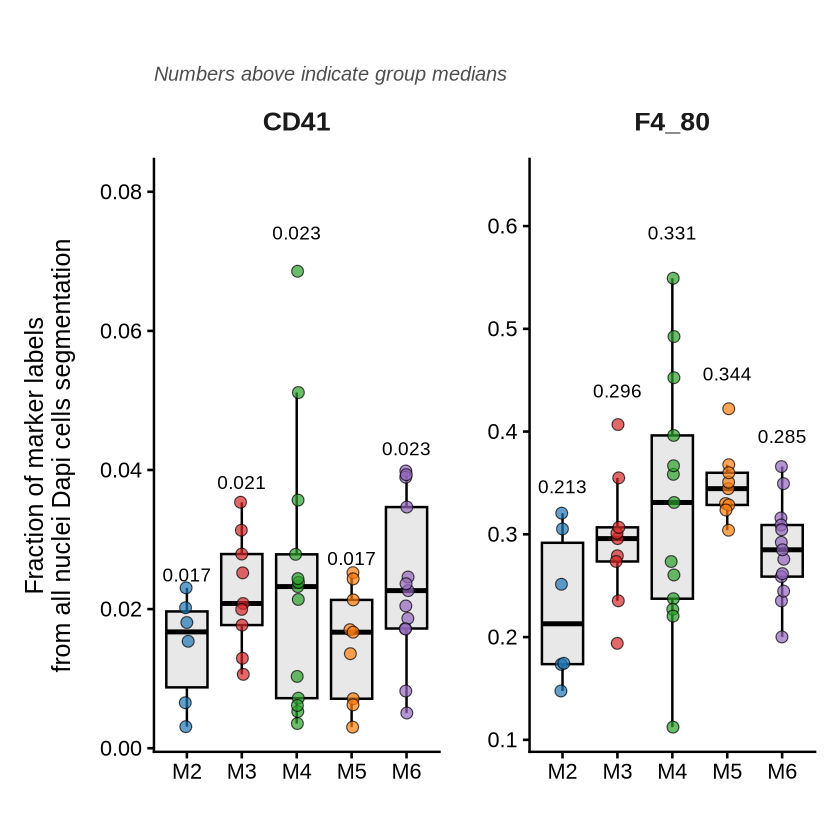

In [75]:
ggplot(plot_data, aes(x = batch_group, y = fraction, group = batch_group)) +
  # Boxes: Light grey background, thin lines for non-bold look
  geom_boxplot(fill = "gray70", alpha = 0.3, outlier.shape = NA, color = "black", linewidth = 0.7) +
  
  # Jitter points: Sized for visibility
  geom_point(
    aes(fill = batch_group),
    position = position_jitterdodge(jitter.width = 0.1, dodge.width = 0.1), 
    alpha = 0.7, 
    size = 3, 
    shape = 21, 
    color = "black", 
    stroke = 0.5
  ) + 
  
  # Add numeric Median values above the bars
  stat_summary(
    fun.data = function(x) {
      return(data.frame(
        y = max(x) + (max(x) * 0.08), # Position 8% above the highest point
        label = sprintf("%.3f", median(x))
      ))
    },
    geom = "text",
    family = "Arial",
    size = 4,
    color = "black"
  ) +
  
 # Added scale_y_continuous with expand to force ggplot to add 15% extra blank space at the top of every facet
  facet_wrap(~ phenotype, scales = "free_y") +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  scale_fill_manual(values = palette_colors) + 
  
  # Theme & Layout
  theme_classic(base_size = 16, base_family = "Arial") + 

  labs(title = "",
       subtitle = "Numbers above indicate group medians",
       x = "",
       y = "Fraction of marker labels\nfrom all nuclei Dapi cells segmentation") +

  theme(
    legend.position = "none",
    plot.subtitle = element_text(face = "italic", size = 12, color = "gray30", margin = margin(b = 15)),
    # Balanced axis title and text sizes
    axis.title.y = element_text(face = "plain", size = 15, margin = margin(r = 15)), # Added right margin to y-axis title
    axis.text = element_text(face = "plain", color = "black", size = 13),
    axis.line = element_line(linewidth = 0.7),
    # Adjusted facet headers
    strip.background = element_blank(),
    strip.text = element_text(face = "bold", size = 16, margin = margin(b = 15)),
    # Extra room to prevent labels from being cut off
    panel.spacing = unit(2, "lines"),
    plot.margin = margin(15, 15, 15, 15)
  )

# Save with Cairo for clean Arial rendering
# ggsave(file.path(image_analysis_results_figs, paste0(MAY12,"cell_labels_fraction_boxplot_clean_final.png")), 
#        width = 13, height = 8, device = png, type = "cairo")

ggsave(
  file.path(image_analysis_results_figs, paste0(JUN13, "_cell_labels_fraction_boxplot_clean_final.png")), 
  width = 13, 
  height = 8, 
  device = "png", 
  type = "cairo", 
  dpi = 300 
)

# Neighbors analysis - shuff
label - shuffle table

### logger

In [79]:

JUN13 <- date_str(2026, 6, 13)
logs_dir <-  file.path(home_path, "logs")
logs_dir <-  file.path(home_path, "logs")
if(!dir.exists(logs_dir)) { 
    dir.create(logs_dir, recursive = TRUE)
}
log_file <- file.path(logs_dir, paste0(JUN13, "_image_analysis_neighbors_amir_codes_log.txt"))
if (file.exists(log_file)) {
  file.remove(log_file)
}

log_appender(appender_tee(log_file, append = TRUE))
# Optional: Make the log layout look very clean
log_layout(layout_glue_generator('[{time}] [{level}] {msg}'))
log_info("Starting {JUN13} image neighbors analysis Amir's codes....")


### Load Data Markers Labels 

In [80]:
nuclei_full_data <- read.csv(updated_nuclei_full_data_path)
nuclei_full_data <- nuclei_full_data %>% dplyr::select(-X)
log_info("Combined nuclei data loaded successfully. Total rows: {nrow(nuclei_full_data)}")
nuclei_full_data %>% dim()

[1] 73121    32

In [81]:
nuclei_full_data %>% slice_sample(n=5)
nuclei_full_data %>% dim()

cell_id,image_batch,phenotype,batch,file_path,imagenumber,objectnumber,seriesfile,sizec,sizet,⋯,location_center_y,location_center_z,number_object_number,parent_identifyprimaryobjects,q95_CD41,q90_CD41,q95_F4_80,q90_F4_80,q95_il1b,q90_il1b
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,⋯,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
M6_Series005_946,M6_Series005,none,M6,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series005,42,946,Series005,1,1,⋯,1394.5563,0,946,946,0,0,18.79773,16.24170,88,66
M6_Series011_1044,M6_Series011,none,M6,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series011,48,1044,Series011,1,1,⋯,1545.0463,0,1044,1044,0,0,39.57840,14.01676,23,0
M2_Series002_1108,M2_Series002,F4_80,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series002,2,1108,Series002,1,1,⋯,1626.5047,0,1108,1108,0,0,106.91666,78.46024,21,0
M6_Series003_531,M6_Series003,none,M6,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series003,40,531,Series003,1,1,⋯,725.6634,0,531,531,0,0,26.15086,21.57980,145,95
M2_Series003_38,M2_Series003,none,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series003,3,38,Series003,1,1,⋯,320.6075,0,38,38,0,0,17.81707,12.47301,65,37


[1] 73121    32

### Variables

In [83]:
TARGET_SUB <-  TARGET_SERIES[1:5]
series_sub <- "M6_Series002"

### loop - itertation images

In [84]:
# START LOOP
heavy_objs <- c("tesselation", "tiles", "mat", "touching", "D", "touching_nb", 
                "cc_new", "cc_old", "IM", "shuf_mat", "target_vs_all",
                "q90_s", "shuf_nucs", "shuf_il1b_mat", "shuf_il1b_raw")

## Main loop  run and functions

In [85]:
# -------------------------------------------------------------------------
# 1. Spatial Network Builder
# Takes coordinate data and returns the adjacency matrix and areas.
# -------------------------------------------------------------------------
build_spatial_network <- function(nuclei_sub, max_dist) {
    x <- nuclei_sub$location_center_x
    y <- nuclei_sub$location_center_y
    
    tiles <- tile.list(deldir(x, y))
    names(tiles) <- paste0(names(tiles), ".")
    
    tiles_xy <- paste0(unlist(lapply(tiles, "[[", "x")), "@", unlist(lapply(tiles, "[[", "y")))
    tile2idx <- vecsplit(names(unlist(lapply(tiles, "[[", "x"))), "\\.", 2)
    
    mat <- tapply(rep(1, length(tile2idx)), list(as.numeric(tile2idx), as.numeric(factor(tiles_xy))), mean)
    mat[is.na(mat)] <- 0
    
    touching <- tcrossprod(mat) >= 1 
    xy_coords <- as.matrix(nuclei_sub[, c("location_center_x", "location_center_y")])
    
    touching_nb <- touching & (as.matrix(dist(xy_coords)) < max_dist)
    areas <- sapply(tiles, function(t) poly_area(t$x, t$y))
    
    return(list(touching_nb = touching_nb, areas = areas, tiles = tiles))
}

# -------------------------------------------------------------------------
# 2. Cluster Identifier
# Finds touching target cells and groups them into valid clusters.
# -------------------------------------------------------------------------
identify_clusters <- function(touching_nb, ct, target_type, min_good_targets) {
    target_idx <- which(ct == target_type)
    if (length(target_idx) < 2) return(NULL) # Not enough targets
    
    touching_target <- touching_nb[target_idx, target_idx]
    cc_new <- touching_target
    cc_old <- matrix(FALSE, nrow = dim(cc_new)[1], ncol = dim(cc_new)[2]) 
    
    i <- 1
    while((!all(cc_old == cc_new)) & (i < 100)) {
        cc_old <- cc_new
        cc_new <- crossprod(cc_old, touching_target) > 0 
        i <- i + 1
    }
    
    nuc2target <- as.numeric(factor(apply(as.matrix(cc_new), 1, function(x) paste0(seq_along(x)[x], collapse = ","))))
    names(nuc2target) <- target_idx
    
    good_targets <- names(which(table(nuc2target) > min_good_targets))
    if(length(good_targets) == 0) return(NULL)
    
    # Isolate touching matrix just for the good clusters
    target_vs_all <- touching_nb[target_idx, setdiff(seq_len(ncol(touching_nb)), target_idx)]
    target_touching <- apply(target_vs_all, 2, tapply, nuc2target[rownames(target_vs_all)], sum) > 0
    if (!is.matrix(target_touching)) {
        target_touching <- t(as.matrix(target_touching))
        rownames(target_touching) <- unique(nuc2target) 
    }
    target_touching <- target_touching[as.character(good_targets), , drop = FALSE]
    
    return(list(nuc2target = nuc2target, good_targets = good_targets, target_touching = target_touching))
}

# -------------------------------------------------------------------------
# 3. Fraction & Permutation Calculator
# Handles the real fractions and the shuffling loop.
# -------------------------------------------------------------------------
calculate_fractions_and_shuffles <- function(target_touching, ct, k,
                                              denom_labels, saved_labels,
                                              all_ct_levels) {
    ct_wo_mk <- ct[as.numeric(colnames(target_touching))]

    neighbor_types <- t(apply(
        target_touching, 1,
        function(x) table(factor(ct_wo_mk[x], levels = all_ct_levels))
    ))
    if (!is.matrix(neighbor_types)) return(NULL)

    total_valid <- rowSums(neighbor_types[, denom_labels, drop = FALSE], na.rm = TRUE)

    # FIX: raw division first — do NOT replace NA with 0 here
    raw_fractions <- neighbor_types[, saved_labels, drop = FALSE] / total_valid

    # FIX: valid_mask drops clusters where denominator == 0 (avoids unintended zeros)
    valid_mask <- is.finite(rowSums(raw_fractions)) & (total_valid > 0)
    if (!any(valid_mask)) return(NULL)

    real_fractions           <- raw_fractions[valid_mask, , drop = FALSE]
    colnames(real_fractions) <- paste0("real_frac_", saved_labels)
    target_touching_f        <- target_touching[valid_mask, , drop = FALSE]  # FIX: filter before shuffles

    shuf_mats        <- lapply(saved_labels, function(x) matrix(NA, nrow = sum(valid_mask), ncol = k))
    names(shuf_mats) <- saved_labels

    for (sim_idx in seq_len(k)) {
        shuffled_touching <- target_touching_f[, sample(ncol(target_touching_f)), drop = FALSE]
        neighbor_shuf     <- t(apply(
            shuffled_touching, 1,
            function(x) table(factor(ct_wo_mk[x], levels = all_ct_levels))
        ))

        shuf_total_valid                        <- rowSums(neighbor_shuf[, denom_labels, drop = FALSE], na.rm = TRUE)
        shuf_total_valid[shuf_total_valid == 0] <- 1

        for (label in saved_labels) {
            calc_frac                      <- neighbor_shuf[, label] / shuf_total_valid
            calc_frac[is.na(calc_frac)]    <- 0  # safety net only — denom guard above makes this rare
            shuf_mats[[label]][, sim_idx]  <- calc_frac
        }
    }

    for (label in saved_labels) {
        colnames(shuf_mats[[label]]) <- paste0("shuf_", seq_len(k), "_", label)
    }

    # FIX: return valid_mask so the loop can align good_targets, IL-1b, areas
    return(list(real = as.data.frame(real_fractions), shuf = shuf_mats, valid_mask = valid_mask))
}


compute_il1b_stats <- function(q90_il1b, nuc2target, good_targets, k) {
    if (is.null(q90_il1b) || length(good_targets) == 0) return(NULL)

    target_indices <- as.numeric(names(nuc2target))

    # Real observed mean IL-1b per cluster (FIX: was missing entirely)
    real_mean_il1b <- tapply(q90_il1b[target_indices], nuc2target, mean, na.rm = TRUE)[as.character(good_targets)]

    # Shuffle: permute the full nuclei_s population, fix spatial positions
    shuf_indices_mat <- sapply(seq_len(k), function(x) sample(seq_len(length(q90_il1b))))
    q90_s            <- matrix(q90_il1b[shuf_indices_mat], nrow = length(q90_il1b))

    shuf_il1b_raw <- apply(q90_s[target_indices, , drop = FALSE], 2, function(col) {
        tapply(col, nuc2target, mean, na.rm = TRUE)
    })

    if (!is.matrix(shuf_il1b_raw)) {
        shuf_il1b_mat           <- t(as.matrix(shuf_il1b_raw))
        rownames(shuf_il1b_mat) <- names(tapply(q90_il1b[target_indices], nuc2target, mean))
    } else {
        shuf_il1b_mat <- shuf_il1b_raw
    }

    shuf_il1b_mat           <- shuf_il1b_mat[as.character(good_targets), , drop = FALSE]
    colnames(shuf_il1b_mat) <- paste0("shuf_", seq_len(k), "_Il1b")

    return(list(real_mean = as.numeric(real_mean_il1b), shuf_mat = as.data.frame(shuf_il1b_mat)))
}

In [86]:
nuclei_full_data %>% pull(image_batch) %>% unique()

[1] "M2_Series001" "M2_Series002" "M2_Series003" "M2_Series004" "M2_Series005"
 [6] "M2_Series006" "M3_Series001" "M3_Series002" "M3_Series004" "M3_Series005"
[11] "M3_Series006" "M3_Series007" "M3_Series008" "M3_Series009" "M3_Series010"
[16] "M4_Series001" "M4_Series002" "M4_Series003" "M4_Series004" "M4_Series005"
[21] "M4_Series006" "M4_Series007" "M4_Series009" "M4_Series010" "M4_Series011"
[26] "M4_Series012" "M4_Series014" "M4_Series015" "M5_Series001" "M5_Series002"
[31] "M5_Series003" "M5_Series004" "M5_Series005" "M5_Series006" "M5_Series007"
[36] "M5_Series008" "M5_Series009" "M6_Series001" "M6_Series002" "M6_Series003"
[41] "M6_Series004" "M6_Series005" "M6_Series006" "M6_Series007" "M6_Series008"
[46] "M6_Series009" "M6_Series010" "M6_Series011" "M6_Series012" "M6_Series013"

In [87]:
# 1. SETUP GLOBAL VARIABLES
k <- CONFIG$K_PERM
neighbor_type <- CONFIG$NEIGHBOR_TYPE
target_type <- CONFIG$TARGET_TYPE
MAX_DIST <- CONFIG$MAX_DIST

denominator_labels   <- c("F4_80", "none")
saved_labels         <- c("F4_80")
RUN_IL1B_SHUFFLE     <- TRUE
all_clusters_list <- list()
max_size_idx <- CONFIG$MAX_SIZE_IDX
min_good_targets <- CONFIG$MIN_NUM_CLUST

all_ct_levels <- nuclei_full_data %>% pull(phenotype) %>% unique() %>% unlist() %>% as.character()
all_ct_levels 

min_good_target <- CONFIG$MIN_NUM_CLUST
max_size_idx  <- CONFIG$MAX_SIZE_IDX
print(paste("Neighbor Type:", neighbor_type),)
print(paste("Target Type:", target_type))
print(paste("MAX_DIST:", MAX_DIST))
print(paste("max_size_idx:", max_size_idx))
print(paste("min_good_target:", min_good_target))

log_info("defined global variables for neighbor analysis: k={k}, neighbor_type={neighbor_type}, target_type={target_type}, MAX_DIST={MAX_DIST}, max_size_idx={max_size_idx}")
all_clusters_list  <-  list()
log_info("Initialized empty list to store cluster results")
TARGET_SERIES  <-  nuclei_full_data %>% pull(image_batch) %>% unique()
log_info("Extracted unique image batches for analysis. Total batches: {length(TARGET_SERIES)}")
log_info("neighbor analysis will be performed on the following batches: {paste(TARGET_SERIES, collapse=', ')}")

[1] "none"  "F4_80" "CD41"

[1] "Neighbor Type: F4_80"
[1] "Target Type: CD41"
[1] "MAX_DIST: 100"
[1] "max_size_idx: 4000"
[1] "min_good_target: 2"


In [88]:
ct_list  <-  nuclei_full_data %>% pull(phenotype) %>% table() %>% as.list()
all_ct_levels <- nuclei_full_data %>% pull(phenotype) %>% unique() %>% unlist() %>% as.character()
all_ct_levels 

[1] "none"  "F4_80" "CD41"

In [89]:


for (series in TARGET_SERIES) {
    message(paste0("Image start processing: ", series))
    log_info("Processing image: {series}.")

    tryCatch({
        # 1. Subset
        nuclei_sub <- nuclei_full_data %>% filter(image_batch == series)

        # 2. Spatial network
        network <- build_spatial_network(nuclei_sub, MAX_DIST)
        # 3. Filter by cell area
        small_idx       <- which(network$areas < max_size_idx)
        nuclei_s        <- nuclei_sub[small_idx, ]
        touching_nb_sub <- network$touching_nb[small_idx, small_idx]
        dimnames(touching_nb_sub) <- list(seq_along(small_idx), seq_along(small_idx))
        ct <- nuclei_s %>% pull(phenotype)
        log_info("Cell types found: {paste(unique(ct), collapse=', ')}.")

        # 4. Identify clusters
        clusters <- identify_clusters(touching_nb_sub, ct, target_type, min_good_targets)
        if (is.null(clusters)) {
            log_warn("Image {series}: No valid clusters found. Skipping.")
            rm(list = intersect(heavy_objs, ls())); gc(verbose = FALSE); next
        }
        message("Image has ", length(clusters$good_targets), " megakaryocytes!")

        # 5. Fractions & shuffles (valid_mask applied inside)
        log_info("Starting neighbor calculations and {k} shuffles for {series}...")
        stats <- calculate_fractions_and_shuffles(
            clusters$target_touching, ct, k,
            denominator_labels, saved_labels, all_ct_levels
        )
        if (is.null(stats)) {
            log_warn("Image {series}: No valid clusters after fraction filtering. Skipping.")
            rm(list = intersect(heavy_objs, ls())); gc(verbose = FALSE); next
        }

        # FIX: align good_targets to valid_mask returned from stats
        good_mks_final <- clusters$good_targets[stats$valid_mask]
        log_info("Image {series}: {length(good_mks_final)} clusters pass all filters.")

        # 6. IL-1b (real mean + shuffles)
        il1b_stats <- NULL
        if (RUN_IL1B_SHUFFLE) {
            log_info("Calculating IL-1b intensities for {series}...")
            il1b_stats <- compute_il1b_stats(
                nuclei_s$q90_il1b,        # FIX: lowercase — match your actual column name
                clusters$nuc2target,       # full map; function subsets to good_mks_final internally
                good_mks_final,
                k
            )
        }

        # 7. Cluster metadata
        mapped_cells  <- split(names(clusters$nuc2target), clusters$nuc2target)
        nuc_indices   <- as.numeric(names(clusters$nuc2target))
        cluster_areas <- tapply(
            network$areas[small_idx[nuc_indices]], clusters$nuc2target, sum, na.rm = TRUE
        )[as.character(good_mks_final)]

        orig_indices <- sapply(as.character(good_mks_final), function(cid) {
            paste(mapped_cells[[cid]], collapse = ",")
        })
        abs_cell_ids <- sapply(as.character(good_mks_final), function(cid) {
            paste(nuclei_s$cell_id[as.numeric(mapped_cells[[cid]])], collapse = ",")
        })

        # 8. Assemble img_df
        img_df <- data.frame(
            image_batch   = series,
            cluster_id    = seq_along(good_mks_final),  # re-sequenced: 1..N per image
            cluster_cells = orig_indices,
            cluster_area  = as.numeric(cluster_areas),
            stringsAsFactors = FALSE
        )

        if (!is.null(il1b_stats)) {
            img_df$real_mean_Il1b <- il1b_stats$real_mean  # FIX: real mean restored
        }

        img_df <- cbind(img_df, as.data.frame(stats$real))

        for (label in saved_labels) {
            img_df <- cbind(img_df, as.data.frame(stats$shuf[[label]]))
        }

        if (!is.null(il1b_stats)) {
            img_df <- cbind(img_df, il1b_stats$shuf_mat)
        }

        log_info("Saving {nrow(img_df)} clusters for image: {series}.")
        all_clusters_list[[series]] <- img_df
        rm(list = intersect(heavy_objs, ls())); gc(verbose = FALSE)
        log_info("Memory cleaned for {series}. Moving to next image.")

    }, error = function(e) {
        message("CRITICAL ERROR in ", series, ": ", e$message)
        log_error("CRITICAL ERROR in {series}: {e$message}")
        return(NULL)
    })
}

Image start processing: M2_Series001

Image has 1 megakaryocytes!

Image start processing: M2_Series002

Image has 4 megakaryocytes!

Image start processing: M2_Series003

Image has 3 megakaryocytes!

Image start processing: M2_Series004

Image has 1 megakaryocytes!

Image start processing: M2_Series005

Image has 4 megakaryocytes!

Image start processing: M2_Series006

Image has 4 megakaryocytes!

Image start processing: M3_Series001

Image has 6 megakaryocytes!

Image start processing: M3_Series002

Image has 4 megakaryocytes!

Image start processing: M3_Series004

Image has 9 megakaryocytes!

Image start processing: M3_Series005

Image has 3 megakaryocytes!

Image start processing: M3_Series006

Image has 2 megakaryocytes!

Image start processing: M3_Series007

Image has 1 megakaryocytes!

Image start processing: M3_Series008

Image has 7 megakaryocytes!

Image start processing: M3_Series009

Image has 5 megakaryocytes!

Image start processing: M3_Series010

Image has 3 megakaryocyt

### Combine Results

In [90]:
master_cluster_df_new <- dplyr::bind_rows(all_clusters_list) %>% 
                        mutate(batch=str_extract(image_batch, "M\\d+")) %>% 
                        dplyr::select(-any_of(c("cluster_cells_relative", "cluster_cells_absolute"))) %>%
                        relocate(batch,cluster_cells,.before = cluster_id)
master_cluster_df_new %>% head()

,image_batch,batch,cluster_cells,cluster_id,cluster_area,real_mean_Il1b,real_frac_F4_80,shuf_1_F4_80,shuf_2_F4_80,shuf_3_F4_80,⋯,shuf_4991_Il1b,shuf_4992_Il1b,shuf_4993_Il1b,shuf_4994_Il1b,shuf_4995_Il1b,shuf_4996_Il1b,shuf_4997_Il1b,shuf_4998_Il1b,shuf_4999_Il1b,shuf_5000_Il1b
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1...1,M2_Series001,M2,"318,327,329,347,393,395,406",1,19410.968,78.42857,0.1111111,0.22222222,0.1666667,0.16666667,⋯,31.71429,20.71429,2.857143,11.57143,20.71429,32.28571,2.857143,53.71429,82.28571,8.571429
1...2,M2_Series002,M2,"202,209,217,219,265,271,307",1,13577.251,134.17143,0.2500000,0.16666667,0.4166667,0.16666667,⋯,66.42857,51.28571,39.142857,22.71429,89.28571,53.00000,121.428571,31.57143,57.14286,81.571429
2...3,M2_Series002,M2,"515,517,525,538,542,579,593,596,621",2,18245.916,152.66667,0.0000000,0.07142857,0.2142857,0.14285714,⋯,119.00000,92.77778,85.777778,85.44444,25.77778,51.88889,61.111111,47.88889,68.22222,92.600000
3...4,M2_Series002,M2,"1200,1215,1223",3,4944.279,52.66667,0.8000000,0.20000000,0.4000000,0.20000000,⋯,52.66667,24.66667,17.666667,17.66667,17.66667,35.33333,155.333333,35.33333,52.66667,63.333333
4...5,M2_Series002,M2,"328,335,367,370,386,398,400",4,18000.690,84.42857,0.5384615,0.07692308,0.3076923,0.15384615,⋯,24.14286,140.71429,63.428571,51.28571,16.57143,59.00000,51.428571,59.00000,160.28571,57.571429
1...6,M2_Series003,M2,"192,194,195,204,250,259",1,12867.425,138.83333,0.2727273,0.18181818,0.2727273,0.09090909,⋯,58.66667,75.23333,54.000000,57.00000,49.50000,68.33333,90.500000,45.00000,49.16667,51.166667


In [91]:
master_cluster_df_new %>% dim()

[1]   168 10007

### Save Results

In [93]:
JUN13 <- date_str(2026, 6, 13)
JUN06 <- date_str(2026, 6, 6)
master_cluster_df_new_f <- file.path(image_analysis_results_data, paste0(JUN13 ,"_E16_first5_images_neighbor_analysis_and_Il1b_mean_shuf_functions.csv"))
write.csv(master_cluster_df_new, master_cluster_df_new_f, row.names = FALSE)

In [94]:

master_cluster_df_new %>% pull(batch) %>% table()

.
M2 M3 M4 M5 M6 
17 40 48 22 41 

In [95]:

master_cluster_df_new %>% pull(batch) %>% unique()

[1] "M2" "M3" "M4" "M5" "M6"

In [96]:
# ==========================================
# CREATE NEW BATCH COLUMN FOR PUBLICATION
# ==========================================
batch_mapping <- c(
  "M2" = "M1",
  "M3" = "M2",
  "M4" = "M3",
  "M5" = "M4",
  "M6" = "M5"
)

if("batch" %in% names(master_cluster_df_new)) {
  #  Creates 'batch_pub' as a new column, leaving 'batch' intact
  master_cluster_df_new$batch_pub <- ifelse(
    master_cluster_df_new$batch %in% names(batch_mapping),
    batch_mapping[master_cluster_df_new$batch],
    master_cluster_df_new$batch
  )
}
master_cluster_df_new <-  master_cluster_df_new %>% relocate(batch_pub, .after = batch)

In [97]:
master_cluster_df_new %>%  slice_sample(n=5) 

,image_batch,batch,batch_pub,cluster_cells,cluster_id,cluster_area,real_mean_Il1b,real_frac_F4_80,shuf_1_F4_80,shuf_2_F4_80,⋯,shuf_4991_Il1b,shuf_4992_Il1b,shuf_4993_Il1b,shuf_4994_Il1b,shuf_4995_Il1b,shuf_4996_Il1b,shuf_4997_Il1b,shuf_4998_Il1b,shuf_4999_Il1b,shuf_5000_Il1b
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2...1,M4_Series014,M4,M3,"904,936,937,943,946,958,966,968,995",1,16188.581,52.75556,0.4166667,0.3333333,0.1666667,⋯,54.06667,56.00000,67.88889,55.88889,46.33333,68.00,55.77778,33.11111,87.88889,59.86667
3...2,M3_Series008,M3,M2,"538,582,587,624",3,8246.839,206.75000,0.3571429,0.2857143,0.2142857,⋯,83.25000,82.75000,52.25000,68.00000,91.00000,191.25,36.00000,82.75000,52.75000,69.75000
1,M2_Series002,M2,M1,"202,209,217,219,265,271,307",1,13577.251,134.17143,0.2500000,0.1666667,0.4166667,⋯,66.42857,51.28571,39.14286,22.71429,89.28571,53.00,121.42857,31.57143,57.14286,81.57143
3...4,M4_Series002,M4,M3,"205,217,250,254,256,280",2,12187.516,118.33333,0.6000000,0.4000000,0.4000000,⋯,123.83333,136.23333,131.83333,132.00000,157.83333,114.00,148.33333,118.50000,95.83333,115.33333
2...5,M2_Series006,M2,M1,"548,561,590,602,633,644,648,658",2,17559.864,114.75000,0.4285714,0.4285714,0.2857143,⋯,59.75000,75.00000,90.40000,90.62500,91.37500,69.50,73.37500,84.75000,97.75000,66.50000


In [98]:
write.csv(master_cluster_df_new, master_cluster_df_new_f, row.names = FALSE)

In [99]:
nuclei_full_data %>%  head()

,cell_id,image_batch,phenotype,batch,file_path,imagenumber,objectnumber,seriesfile,sizec,sizet,⋯,location_center_y,location_center_z,number_object_number,parent_identifyprimaryobjects,q95_CD41,q90_CD41,q95_F4_80,q90_F4_80,q95_il1b,q90_il1b
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,⋯,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,M2_Series001_1,M2_Series001,none,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,1,Series001,1,1,⋯,16.60484,0,1,1,0,0,67.95433,9.627717,0,0
2,M2_Series001_2,M2_Series001,none,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,2,Series001,1,1,⋯,21.67953,0,2,2,0,0,16.48925,9.911982,0,0
3,M2_Series001_3,M2_Series001,none,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,3,Series001,1,1,⋯,21.16717,0,3,3,0,0,8.56238,4.366248,248,122
4,M2_Series001_4,M2_Series001,none,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,4,Series001,1,1,⋯,32.04751,0,4,4,0,0,18.22116,12.481609,20,0
5,M2_Series001_5,M2_Series001,none,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,5,Series001,1,1,⋯,25.72343,0,5,5,0,0,30.90772,21.374689,0,0
6,M2_Series001_6,M2_Series001,none,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series001,1,6,Series001,1,1,⋯,42.53730,0,6,6,0,0,6.86593,4.347100,0,0


# Load Neighbors Analysis Results

In [100]:
# master_neighbors_csv  <-  file.path(image_analysis_results_data, paste0(APR20, "_all_clusters_neighbor_analysis_and_Il1b_mean_shuf.csv"))
master_cluster_df_new_f <- file.path(image_analysis_results_data,paste0(JUN13, "_E16_first5_images_neighbor_analysis_and_Il1b_mean_shuf_functions.csv"))
neighbors_df_5_first_images <- read.csv(master_cluster_df_new_f)   %>%  
        # dplyr::rename(real_frac_F4_80 = real_fraction) %>% 
        dplyr::select(-ends_with("Il1b"))
neighbors_df_5_first_images  %>% dim()

[1]  168 5007

In [101]:
neighbors_df_5_first_images %>% head()

,image_batch,batch,batch_pub,cluster_cells,cluster_id,cluster_area,real_frac_F4_80,shuf_1_F4_80,shuf_2_F4_80,shuf_3_F4_80,⋯,shuf_4991_F4_80,shuf_4992_F4_80,shuf_4993_F4_80,shuf_4994_F4_80,shuf_4995_F4_80,shuf_4996_F4_80,shuf_4997_F4_80,shuf_4998_F4_80,shuf_4999_F4_80,shuf_5000_F4_80
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,M2_Series001,M2,M1,"318,327,329,347,393,395,406",1,19410.968,0.1111111,0.22222222,0.1666667,0.16666667,⋯,0.1666667,0.11111111,0.11111111,0.11111111,0.2222222,0.27777778,0.05555556,0.27777778,0.11111111,0.16666667
2,M2_Series002,M2,M1,"202,209,217,219,265,271,307",1,13577.251,0.2500000,0.16666667,0.4166667,0.16666667,⋯,0.4166667,0.25000000,0.08333333,0.16666667,0.1666667,0.08333333,0.25000000,0.16666667,0.00000000,0.08333333
3,M2_Series002,M2,M1,"515,517,525,538,542,579,593,596,621",2,18245.916,0.0000000,0.07142857,0.2142857,0.14285714,⋯,0.2142857,0.21428571,0.14285714,0.14285714,0.2857143,0.14285714,0.14285714,0.28571429,0.07142857,0.28571429
4,M2_Series002,M2,M1,"1200,1215,1223",3,4944.279,0.8000000,0.20000000,0.4000000,0.20000000,⋯,0.0000000,0.40000000,0.00000000,0.60000000,0.2000000,0.20000000,0.20000000,0.00000000,0.40000000,0.00000000
5,M2_Series002,M2,M1,"328,335,367,370,386,398,400",4,18000.690,0.5384615,0.07692308,0.3076923,0.15384615,⋯,0.2307692,0.07692308,0.23076923,0.07692308,0.2307692,0.15384615,0.23076923,0.15384615,0.23076923,0.38461538
6,M2_Series003,M2,M1,"192,194,195,204,250,259",1,12867.425,0.2727273,0.18181818,0.2727273,0.09090909,⋯,0.0000000,0.09090909,0.27272727,0.18181818,0.5454545,0.18181818,0.27272727,0.09090909,0.27272727,0.00000000


In [102]:
all_clusters_list[1]

,image_batch,cluster_id,cluster_cells,cluster_area,real_mean_Il1b,real_frac_F4_80,shuf_1_F4_80,shuf_2_F4_80,shuf_3_F4_80,shuf_4_F4_80,⋯,shuf_4991_Il1b,shuf_4992_Il1b,shuf_4993_Il1b,shuf_4994_Il1b,shuf_4995_Il1b,shuf_4996_Il1b,shuf_4997_Il1b,shuf_4998_Il1b,shuf_4999_Il1b,shuf_5000_Il1b
,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,M2_Series001,1,"318,327,329,347,393,395,406",19410.97,78.42857,0.1111111,0.2222222,0.1666667,0.1666667,0.05555556,⋯,31.71429,20.71429,2.857143,11.57143,20.71429,32.28571,2.857143,53.71429,82.28571,8.571429


In [103]:
neighbors_df_5_first_images %>%   dplyr::summarise(across(everything(), ~ sum(is.na(.))))

image_batch,batch,batch_pub,cluster_cells,cluster_id,cluster_area,real_frac_F4_80,shuf_1_F4_80,shuf_2_F4_80,shuf_3_F4_80,⋯,shuf_4991_F4_80,shuf_4992_F4_80,shuf_4993_F4_80,shuf_4994_F4_80,shuf_4995_F4_80,shuf_4996_F4_80,shuf_4997_F4_80,shuf_4998_F4_80,shuf_4999_F4_80,shuf_5000_F4_80
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [104]:
# Isolate the specific row with the NA and select its core metadata columns
culprit_row <- neighbors_df_5_first_images %>%
  dplyr::filter(is.na(real_frac_F4_80)) 

print(culprit_row)

   [1] image_batch     batch           batch_pub       cluster_cells  
   [5] cluster_id      cluster_area    real_frac_F4_80 shuf_1_F4_80   
   [9] shuf_2_F4_80    shuf_3_F4_80    shuf_4_F4_80    shuf_5_F4_80   
  [13] shuf_6_F4_80    shuf_7_F4_80    shuf_8_F4_80    shuf_9_F4_80   
  [17] shuf_10_F4_80   shuf_11_F4_80   shuf_12_F4_80   shuf_13_F4_80  
  [21] shuf_14_F4_80   shuf_15_F4_80   shuf_16_F4_80   shuf_17_F4_80  
  [25] shuf_18_F4_80   shuf_19_F4_80   shuf_20_F4_80   shuf_21_F4_80  
  [29] shuf_22_F4_80   shuf_23_F4_80   shuf_24_F4_80   shuf_25_F4_80  
  [33] shuf_26_F4_80   shuf_27_F4_80   shuf_28_F4_80   shuf_29_F4_80  
  [37] shuf_30_F4_80   shuf_31_F4_80   shuf_32_F4_80   shuf_33_F4_80  
  [41] shuf_34_F4_80   shuf_35_F4_80   shuf_36_F4_80   shuf_37_F4_80  
  [45] shuf_38_F4_80   shuf_39_F4_80   shuf_40_F4_80   shuf_41_F4_80  
  [49] shuf_42_F4_80   shuf_43_F4_80   shuf_44_F4_80   shuf_45_F4_80  
  [53] shuf_46_F4_80   shuf_47_F4_80   shuf_48_F4_80   shuf_49_F4_80  
  [57]

In [105]:
neighbors_df_5_first_images %>% dplyr::filter(image_batch =="M6_Series002")

image_batch,batch,batch_pub,cluster_cells,cluster_id,cluster_area,real_frac_F4_80,shuf_1_F4_80,shuf_2_F4_80,shuf_3_F4_80,⋯,shuf_4991_F4_80,shuf_4992_F4_80,shuf_4993_F4_80,shuf_4994_F4_80,shuf_4995_F4_80,shuf_4996_F4_80,shuf_4997_F4_80,shuf_4998_F4_80,shuf_4999_F4_80,shuf_5000_F4_80
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
M6_Series002,M6,M5,"158,174,186,190,207",1,11717.31,0.3636364,0.4545455,0.3636364,0.09090909,⋯,0.4545455,0.5454545,0.2727273,0.6363636,0.4545455,0.7272727,0.4545455,0.3636364,0.4545455,0.2727273
M6_Series002,M6,M5,"427,439,451,456,472,475,484",2,19098.32,0.7500000,0.2500000,0.8750000,0.37500000,⋯,0.1250000,0.6250000,0.1250000,0.3750000,0.6250000,0.5000000,0.3750000,0.5000000,0.6250000,0.2500000
M6_Series002,M6,M5,"434,441,442,447,457,461,481,482,488",3,16313.49,0.6000000,0.5333333,0.7333333,0.40000000,⋯,0.3333333,0.4666667,0.2000000,0.6000000,0.5333333,0.4666667,0.5333333,0.4000000,0.4666667,0.5333333
M6_Series002,M6,M5,"342,350,369,380,394,399,402",4,16031.27,0.4166667,0.4166667,0.7500000,0.41666667,⋯,0.2500000,0.3333333,0.5000000,0.4166667,0.4166667,0.3333333,0.3333333,0.5000000,0.3333333,0.4166667


# Shuffle Validation - The Two Failure Modes

## Background

`global_f4_80_prop` is the proportion of F4/80 cells out of all non-target cells in the entire tissue image - every cell, whether it is near a megakaryocyte or far away. It is the baseline you would expect if neighbors were drawn completely at random from the whole tissue.

---

## Failure Mode 1: `mean_expected ≈ mean_observed` - Shuffle is Frozen (No Randomisation)

This would mean the shuffled fractions are always the same as the real fractions. It would happen if the column permutation had no effect - for example if every cluster touched every non-target cell (fully connected graph), so shuffling columns changes nothing. In that case the shuffle is useless as a null model.

---

## Failure Mode 2: `mean_expected ≈ global_f4_80_prop` - Sampling from the Wrong Pool

This would mean the shuffle is drawing neighbors from the whole tissue randomly, ignoring spatial structure entirely. That would be the wrong null because it throws away all local spatial information. The shuffle should permute only within the actual neighbor pool (cells already physically close to megakaryocytes), so `mean_expected` should land **above** `global_f4_80_prop` - reflecting the local tissue composition around megakaryocytes, not the whole slide average.

---

## What a Correct Result Looks Like

```
global_f4_80_prop  <  mean_expected  <  mean_observed
   wrong pool null      correct null      real data
     (too low)          (local zone)    (specific signal)
```

`mean_expected` sitting between the two extremes - above the whole-tissue rate but below the real observed value - is exactly what a correctly implemented spatial shuffle should produce.


# merging shuff Experiments images
## merging shuff res

In [106]:
neighbors_df_5_first_images %>% pull(batch_pub) %>%  unique()

[1] "M1" "M2" "M3" "M4" "M5"

In [107]:
neighbors_df_3_new_images_path  <- file.path(home_path,"E16_S100A8_CD41_F4_80", "image_analysis_results", "data", "2026_06_14_E16_neut_and_mac_images_neighbor_analysis_shuf_functions.csv")
neighbors_df_3_new_images <- read.csv(neighbors_df_3_new_images_path) %>% dplyr::select( -ends_with("S100A8"),-starts_with("old"))
neighbors_df_3_new_images  %>% dim()

[1]  117 5006

In [108]:
batch_mapping_new_samples <- c(
  "M1" = "M1",
  "M2" = "M2",
  "M5" = "M3"

)

if("batch" %in% names(neighbors_df_3_new_images)) {
  # 🚨 Creates 'batch_pub' as a new column, leaving 'batch' intact
  neighbors_df_3_new_images$batch_pub <- ifelse(
    neighbors_df_3_new_images$batch %in% names(batch_mapping_new_samples),
    batch_mapping_new_samples[neighbors_df_3_new_images$batch],
    neighbors_df_3_new_images$batch
  )
}

In [109]:
neighbors_df_3_new_images %>%  pull(batch_pub) %>% unique()

[1] "M1" "M2" "M3"

In [110]:
combined_master_df <- bind_rows(
    "IL1b"   = neighbors_df_5_first_images,
    "S100A8" = neighbors_df_3_new_images,
    .id = "experiment"
) %>%  mutate(exp_batch = paste(experiment, batch, sep = "_"),
              exp_batch_pub = paste(experiment, batch_pub, sep = "_"),
              image_batch = paste(experiment, image_batch, sep = "_")) %>% 
    relocate(exp_batch,exp_batch_pub ,.before = image_batch)
combined_master_df %>% slice_sample(n = 10)

experiment,exp_batch,exp_batch_pub,image_batch,batch,batch_pub,cluster_cells,cluster_id,cluster_area,real_frac_F4_80,⋯,shuf_4991_F4_80,shuf_4992_F4_80,shuf_4993_F4_80,shuf_4994_F4_80,shuf_4995_F4_80,shuf_4996_F4_80,shuf_4997_F4_80,shuf_4998_F4_80,shuf_4999_F4_80,shuf_5000_F4_80
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
IL1b,IL1b_M4,IL1b_M3,IL1b_M4_Series002,M4,M3,"326,359,369,381,383,390,399,406,416,417,422,427,432,442,479",4,33747.763,0.8571429,⋯,0.4761905,0.61904762,0.5714286,0.5714286,0.6666667,0.6666667,0.3809524,0.6666667,0.5714286,0.6190476
S100A8,S100A8_M5,S100A8_M3,S100A8_M5_Series010,M5,M3,"255,277,278,285,301,314,327,331,347",1,13700.899,0.3750000,⋯,0.1875000,0.06250000,0.2500000,0.1250000,0.1875000,0.3125000,0.1250000,0.1875000,0.1250000,0.1875000
IL1b,IL1b_M6,IL1b_M5,IL1b_M6_Series003,M6,M5,"388,395,401,412,425,427,436,445,472",1,22718.596,0.2500000,⋯,0.3750000,0.37500000,0.3125000,0.3125000,0.3750000,0.1875000,0.3125000,0.1250000,0.5000000,0.3750000
S100A8,S100A8_M2,S100A8_M2,S100A8_M2_Series004,M2,M2,"440,456,461,462,473",4,14629.192,0.2500000,⋯,0.1250000,0.37500000,0.1250000,0.7500000,0.3750000,0.2500000,0.6250000,0.3750000,0.1250000,0.1250000
IL1b,IL1b_M6,IL1b_M5,IL1b_M6_Series009,M6,M5,"1005,1016,1017,1025,1029",1,9086.414,0.4000000,⋯,0.3000000,0.20000000,0.3000000,0.3000000,0.3000000,0.2000000,0.2000000,0.3000000,0.1000000,0.4000000
IL1b,IL1b_M4,IL1b_M3,IL1b_M4_Series010,M4,M3,"1086,1125,1130,1150,1157",1,10801.723,0.0000000,⋯,0.1428571,0.14285714,0.1428571,0.0000000,0.0000000,0.1428571,0.1428571,0.1428571,0.0000000,0.0000000
IL1b,IL1b_M6,IL1b_M5,IL1b_M6_Series002,M6,M5,"158,174,186,190,207",1,11717.315,0.3636364,⋯,0.4545455,0.54545455,0.2727273,0.6363636,0.4545455,0.7272727,0.4545455,0.3636364,0.4545455,0.2727273
S100A8,S100A8_M2,S100A8_M2,S100A8_M2_Series007,M2,M2,"573,575,586",4,7018.528,0.4166667,⋯,0.3333333,0.08333333,0.3333333,0.3333333,0.3333333,0.3333333,0.2500000,0.5000000,0.2500000,0.2500000
IL1b,IL1b_M5,IL1b_M4,IL1b_M5_Series006,M5,M4,"853,854,874,877,889,897,911,925,955,961,964",3,23508.857,0.3076923,⋯,0.3076923,0.46153846,0.3076923,0.3846154,0.2307692,0.4615385,0.5384615,0.3076923,0.3076923,0.3846154


In [111]:
JUN14 <- date_str(2026, 6, 14)
write.csv(combined_master_df, file.path(image_analysis_results_data, paste0(JUN14, "_combined_experiment_S100A8_and_IL1b_F4_80_marker_neighbor_analysis_shuf_functions.csv")), row.names = FALSE)

## merging nuclei labels data

In [112]:
nuclei_full_data_il1b <-  read.csv(updated_nuclei_full_data_path) %>%  
dplyr::select(-X,-starts_with("q"),-starts_with("filename"),-starts_with("pathname"))


In [113]:
# ==========================================
# CREATE NEW BATCH COLUMN FOR PUBLICATION
# ==========================================
batch_mapping <- c(
  "M2" = "M1",
  "M3" = "M2",
  "M4" = "M3",
  "M5" = "M4",
  "M6" = "M5"
)

if("batch" %in% names(nuclei_full_data_il1b)) {
  # 🚨 Creates 'batch_pub' as a new column, leaving 'batch' intact
  nuclei_full_data_il1b$batch_pub <- ifelse(
    nuclei_full_data_il1b$batch %in% names(batch_mapping),
    batch_mapping[nuclei_full_data_il1b$batch],
    nuclei_full_data_il1b$batch
  )
}
nuclei_full_data_il1b <-  nuclei_full_data_il1b %>% relocate(batch_pub, .after = batch)
nuclei_full_data_il1b %>%  slice_sample(n=5)

cell_id,image_batch,phenotype,batch,batch_pub,file_path,imagenumber,objectnumber,seriesfile,sizec,sizet,sizez,location_center_x,location_center_y,location_center_z,number_object_number,parent_identifyprimaryobjects
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>
M3_Series004_1779,M3_Series004,none,M3,M2,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M3_2048_resolution/M3_Il1B_Series004,9,1779,Series004,1,1,1,1949.8558,1732.45131,0,1779,1779
M6_Series008_1100,M6_Series008,none,M6,M5,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series008,45,1100,Series008,1,1,1,1675.1189,1482.32703,0,1100,1100
M6_Series013_13,M6_Series013,none,M6,M5,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M6_2048_resolution/E16_M1_Series013,50,13,Series013,1,1,1,1494.9867,46.12551,0,13,13
M2_Series004_263,M2_Series004,none,M2,M1,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series004,4,263,Series004,1,1,1,1547.0366,339.19616,0,263,263
M2_Series003_771,M2_Series003,none,M2,M1,/home/avivl/Maiia_hemato_images/images_for_cellprofiler_Il1b/IL1B_M2_2048_resolution/Il1B_2048_Resolution_Series003,3,771,Series003,1,1,1,247.3323,1443.95543,0,771,771


In [114]:
nuclei_full_data_S100A8_path <- file.path(home_path, "E16_S100A8_CD41_F4_80", "image_analysis_results", "data", "2026_06_14_cell_markers_and_intensity_quantiles_combined.csv")
nuclei_full_data_S100A8 <-  read.csv(nuclei_full_data_S100A8_path) %>%  
dplyr::select(-X,-starts_with("q"),-starts_with("filename"),-starts_with("pathname"))

In [115]:
batch_mapping_new_samples <- c(
  "M1" = "M1",
  "M2" = "M2",
  "M5" = "M3"

)

if("batch" %in% names(nuclei_full_data_S100A8)) {
  # 🚨 Creates 'batch_pub' as a new column, leaving 'batch' intact
  nuclei_full_data_S100A8$batch_pub <- ifelse(
    nuclei_full_data_S100A8$batch %in% names(batch_mapping_new_samples),
    batch_mapping_new_samples[nuclei_full_data_S100A8$batch],
    nuclei_full_data_S100A8$batch
  )
}
nuclei_full_data_S100A8 <-  nuclei_full_data_S100A8 %>% relocate(batch_pub, .after = batch)
nuclei_full_data_S100A8  %>% slice_sample(n=5)

cell_id,image_batch,phenotype,imagenumber,objectnumber,batch,batch_pub,seriesfile,location_center_x,location_center_y,number_object_number,file_path
<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>
M2_Series012_32026,M2_Series012,none,25,554,M2,M2,Series012,205.3329,615.5414,554,/mc_disk1/data/Maiia_hemato_images/E16_S100A8_CD41_F4_80/images_for_cellprofiler/E16_M2_S100A8_CD41_F4_80/E16_M2_S100A8_CD41_F4_80_Series012
M1_Series008_10510,M1_Series008,none,9,142,M1,M1,Series008,1989.3071,205.4298,142,/mc_disk1/data/Maiia_hemato_images/E16_S100A8_CD41_F4_80/images_for_cellprofiler/E16_M1_S100A8_CD41_F4_80/E16_M1_S100A8_CD41_F4_80_Series008
M2_Series010_28840,M2_Series010,none,23,692,M2,M2,Series010,965.6115,1019.8021,692,/mc_disk1/data/Maiia_hemato_images/E16_S100A8_CD41_F4_80/images_for_cellprofiler/E16_M2_S100A8_CD41_F4_80/E16_M2_S100A8_CD41_F4_80_Series010
M2_Series004_20530,M2_Series004,none,17,149,M2,M2,Series004,1043.2259,267.8402,149,/mc_disk1/data/Maiia_hemato_images/E16_S100A8_CD41_F4_80/images_for_cellprofiler/E16_M2_S100A8_CD41_F4_80/E16_M2_S100A8_CD41_F4_80_Series004
M2_Series012_32298,M2_Series012,F4_80,25,826,M2,M2,Series012,1672.3407,879.6161,826,/mc_disk1/data/Maiia_hemato_images/E16_S100A8_CD41_F4_80/images_for_cellprofiler/E16_M2_S100A8_CD41_F4_80/E16_M2_S100A8_CD41_F4_80_Series012


In [116]:
nuclei_full_data_combined <- bind_rows(
    "IL1b"   = nuclei_full_data_il1b   %>% dplyr::select(image_batch, batch, batch_pub, seriesfile, phenotype),
    "S100A8" = nuclei_full_data_S100A8 %>% dplyr::select(image_batch, batch, batch_pub, seriesfile, phenotype),
    .id = "experiment") %>%  
    mutate(exp_batch = paste(experiment,batch, sep = "_"),
           exp_batch_pub = paste(experiment, batch_pub, sep = "_"),
           image_batch_pub = paste(exp_batch_pub,seriesfile , sep = "_"),
           image_batch = paste(experiment, image_batch, sep = "_")) 
    
theoretical_null <- nuclei_full_data_combined %>%
    dplyr::filter(image_batch %in% unique(combined_master_df$image_batch)) %>%
    dplyr::group_by(exp_batch) %>%
    dplyr::summarise(
        global_f4_80_prop = sum(phenotype == "F4_80") / sum(phenotype != target_type),
        .groups = "drop"
    )

In [117]:
table(nuclei_full_data_combined$phenotype)


  CD41  F4_80   none S100A8 
  2522  36676  86777   1650 

In [118]:
write.csv(nuclei_full_data_combined, file.path(image_analysis_results_data, paste0(JUN14, "_combined_S100A8_and_IL1b_nuclei_labels_data.csv")), row.names = FALSE)

In [119]:
names(theoretical_null)

[1] "exp_batch"         "global_f4_80_prop"

In [120]:
combined_master_df %>%
  dplyr::summarise(across(everything(), ~ sum(is.na(.))))

experiment,exp_batch,exp_batch_pub,image_batch,batch,batch_pub,cluster_cells,cluster_id,cluster_area,real_frac_F4_80,⋯,shuf_4991_F4_80,shuf_4992_F4_80,shuf_4993_F4_80,shuf_4994_F4_80,shuf_4995_F4_80,shuf_4996_F4_80,shuf_4997_F4_80,shuf_4998_F4_80,shuf_4999_F4_80,shuf_5000_F4_80
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [121]:
combined_master_df %>%  slice_sample(n=5)

experiment,exp_batch,exp_batch_pub,image_batch,batch,batch_pub,cluster_cells,cluster_id,cluster_area,real_frac_F4_80,⋯,shuf_4991_F4_80,shuf_4992_F4_80,shuf_4993_F4_80,shuf_4994_F4_80,shuf_4995_F4_80,shuf_4996_F4_80,shuf_4997_F4_80,shuf_4998_F4_80,shuf_4999_F4_80,shuf_5000_F4_80
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
S100A8,S100A8_M5,S100A8_M3,S100A8_M5_Series006,M5,M3,"786,795,796,802,813,815,831",2,13669.886,0.2000000,⋯,0.5000000,0.2000000,0.3000000,0.6000000,0.2000000,0.2000000,0.2000000,0.1000000,0.2000000,0.2000000
IL1b,IL1b_M2,IL1b_M1,IL1b_M2_Series006,M2,M1,"555,614,631",3,10028.790,0.3076923,⋯,0.3076923,0.2307692,0.4615385,0.3076923,0.3076923,0.2307692,0.4615385,0.2307692,0.3846154,0.3846154
S100A8,S100A8_M2,S100A8_M2,S100A8_M2_Series012,M2,M2,"1386,1399,1412,1430",2,11816.169,0.1250000,⋯,0.3750000,0.2500000,0.5000000,0.3750000,0.6250000,0.2500000,0.6250000,0.5000000,0.2500000,0.3750000
IL1b,IL1b_M3,IL1b_M2,IL1b_M3_Series004,M3,M2,"25,55,74,96",3,9399.678,0.2222222,⋯,0.3333333,0.1111111,0.5555556,0.3333333,0.5555556,0.1111111,0.3333333,0.4444444,0.3333333,0.2222222
S100A8,S100A8_M1,S100A8_M1,S100A8_M1_Series003,M1,M1,"868,870,876,888,908",8,8485.858,0.0000000,⋯,0.3750000,0.6250000,0.2500000,0.2500000,0.0000000,0.5000000,0.8750000,0.3750000,0.0000000,0.1250000


## Calculation- Mean Observed/Expected

In [122]:
batch_means_df_F4_80_combined <- combined_master_df %>%
  # 1. Expected fraction — F4_80 shuffles only
  dplyr::rowwise() %>%
  dplyr::mutate(
      expected_fraction_F4_80 = base::mean(
          c_across(starts_with("shuf_") & ends_with("_F4_80")),
          na.rm = TRUE
      )
  ) %>%
  dplyr::ungroup() %>%

  # 2. Group by experiment + animal
  dplyr::group_by(experiment, exp_batch, exp_batch_pub) %>%

  # 3. Summarise
  dplyr::summarise(
    n_clusters          = n(),
    mean_observed_F4_80 = base::mean(real_frac_F4_80,          na.rm = TRUE),
    mean_expected_F4_80 = base::mean(expected_fraction_F4_80,  na.rm = TRUE),
    dplyr::across(
        starts_with("shuf_") & ends_with("_F4_80"),
        ~base::mean(.x, na.rm = TRUE),
        .names = "shuf_mean_{.col}"
    ),
    .groups = "drop"
  ) %>%

  # 4. Permutation statistics
  dplyr::rowwise() %>%
  dplyr::mutate(
    shuf_vals     = list(c_across(starts_with("shuf_mean_") & ends_with("_F4_80"))),
    perm_p_val    = sum(unlist(shuf_vals) >= mean_observed_F4_80) / length(unlist(shuf_vals)),
    effect_size   = (mean_observed_F4_80 - mean_expected_F4_80) / sd(unlist(shuf_vals)),
    null_ci_lower = quantile(unlist(shuf_vals), 0.025),
    null_ci_upper = quantile(unlist(shuf_vals), 0.975),
    exp_batch_pub_label = stringr::str_replace(exp_batch_pub , "_", " "),
  ) %>%
  dplyr::ungroup()


In [123]:
print(batch_means_df_F4_80_combined[c("experiment", "exp_batch", "exp_batch_pub","effect_size")])

# A tibble: 8 × 4
  experiment exp_batch exp_batch_pub effect_size
  <chr>      <chr>     <chr>               <dbl>
1 IL1b       IL1b_M2   IL1b_M1              3.89
2 IL1b       IL1b_M3   IL1b_M2              2.19
3 IL1b       IL1b_M4   IL1b_M3              2.40
4 IL1b       IL1b_M5   IL1b_M4              1.39
5 IL1b       IL1b_M6   IL1b_M5              2.82
6 S100A8     S100A8_M1 S100A8_M1            1.66
7 S100A8     S100A8_M2 S100A8_M2            3.18
8 S100A8     S100A8_M5 S100A8_M3            3.12


In [124]:
# Step 2 — join theoretical_null separately
batch_means_df_F4_80_combined <- batch_means_df_F4_80_combined %>%
    dplyr::left_join(theoretical_null, by = "exp_batch") %>%
    dplyr::mutate(
        null_deviation = mean_expected_F4_80 - global_f4_80_prop,
        pct_error      = 100 * null_deviation / global_f4_80_prop,
        
    )

batch_means_df_F4_80_combined %>% dplyr::select(1:8) %>% print()

# A tibble: 8 × 8
  experiment exp_batch exp_batch_pub n_clusters mean_observed_F4_80
  <chr>      <chr>     <chr>              <int>               <dbl>
1 IL1b       IL1b_M2   IL1b_M1               17               0.398
2 IL1b       IL1b_M3   IL1b_M2               40               0.363
3 IL1b       IL1b_M4   IL1b_M3               48               0.486
4 IL1b       IL1b_M5   IL1b_M4               22               0.409
5 IL1b       IL1b_M6   IL1b_M5               41               0.384
6 S100A8     S100A8_M1 S100A8_M1             51               0.391
7 S100A8     S100A8_M2 S100A8_M2             40               0.431
8 S100A8     S100A8_M5 S100A8_M3             26               0.288
# ℹ 3 more variables: mean_expected_F4_80 <dbl>, shuf_mean_shuf_1_F4_80 <dbl>,
#   shuf_mean_shuf_2_F4_80 <dbl>


## One-Sample T-Test -> effect size

In [125]:
# Run a One-Sample T-Test on your 8 effect sizes
# mu = 0 sets your "random chance" baseline
# alternative = "greater" asks if the clustering is strictly positive
t_test_results_neighbors_F4_80_combined <- t.test(batch_means_df_F4_80_combined$effect_size, mu = 0, alternative = "greater")
# Print the full statistical output
message("One-Sample T-Test Results for Batch-Level Effect Sizes Mac shuffle Analysis")
print(t_test_results_neighbors_F4_80_combined)

One-Sample T-Test Results for Batch-Level Effect Sizes Mac shuffle Analysis




	One Sample t-test

data:  batch_means_df_F4_80_combined$effect_size
t = 8.7785, df = 7, p-value = 2.507e-05
alternative hypothesis: true mean is greater than 0
95 percent confidence interval:
 2.024391      Inf
sample estimates:
mean of x 
 2.581538 



## save plot data

In [126]:
# Pivot and clean
df_neigh_shuf_F4_80_combined_exp <- batch_means_df_F4_80_combined %>%
  pivot_longer(
    cols = c(mean_observed_F4_80, mean_expected_F4_80),
    names_to = "fraction_type",
    values_to = "mean_value"
  ) %>% 
  dplyr::select(-starts_with('shuf_mean')) %>%
  rename_with(tolower) %>% 
  mutate(
    # Use the lowercase strings that 'pivot_longer' created
    fraction_type = ifelse(fraction_type == "mean_observed_F4_80", "Observed", "Expected"),
    fraction_type = factor(fraction_type, levels = c("Expected", "Observed"))
  )

write_csv(df_neigh_shuf_F4_80_combined_exp, file.path(image_analysis_results_data, paste0(JUN14, "_plot_data_F4_80_combined_exp.csv")))

#  Final plot F4_80 neighbors analysis 

In [127]:
df_neigh_shuf_F4_80_combined_exp %>%  pull(experiment) %>% unique()

[1] "IL1b"   "S100A8"

In [128]:
df_neigh_shuf_F4_80_combined_exp <- df_neigh_shuf_F4_80_combined_exp %>%
  mutate(
    # 1. Clean the raw values inside the 'experiment' column if needed,
    # or handle it dynamically during string generation:
    F4_80_legend = ifelse(experiment == "IL1b", "with IL-1\u03b2", paste0("with ", experiment))
  )

# Verify the changes in your R session
print(unique(df_neigh_shuf_F4_80_combined_exp$F4_80_legend))

[1] "with IL-1β"  "with S100A8"


## with jitter

In [129]:
library(ggplot2)
library(grid)

# Staining design: Neutral gray for control, soft alpha-green for tissue reality
p_label_F4_80 <- paste0("p = ", formatC(t_test_results_neighbors_F4_80_combined$p.value, format = "f", digits = 6))
# "p = 0.000018"
# # Staining design: Neutral gray for control, soft alpha-green for tissue reality
fill_palette <- c(
  "Expected" = "gray95", 
  "Observed" = scales::alpha("#A6D96A", 0.5) # Soft 0.5 opacity green
)

figs_JUN14_shuff_final_pub <- file.path(image_analysis_results_figs, paste0(JUN14, "_shuff_F4_80_pub"))
if(!dir.exists(figs_JUN14_shuff_final_pub)) {
  dir.create(figs_JUN14_shuff_final_pub, recursive = TRUE)
  message("Created directory: ", figs_JUN14_shuff_final_pub)
}


theme_publication <- function(...) {
  theme_classic(...) +
    theme(
      axis.line       = element_line(color = "black", linewidth = 0.6),
      axis.ticks      = element_line(color = "black", linewidth = 0.5),
      axis.text       = element_text(color = "black", size = 11),
      axis.title.y    = element_text(color = "black", size = 11, face = "bold",
                                     margin = margin(r = 6)),
      axis.title.x    = element_blank(),
      panel.border    = element_blank(),
      legend.position = "none",                          # was being overridden
      plot.margin     = margin(t = 20, r = 30, b = 10, l = 10)
    )
}
shapes_experiment <- c(
  "with IL-1\u03b2" = 16,
  "with S100A8"     = 17
)

legend_title <- "Marker IL-1\u03b2/S100A8"


# ==========================================
# PANEL A
# ==========================================
pA_with_legend <- ggplot(
  df_neigh_shuf_F4_80_combined_exp,
  aes(x = fraction_type, y = mean_value)
) +

  # 1. Background bars
  stat_summary(aes(fill = fraction_type),
    fun = mean, 
    geom = "bar",
    color = "black", 
    linewidth = 0.5, 
    width = 0.6) +
  # 2. ±SE error bars
  stat_summary( fun.data = mean_se, 
    geom = "errorbar",
    color = "black", 
    linewidth = 0.6, 
    width = 0.15 ) +

  # 3. Paired-batch connecting lines (dodge matches geom_point below)
  geom_line(aes(group = exp_batch_pub_label),
    color = "gray60", 
    linewidth = 0.5, 
    alpha = 0.8,
    position = position_dodge(width = 0.15)) +

  # 4. Individual data points
  geom_point(
    aes(shape = F4_80_legend),
    color = "black", size = 2.8,
    position = position_dodge(width = 0.15)
  ) +

  scale_fill_manual(values = fill_palette, guide = "none") +
  scale_shape_manual(values = shapes_experiment, name = legend_title) +
  scale_y_continuous(
    limits = c(0, 0.5),
    expand = c(0, 0),
    breaks = seq(0, 0.5, by = 0.1)   # ← mirrors seq(0, 200, by = 50) from the white plot
  ) +

  scale_x_discrete(expand = expansion(mult = c(0.4, 0.4))) +
  coord_cartesian(clip = "off") +
  labs(title = NULL, x = NULL, y = "Fraction") +

  # FIX 2: anchor to fixed y = 0.57 rather than max * 1.12, which can
  #         exceed the 0.6 ceiling and float the label above the axis frame.
  annotate("text",
    x = 1.2, 
    y = 0.5,
    label    = p_label_F4_80,
    fontface = "bold", 
    size = 4 ) +

  theme_publication() +
  theme(legend.position = "right")

# ==========================================
# LEGEND EXTRACTION
# FIX 1: ggplot2 >= 3.5 renamed "guide-box" to "guide-box-right" etc.
#         Exact string match silently returns NULL → blank legend files.
#         Use grep() to catch all positional variants.
# ==========================================
get_legend <- function(p) {
  tmp  <- ggplot_gtable(ggplot_build(p))
  hits <- grep("guide-box", sapply(tmp$grobs, `[[`, "name"))
  if (length(hits) == 0) return(NULL)
  tmp$grobs[[hits[1]]]
}

legend_grob  <- get_legend(pA_with_legend)
pA_no_legend <- pA_with_legend + theme(legend.position = "none")

# ==========================================
# EXPORT PIPELINE
# ==========================================
message("Saving sharp, shape-mapped standalone figures...")

cairo_pdf(
  file.path(figs_JUN14_shuff_final_pub, paste0(JUN14, "_F4_80_Barplot.pdf")),
  width = 65, height = 6
)
print(pA_with_legend)
dev.off()

png(
  file.path(figs_JUN14_shuff_final_pub, paste0(JUN14, "_F4_80_Barplot.png")),
  width = 6, height = 6, units = "in", res = 600
)
print(pA_with_legend)
dev.off()

message("Saving sleek, thin standalone bar plots...")

cairo_pdf(
  file.path(figs_JUN14_shuff_final_pub, paste0(JUN14, "_F4_80_Barplot_wo_legend.pdf")),
  width = 3.2, height = 6
)
print(pA_no_legend)
dev.off()

png(
  file.path(figs_JUN14_shuff_final_pub, paste0(JUN14, "_F4_80_Barplot_wo_legend.png")),
  width = 3.2, height = 6, units = "in", res = 600
)
print(pA_no_legend)
dev.off()

message("Slim figures successfully exported!")

if (!is.null(legend_grob)) {
  cairo_pdf(
    file.path(figs_JUN14_shuff_final_pub, paste0(JUN14, "_F4_80_Legend_Only.pdf")),
    width = 3, height = 2
  )
  grid.newpage(); grid.draw(legend_grob)
  dev.off()

  png(
    file.path(figs_JUN14_shuff_final_pub, paste0(JUN14, "_F4_80_Legend_Only.png")),
    width = 3, height = 2, units = "in", res = 600
  )
  grid.newpage(); grid.draw(legend_grob)
  dev.off()
} else {
  warning("Legend grob not found — legend export skipped. Check ggplot2 version.")
}

Created directory: /mc_disk1/data/Maiia_hemato_images/image_analysis_results/figures/2026_06_14_shuff_F4_80_pub



Saving sharp, shape-mapped standalone figures...



agg_record_1748989407 
                    2

agg_record_1748989407 
                    2

Saving sleek, thin standalone bar plots...



agg_record_1748989407 
                    2

agg_record_1748989407 
                    2

Slim figures successfully exported!



agg_record_1748989407 
                    2

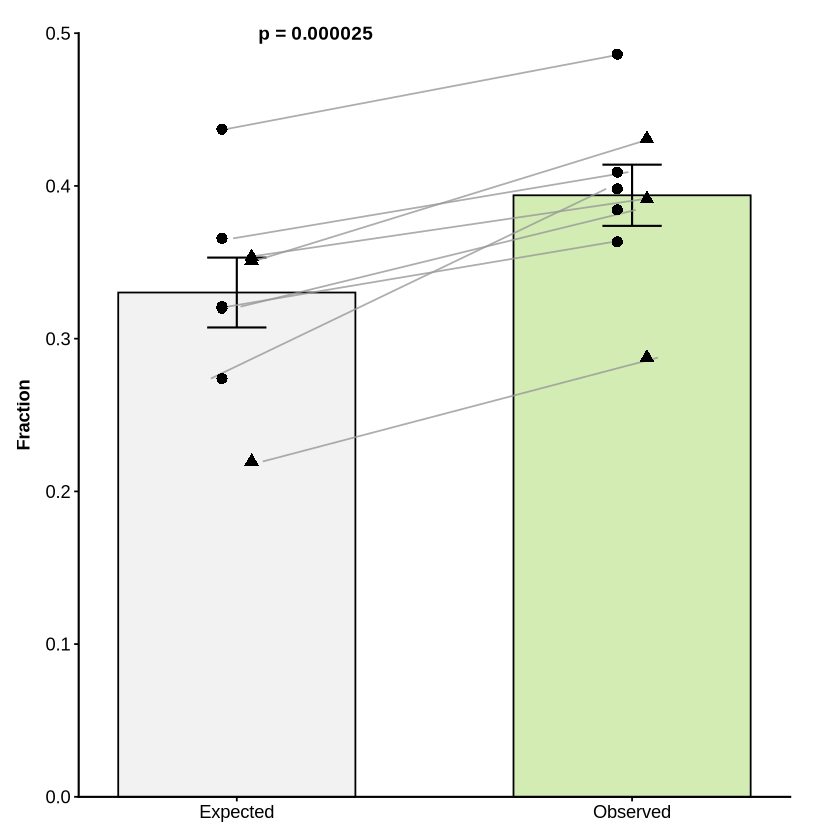

In [130]:
pA_no_legend

# Il1b - shuff
## load data

In [131]:
master_cluster_df_f <- file.path(image_analysis_results_data, "2026_06_13_E16_first5_images_neighbor_analysis_and_Il1b_mean_shuf_functions.csv")
file.exists(master_cluster_df_f)

[1] TRUE

In [132]:
master_il1b_df <- read.csv(master_cluster_df_f) 
master_il1b_df <- master_il1b_df %>% 
            dplyr::select( -ends_with("F4_80"))

In [133]:
master_il1b_df %>% slice_sample(n = 5)

image_batch,batch,batch_pub,cluster_cells,cluster_id,cluster_area,real_mean_Il1b,shuf_1_Il1b,shuf_2_Il1b,shuf_3_Il1b,⋯,shuf_4991_Il1b,shuf_4992_Il1b,shuf_4993_Il1b,shuf_4994_Il1b,shuf_4995_Il1b,shuf_4996_Il1b,shuf_4997_Il1b,shuf_4998_Il1b,shuf_4999_Il1b,shuf_5000_Il1b
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
M6_Series013,M6,M5,"481,501,507",4,5787.413,140.3333,86.00000,96.00000,119.50000,⋯,95.33333,88.00000,88.00000,88.00000,80.66667,183.00000,88.0000,110.33333,99.60000,73.00000
M4_Series007,M4,M3,"280,294,303,328,333,353,367,372,403",4,21323.140,163.2222,76.22222,118.77778,87.00000,⋯,93.55556,76.33333,100.02222,103.33333,96.77778,93.55556,85.0000,125.22222,85.00000,120.88889
M5_Series009,M5,M4,"632,657,676,696,700,730,778,801,812,817,822,823,828,832,842,845,848,857,860,862,865,866,867,870,874,879,887,891,898,907,910,913",1,54594.991,114.6875,63.21875,60.68750,56.84375,⋯,70.04063,53.84375,67.68750,60.00000,56.09375,62.50000,53.9250,68.37500,56.03125,52.67500
M6_Series007,M6,M5,"87,98,102,109,112",1,9591.158,101.6000,92.80000,92.40000,101.40000,⋯,83.60000,122.40000,97.00000,117.64000,119.40000,87.80000,126.0000,95.60000,74.60000,104.80000
M6_Series002,M6,M5,"427,439,451,456,472,475,484",2,19098.317,171.4857,87.28571,80.28571,155.00000,⋯,103.57143,112.57143,79.42857,74.71429,132.28571,93.48571,119.1429,67.71429,141.28571,64.28571


In [134]:
master_il1b_df  %>%  pull(batch_pub) %>% unique()

[1] "M1" "M2" "M3" "M4" "M5"

### calculation of mean observed/expected & effect size

In [135]:
library(dplyr)

batch_means_il1b_df <- master_il1b_df %>% 
  # 1. Target the IL-1b shuffles (FIXED: rowwise + base::mean + c_across)
  dplyr::rowwise() %>%
  dplyr::mutate(expected_Il1b = base::mean(c_across(starts_with("shuf_")), na.rm = TRUE)) %>%
  dplyr::ungroup() %>%
  
  dplyr::group_by(batch_pub) %>%
  

  dplyr::summarise(
    n_clusters = dplyr::n(), 
    mean_observed = base::mean(real_mean_Il1b, na.rm = TRUE),
    mean_expected = base::mean(expected_Il1b, na.rm = TRUE),
    # wilcox_p_val = suppressWarnings(
    #   stats::wilcox.test(real_mean_il1b, expected_il1b  , paired = TRUE)$p.value
    # ),
    dplyr::across(starts_with("shuf_"), ~base::mean(.x, na.rm = TRUE), .names = "shuf_mean_{.col}"),
    .groups = "drop"
  ) %>%  
  
  # 3. Perform batch-level permutation statistics
  dplyr::rowwise() %>%
  dplyr::mutate(
    shuf_vals = list(c_across(starts_with("shuf_mean_"))),
    # Unlisting is safer here to ensure p-value calculation is numeric
    perm_p_val = sum(unlist(shuf_vals) >= mean_observed) / length(unlist(shuf_vals)),
    effect_size = (mean_observed - mean_expected) / sd(unlist(shuf_vals)),
    null_ci_lower = quantile(unlist(shuf_vals), 0.025),
    null_ci_upper = quantile(unlist(shuf_vals), 0.975),
  ) %>%  
  dplyr::ungroup() %>%
  
  # 4. Reorganize
  dplyr::relocate(perm_p_val,  effect_size, null_ci_lower, null_ci_upper,   .after = mean_expected) # wilcox_p_val

In [136]:
# options(tibble.width = Inf, tibble.print_min = 5, tibble.print_max = 7 )
# print(batch_means_il1b_df)
batch_means_il1b_df %>% pull(batch_pub) %>%  unique()

[1] "M1" "M2" "M3" "M4" "M5"

In [137]:
print(batch_means_il1b_df)

# A tibble: 5 × 5,009
  batch_pub n_clusters mean_observed mean_expected perm_p_val effect_size
  <chr>          <int>         <dbl>         <dbl>      <dbl>       <dbl>
1 M1                17          129.          61.0          0        9.15
2 M2                40          181.          94.6          0       19.5 
3 M3                48          110.          89.2          0        8.87
4 M4                22          122.          85.6          0       10.6 
5 M5                41          118.          82.2          0       12.3 
# ℹ 5,003 more variables: null_ci_lower <dbl>, null_ci_upper <dbl>,
#   shuf_mean_shuf_1_Il1b <dbl>, shuf_mean_shuf_2_Il1b <dbl>,
#   shuf_mean_shuf_3_Il1b <dbl>, shuf_mean_shuf_4_Il1b <dbl>,
#   shuf_mean_shuf_5_Il1b <dbl>, shuf_mean_shuf_6_Il1b <dbl>,
#   shuf_mean_shuf_7_Il1b <dbl>, shuf_mean_shuf_8_Il1b <dbl>,
#   shuf_mean_shuf_9_Il1b <dbl>, shuf_mean_shuf_10_Il1b <dbl>,
#   shuf_mean_shuf_11_Il1b <dbl>, shuf_mean_shuf_12_Il1b <dbl>, …


### T-test on standard scale (effect size) shuff Il1b 

In [139]:
# Run a One-Sample T-Test on your 5 effect sizes
# mu = 0 sets your "random chance" baseline
# alternative = "greater" asks if the clustering is strictly positive
t_test_results_il1b <- t.test(batch_means_il1b_df$effect_size, mu = 0, alternative = "greater")

# Print the full statistical output
message("One-Sample T-Test Results for Batch-Level Effect Sizes Mac shuffle Analysis")
print(t_test_results_il1b)

One-Sample T-Test Results for Batch-Level Effect Sizes Mac shuffle Analysis




	One Sample t-test

data:  batch_means_il1b_df$effect_size
t = 6.1873, df = 4, p-value = 0.001734
alternative hypothesis: true mean is greater than 0
95 percent confidence interval:
 7.920082      Inf
sample estimates:
mean of x 
 12.08343 



In [140]:
# 1. Pivot and clean
df_il1b_shuf_wilcoxon <- batch_means_il1b_df %>%
  pivot_longer(
    cols = c(mean_observed, mean_expected),
    names_to = "fraction_type",
    values_to = "mean_value"
  ) %>% 
  dplyr::select(-starts_with('shuf_mean')) %>%
  rename_with(tolower) %>% 
  mutate(
    # Use the lowercase strings that 'pivot_longer' created
    fraction_type = ifelse(fraction_type == "mean_observed", "Observed", "Expected"),
    fraction_type = factor(fraction_type, levels = c("Expected", "Observed"))
  )


# R base amir style 

In [141]:
library(patchwork)
library(ggrepel)
library(grid)

# ==========================================
# DIRECTORY SETUP
# ==========================================
JUN14 <- date_str(2026, 6, 14)

figs_JUN14_shuff_il1b_v3 <- file.path(
  image_analysis_results_figs,
  paste0(JUN14, "_shuff_Il1b_pub")
)
if (!dir.exists(figs_JUN14_shuff_il1b_v3)) {
  dir.create(figs_JUN14_shuff_il1b_v3, recursive = TRUE)
}

p_val_il1b <- paste0("p = ", formatC(t_test_results_il1b$p.value, format = "f", digits = 3))
# Staining design: Neutral gray for control, soft alpha-green for tissue reality
fill_palette <- c("Expected" = "gray90","Observed" = scales::alpha("#FFF5EE", 0.35))


# ==========================================
# SHARED THEME
# FIX 1: legend.position and plot.margin live HERE so theme_publication()
#         is always the last word — calling it last in the plot chain
#         previously let theme_classic() reset those settings silently.
# ==========================================
theme_publication <- function(...) {
  theme_classic(...) +
    theme(
      axis.line       = element_line(color = "black", linewidth = 0.6),
      axis.ticks      = element_line(color = "black", linewidth = 0.5),
      axis.text       = element_text(color = "black", size = 11),
      axis.title.y    = element_text(color = "black", size = 11, face = "bold",
                                     margin = margin(r = 6)),
      axis.title.x    = element_blank(),
      panel.border    = element_blank(),
      legend.position = "none",                          # was being overridden
      plot.margin     = margin(t = 20, r = 30, b = 10, l = 10)
    )
}

# ==========================================
# PANEL A: BAR PLOT
# ==========================================
pA <- ggplot(df_il1b_shuf_wilcoxon, aes(x = fraction_type, y = mean_value)) +

  # 1. Background bars — FIX 2: map fill to fraction_type so scale_fill_manual fires.
  #    Previously hardcoded fill = "gray90" with no aesthetic mapping meant
  #    scale_fill_manual was dead code and fill_palette was never applied.
  stat_summary(aes(fill = fraction_type),
    fun = mean, 
    geom = "bar",
    color = "black", 
    linewidth = 0.5, 
    width = 0.6) +
  # 2. ±SE error bars
  stat_summary(fun.data = mean_se, 
    geom = "errorbar",
    color = "black", 
    linewidth = 0.6, 
    width = 0.15 ) +

  # 3. Paired-batch connecting lines
  geom_line(aes(group = batch_pub), 
    color = "gray60", 
    linewidth = 0.5, 
    alpha = 0.8) +
  # 4. Individual data points
  geom_point(color = "black", 
    size = 2.5,
    shape = 16, 
    position = position_identity()) +

  scale_fill_manual( values = fill_palette, guide  = "none") +

  scale_y_continuous(
    limits = c(0, 200),
    expand = c(0, 0),
    breaks = seq(0, 200, by = 50)
  ) +
  scale_x_discrete(
    expand = expansion(mult = c(0.4, 0.4)),
    labels = c("Expected", "Observed")) +

  coord_cartesian(clip = "off") +
  labs(y = "Fraction") +

  #  p-value annotation — anchored to y = 195 (axis ceiling = 200)
  annotate("text",
    x        = 1.5,
    y        = 195,
    label    = p_val_il1b,
    fontface = "bold",
    size     = 4  ) +
  theme_publication()   # called once, last — owns all theme state

# ==========================================
# MULTI-FORMAT EXPORT
# ==========================================
message("Saving plots...")

cairo_pdf(
  file.path(figs_JUN14_shuff_il1b_v3, paste0(JUN14, "_Il1b_Barplot.pdf")),
  width = 3.2, height = 6
)
print(pA)
dev.off()

png(
  file.path(figs_JUN14_shuff_il1b_v3, paste0(JUN14, "_Il1b_Barplot.png")),
  width = 3.2, height = 6, units = "in", res = 600
)
print(pA)
dev.off()

message("Export complete.")

Saving plots...



agg_record_105001883 
                   2

agg_record_105001883 
                   2

Export complete.



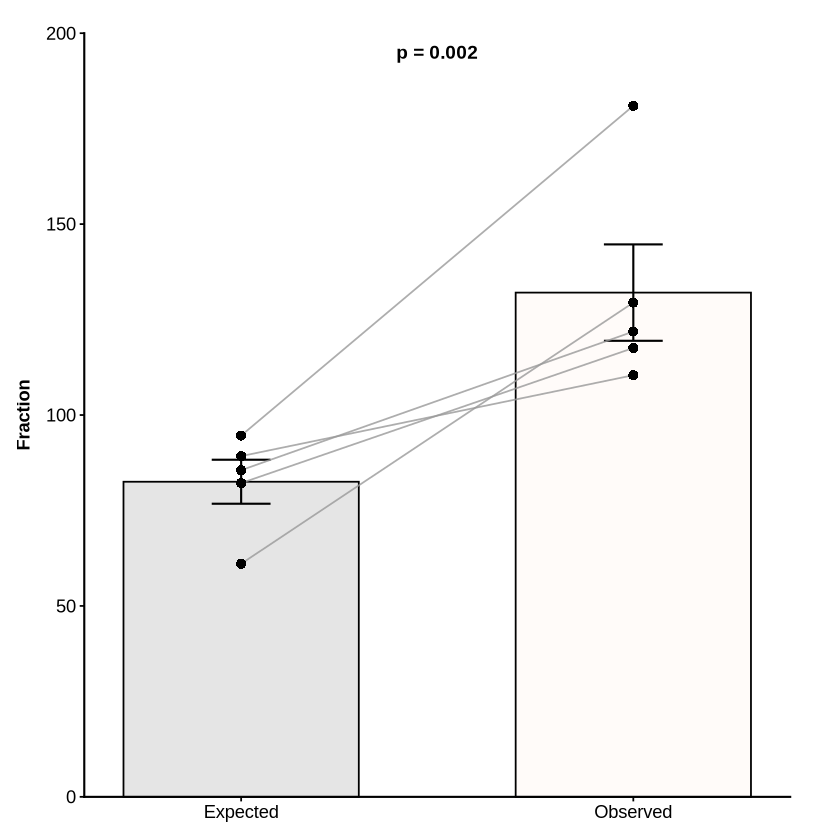

In [150]:
pA

# Mosaic plots final

In [ ]:

JUN14  <- date_str(2026, 6, 14)
series_target <- "M3_Series008"

# High-contrast styling parameters
neon_mk_color     <- "#FFFF00"  # Electric Neon Yellow
tile_border_color <- "gray40"   # Soften background tile borders

figs_JUN14_mosaic <- file.path(image_analysis_results_figs, paste0(JUN14, "_mosaic_Il1b"))
if(!dir.exists(figs_JUN14_mosaic)) {
    dir.create(figs_JUN14_mosaic, recursive = TRUE)
}


In [ ]:


# with_plot <- 2000
# height_plot <- 2000
# res_plot <- 300
# IMAGE_DIM <- 2000

# # Ensure your phenotype label matches exactly
# MK_PHENOTYPE_LABEL <- "cd41" 

# for (series in series_target) {
#     message(paste0("Processing Publication Assets for: ", series))

#     # 1. Load the raw spatial data
#     nuclei_sub <- nuclei_full_data %>% filter(image_batch == series)
#     if (nrow(nuclei_sub) == 0) next
    
#     x <- as.numeric(nuclei_sub$location_center_x)
#     y <- as.numeric(nuclei_sub$location_center_y)
    
#     # 2. Base tiles
#     tesselation <- deldir(x, y)
#     tiles       <- tile.list(tesselation)
    
#     # 3. Clean labels
#     ctypes_clean <- tolower(trimws(as.character(nuclei_sub$phenotype)))
#     cd41_indices <- which(ctypes_clean == MK_PHENOTYPE_LABEL)
    
#     # 4. Color Gradient Generation
#     vals        <- nuclei_sub$q90_il1b
#     vals_n      <- round(100 * (vals / max(vals, na.rm = TRUE)) + 1)
#     grad        <- colorRampPalette(c("white", "pink", "red", "purple", "navy"))(101)
#     tile_colors <- grad[vals_n]

#     # File prefixes & dimensions
#     prefix  <- file.path(figs_JUN02_mosaic, paste0(JUN02, "_IL1b_Mosaic_", series))
#     pdf_dim <- 8.33

#     # ==========================================================================
#     # VARIATION 1: PLOT WITH LEGEND
#     # ==========================================================================
#     # PNG
#     png(paste0(prefix, "_WithLegend.png"), width = with_plot, height = height_plot, res = res_plot)
#     par(mar = c(1, 1, 1, 8), bg = "white")
    
#     # 🚨 FIX 1: Strict bounding box (0 to 2000) using xaxs/yaxs = "i" to slice off edges
#     plot(1, 1, type = "n", xlim = c(0, IMAGE_DIM), ylim = c(0, IMAGE_DIM), axes = FALSE, ann = FALSE, bty = "n", asp = 1, xaxs = "i", yaxs = "i")
    
#     # RESTORED: The original, working background tile renderer
#     plot(tiles, pch = 19, cex = 0, add = TRUE, border = "black", fill = tile_colors)
    
#     if (length(cd41_indices) > 0) {
#         for (i in cd41_indices) {
#             polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = "#FFFF00", lwd = 2.5)
#         }
#     }
#     fields::image.plot(legend.only = TRUE, zlim = c(0, max(vals, na.rm = TRUE)), col = grad, legend.shrink = 0.6, legend.width = 1.5, legend.lab = "IL-1b Intensity (q90)", legend.line = 3, legend.cex = 1.2, axis.args = list(cex.axis = 1.2))
#     dev.off()

#     # PDF
#     cairo_pdf(paste0(prefix, "_WithLegend.pdf"), width = pdf_dim, height = pdf_dim, fallback_resolution = 300)
#     par(mar = c(1, 1, 1, 8), bg = "white")
    
#     # 🚨 FIX 1 Applied to PDF
#     plot(1, 1, type = "n", xlim = c(0, IMAGE_DIM), ylim = c(0, IMAGE_DIM), axes = FALSE, ann = FALSE, bty = "n", asp = 1, xaxs = "i", yaxs = "i")
#     plot(tiles, pch = 19, cex = 0, add = TRUE, border = "black", fill = tile_colors)
    
#     if (length(cd41_indices) > 0) {
#         for (i in cd41_indices) {
#             polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = "#FFFF00", lwd = 2.5)
#         }
#     }
#     fields::image.plot(legend.only = TRUE, zlim = c(0, max(vals, na.rm = TRUE)), col = grad, legend.shrink = 0.6, legend.width = 1.5, legend.lab = "IL-1b Intensity (q90)", legend.line = 3, legend.cex = 1.2, axis.args = list(cex.axis = 1.2))
#     dev.off()

#     # ==========================================================================
#     # VARIATION 2: PLOT ONLY (NO LEGEND)
#     # ==========================================================================
#     # PNG
#     png(paste0(prefix, "_NoLegend.png"), width = with_plot, height = height_plot, res = res_plot)
#     par(mar = c(1, 1, 1, 1), bg = "white")
    
#     # 🚨 FIX 1 Applied
#     plot(1, 1, type = "n", xlim = c(0, IMAGE_DIM), ylim = c(0, IMAGE_DIM), axes = FALSE, ann = FALSE, bty = "n", asp = 1, xaxs = "i", yaxs = "i")
#     plot(tiles, pch = 19, cex = 0, add = TRUE, border = "black", fill = tile_colors)
    
#     if (length(cd41_indices) > 0) {
#         for (i in cd41_indices) {
#             polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = "#FFFF00", lwd = 2.5)
#         }
#     }
#     dev.off()

#     # PDF
#     cairo_pdf(paste0(prefix, "_NoLegend.pdf"), width = pdf_dim, height = pdf_dim, fallback_resolution = 300)
#     par(mar = c(1, 1, 1, 1), bg = "white")
    
#     # 🚨 FIX 1 Applied
#     plot(1, 1, type = "n", xlim = c(0, IMAGE_DIM), ylim = c(0, IMAGE_DIM), axes = FALSE, ann = FALSE, bty = "n", asp = 1, xaxs = "i", yaxs = "i")
#     plot(tiles, pch = 19, cex = 0, add = TRUE, border = "black", fill = tile_colors)
    
#     if (length(cd41_indices) > 0) {
#         for (i in cd41_indices) {
#             polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = "#FFFF00", lwd = 2.5)
#         }
#     }
#     dev.off()

#     # ==========================================================================
#     # VARIATION 3: LEGEND ONLY
#     # ==========================================================================
#     # PNG
#     # 🚨 FIX 2: Canvas widened to 1200px, margin pushed to 12 to leave room for text
#     png(paste0(prefix, "_LegendOnly.png"), width = 1200, height = 2500, res = 300)
#     par(mar = c(2, 2, 2, 12), bg = "white") 
#     plot(1, 1, type = "n", axes = FALSE, ann = FALSE, bty = "n")
#     fields::image.plot(legend.only = TRUE, zlim = c(0, max(vals, na.rm = TRUE)), col = grad, legend.shrink = 0.8, legend.width = 2.5, legend.lab = "IL-1b Intensity (q90)", legend.line = 4.5, legend.cex = 1.5, axis.args = list(cex.axis = 1.5))
#     dev.off()

#     # PDF
#     # 🚨 FIX 2: Canvas widened to 4 inches, margin pushed to 12
#     cairo_pdf(paste0(prefix, "_LegendOnly.pdf"), width = 4, height = pdf_dim, fallback_resolution = 300)
#     par(mar = c(2, 2, 2, 12), bg = "white")
#     plot(1, 1, type = "n", axes = FALSE, ann = FALSE, bty = "n")
#     fields::image.plot(legend.only = TRUE, zlim = c(0, max(vals, na.rm = TRUE)), col = grad, legend.shrink = 0.8, legend.width = 2.5, legend.lab = "IL-1b Intensity (q90)", legend.line = 4.5, legend.cex = 1.5, axis.args = list(cex.axis = 1.5))
#     dev.off()

#     # Memory cleanup
#     rm(tesselation, tiles, nuclei_sub)
#     gc()
# }

# log_info("All publication grade assets (PNG & PDF) generated successfully!")

## V2 plots mosaic 

In [ ]:
library(dplyr)
library(deldir)
library(fields)

with_plot <- 2000
height_plot <- 2000
res_plot <- 300
IMAGE_DIM <- 2000

# Ensure your phenotype label matches exactly
MK_PHENOTYPE_LABEL <- "cd41" 

for (series in series_target) {
    message(paste0("Processing Publication Assets for: ", series))

    # 1. Load the raw spatial data
    nuclei_sub <- nuclei_full_data %>% filter(image_batch == series)
    if (nrow(nuclei_sub) == 0) next
    
    x <- as.numeric(nuclei_sub$location_center_x)
    y <- as.numeric(nuclei_sub$location_center_y)
    
    # 2. Base tiles
    tesselation <- deldir(x, y)
    tiles       <- tile.list(tesselation)
    
    # 3. Clean labels
    ctypes_clean <- tolower(trimws(as.character(nuclei_sub$phenotype)))
    cd41_indices <- which(ctypes_clean == MK_PHENOTYPE_LABEL)
    
    # 4. Color Gradient Generation
    vals        <- nuclei_sub$q90_il1b
    vals_n      <- round(100 * (vals / max(vals, na.rm = TRUE)) + 1)
    grad        <- colorRampPalette(c("white", "pink", "red", "purple", "navy"))(101)
    tile_colors <- grad[vals_n]

    # File prefixes & dimensions
    prefix  <- file.path(figs_JUN02_mosaic, paste0(JUN02, "_IL1b_Mosaic_", series))
    pdf_dim <- 8.33

    # ==========================================================================
    # VARIATION 1: PLOT WITH LEGEND
    # ==========================================================================
    # PNG
    png(paste0(prefix, "_WithLegend_v2.png"), width = with_plot, height = height_plot, res = res_plot)
    par(mar = c(1, 1, 1, 8), bg = "white")
    
    # 🚨 FIX 1: Strict bounding box acts as a cookie-cutter to slice off infinite edges
    plot(1, 1, type = "n", xlim = c(0, IMAGE_DIM), ylim = c(0, IMAGE_DIM), axes = FALSE, ann = FALSE, bty = "n", asp = 1, xaxs = "i", yaxs = "i")
    
    # 🚨 FIX 2: Draw EVERY tile to prevent holes. The plot boundaries handle the trimming.
    for (i in seq_along(tiles)) {
        polygon(tiles[[i]]$x, tiles[[i]]$y, col = tile_colors[i], border = "gray20", lwd = 0.5)
    }
    
    if (length(cd41_indices) > 0) {
        for (i in cd41_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = "#FFFF00", lwd = 2.5)
        }
    }
    fields::image.plot(legend.only = TRUE, zlim = c(0, max(vals, na.rm = TRUE)), col = grad, legend.shrink = 0.6, legend.width = 1.5, legend.lab = "IL-1b Intensity (q90)", legend.line = 3, legend.cex = 1.2, axis.args = list(cex.axis = 1.2))
    dev.off()

    # PDF
    cairo_pdf(paste0(prefix, "_WithLegend_v2.pdf"), width = pdf_dim, height = pdf_dim, fallback_resolution = 300)
    par(mar = c(1, 1, 1, 8), bg = "white")
    plot(1, 1, type = "n", xlim = c(0, IMAGE_DIM), ylim = c(0, IMAGE_DIM), axes = FALSE, ann = FALSE, bty = "n", asp = 1, xaxs = "i", yaxs = "i")
    
    for (i in seq_along(tiles)) {
        polygon(tiles[[i]]$x, tiles[[i]]$y, col = tile_colors[i], border = "gray20", lwd = 0.5)
    }
    
    if (length(cd41_indices) > 0) {
        for (i in cd41_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = "#FFFF00", lwd = 2.5)
        }
    }
    fields::image.plot(legend.only = TRUE, zlim = c(0, max(vals, na.rm = TRUE)), col = grad, legend.shrink = 0.6, legend.width = 1.5, legend.lab = "IL-1b Intensity (q90)", legend.line = 3, legend.cex = 1.2, axis.args = list(cex.axis = 1.2))
    dev.off()

    # ==========================================================================
    # VARIATION 2: PLOT ONLY (NO LEGEND)
    # ==========================================================================
    # PNG
    png(paste0(prefix, "_NoLegend_v2.png"), width = with_plot, height = height_plot, res = res_plot)
    par(mar = c(1, 1, 1, 1), bg = "white")
    plot(1, 1, type = "n", xlim = c(0, IMAGE_DIM), ylim = c(0, IMAGE_DIM), axes = FALSE, ann = FALSE, bty = "n", asp = 1, xaxs = "i", yaxs = "i")
    
    for (i in seq_along(tiles)) {
        polygon(tiles[[i]]$x, tiles[[i]]$y, col = tile_colors[i], border = "gray20", lwd = 0.5)
    }
    
    if (length(cd41_indices) > 0) {
        for (i in cd41_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = "#FFFF00", lwd = 2.5)
        }
    }
    dev.off()

    # PDF
    cairo_pdf(paste0(prefix, "_NoLegend_v2.pdf"), width = pdf_dim, height = pdf_dim, fallback_resolution = 300)
    par(mar = c(1, 1, 1, 1), bg = "white")
    plot(1, 1, type = "n", xlim = c(0, IMAGE_DIM), ylim = c(0, IMAGE_DIM), axes = FALSE, ann = FALSE, bty = "n", asp = 1, xaxs = "i", yaxs = "i")
    
    for (i in seq_along(tiles)) {
        polygon(tiles[[i]]$x, tiles[[i]]$y, col = tile_colors[i], border = "gray20", lwd = 0.5)
    }
    
    if (length(cd41_indices) > 0) {
        for (i in cd41_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = "#FFFF00", lwd = 2.5)
        }
    }
    dev.off()

    # ==========================================================================
    # VARIATION 3: LEGEND ONLY
    # ==========================================================================
    # PNG
    # 🚨 FIX 3: Canvas dramatically widened (1200) and right margin increased (12) to fit text
    png(paste0(prefix, "_LegendOnly_v2.png"), width = 1200, height = 2500, res = 300)
    par(mar = c(2, 2, 2, 12), bg = "white")
    plot(1, 1, type = "n", axes = FALSE, ann = FALSE, bty = "n")
    fields::image.plot(legend.only = TRUE, zlim = c(0, max(vals, na.rm = TRUE)), col = grad, legend.shrink = 0.8, legend.width = 3, legend.lab = "IL-1b Intensity (q90)", legend.line = 4.5, legend.cex = 1.8, axis.args = list(cex.axis = 1.6))
    dev.off()

    # PDF
    cairo_pdf(paste0(prefix, "_LegendOnly_v2.pdf"), width = 4, height = pdf_dim, fallback_resolution = 300)
    par(mar = c(2, 2, 2, 12), bg = "white")
    plot(1, 1, type = "n", axes = FALSE, ann = FALSE, bty = "n")
    fields::image.plot(legend.only = TRUE, zlim = c(0, max(vals, na.rm = TRUE)), col = grad, legend.shrink = 0.8, legend.width = 3, legend.lab = "IL-1b Intensity (q90)", legend.line = 4.5, legend.cex = 1.8, axis.args = list(cex.axis = 1.6))
    dev.off()

    # Memory cleanup
    rm(tesselation, tiles, nuclei_sub)
    gc()
}

log_info("All publication grade assets (PNG & PDF) generated successfully!")

## v3 melting border 

In [ ]:
#!/usr/bin/env Rscript

# =============================================================================
# CD41 Publication-Tier Spatial Visualization Pipeline
# Generates dissolved, organic-shaped Megakaryocyte (MK) clusters using 'sf'
# =============================================================================

library(dplyr)
library(deldir)
library(grDevices)
library(sf)

# =============================================================================
# PRODUCTION DRAWING FUNCTION
# =============================================================================
draw_cd41_pub_map <- function() {
    # 0 margins for a perfect edge-to-edge canvas
    par(mar = c(0, 0, 0, 0), bg = "black")
    
    # Initialize blank structural canvas matching image dimensions
    plot(1, 1, type = "n", xlim = c(1, max(x_range)), ylim = c(1, max(y_range)), 
         axes = FALSE, xlab = "", ylab = "", asp = 1, xaxs = "i", yaxs = "i")
    clip(1, max(x_range), 1, max(y_range))
    
    # Layer 1: High-Contrast Grayscale IF Background Image
    image(x_range, y_range, cd41_curr_img,
          col = colorRampPalette(c("black", "gray30", "gray90"))(1000), 
          zlim = c(0, 255), add = TRUE)
    

    # mk_fill_color <- adjustcolor("#00FFFF", alpha.f = 0.35) 
    mk_line_color <- adjustcolor("#00FFFF", alpha.f = 0.90) # Dominant Cyan outline
    nuc_color     = "#D55E00" # Okabe-Ito Vermillion (Colorblind safe red/orange)
    
    # Layer 2: Compute and Draw Dissolved MK Clusters
    for (cid in unique(img_clusters$cluster_id)) {
        cluster_info <- img_clusters %>% filter(cluster_id == cid)
        cluster_cells_rel <- as.numeric(unlist(strsplit(cluster_info$cluster_cells_relative, ",")))
        target_idx_full <- small_idx[cluster_cells_rel]
        
        # Guard rail: Skip empty or unmapped spatial clusters
        if (length(target_idx_full) == 0) next
        
        # Convert raw Voronoi tiles to standard 'sf' polygon structures
        poly_list <- lapply(target_idx_full, function(i) {
            coords <- cbind(tiles[[i]]$x, tiles[[i]]$y)
            # Close the polygon loop (sf requirement: first point == last point)
            coords <- rbind(coords, coords[1, ])
            st_polygon(list(coords))
        })
        
        # Combine into an sf collection and mathematically merge (union) the walls
        cluster_sfc <- st_sfc(poly_list)
        merged_cluster <- st_union(cluster_sfc)
        
        # Biological Smoothing Pass: Round off sharp, jagged geometric tile corners
        # Expands the shape outward by 2 units, then shrinks it back by 2 units
        merged_cluster <- st_buffer(merged_cluster, dist = 2)
        merged_cluster <- st_buffer(merged_cluster, dist = -2)
        
        # Draw the single, perfect unified shape wrapper
        # CRITICAL FIX: Wrapped inside st_geometry() to protect base R graphics overlay
        plot(st_geometry(merged_cluster), 
             col = mk_fill_color, 
             border = mk_line_color, 
             lwd = 1.2, 
             add = TRUE)
    }
    
    # Layer 3: Overlay Minimalist Nuclei Anchors
    all_clustered_rel <- as.numeric(unlist(strsplit(paste(img_clusters$cluster_cells_relative, collapse=","), ",")))
    all_clustered_idx <- small_idx[all_clustered_rel]
    
    if (length(all_clustered_idx) > 0) {
        # Solid Vermillion dots with NO heavy black stroke outlines (col = NA)
        points(x[all_clustered_idx], y[all_clustered_idx], 
               pch = 21, bg = nuc_color, col = NA, cex = 1.1)
    }
    
    box(lwd = 2, col = "black") # Optional: Add a clean white border around the entire plot
}

# =============================================================================
# ENVIRONMENT & RUNTIME SETUP
# =============================================================================
max_size_idx <- 4e3 
series_val   <- "M3_Series008"

# Create a dedicated, clean folder for your visual maps
JUN04 <- date_str(2026, 6, 4)
out_cd41_test <- file.path(image_analysis_results_figs, paste0(JUN04, "_CD41_cluster_map"))
if (!dir.exists(out_cd41_test)) dir.create(out_cd41_test, showWarnings = FALSE)

message("Starting CD41 Cluster Visualization Execution...")

# =============================================================================
# PROCESSING PIPELINE
# =============================================================================
for (series in series_val) {
    message("Processing and rendering dissolved contours for: ", series)
    
    # 1. Isolate spatial coordinate tables
    nuclei_sub <- nuclei_full_data %>% filter(image_batch == series)
    x <- nuclei_sub$location_center_x
    y <- nuclei_sub$location_center_y
    
    if (length(x) < 3) {
        message("Skipping ", series, " — insufficient nuclei coordinates to construct triangulation.")
        next
    }
    
    # 2. Extract corresponding multiplexed CD41 IF image array
    curr_series_img <- grep(series, names(all_images), value = TRUE)
    cd41_curr_img <- all_images[[ grep("CD41", curr_series_img, value = TRUE) ]]
    
    x_range <- seq_len(nrow(cd41_curr_img))
    y_range <- seq_len(ncol(cd41_curr_img))
    
    # 3. Calculate Voronoi Tessellation mesh layout
    tesselation <- deldir(x, y)
    tiles <- tile.list(tesselation)
    areas <- sapply(tiles, function(t) poly_area(t$x, t$y))
    small_idx <- which(areas < max_size_idx) 
    
    # 4. Filter down to current image clusters mapping tracking vector
    img_clusters <- master_cluster_df %>% filter(image_batch == series)
    plot_filename_base <- file.path(out_cd41_test, paste0(JUN04, "_CD41_Cluster_Test_v2_", series))

    # =========================================================================
    # EXPORT ENGINES
    # =========================================================================
    message("Rendering scalable vector PDF for Illustrator editing...")
    cairo_pdf(paste0(plot_filename_base, ".pdf"), width = 6, height = 6, fallback_resolution = 300)
    draw_cd41_pub_map()
    dev.off()
    
    message("Rendering high-resolution raster PNG for quick screening...")
    png(paste0(plot_filename_base, ".png"), width = 2500, height = 2500, res = 300)
    draw_cd41_pub_map()
    dev.off()
    
    # 5. Clean up current image cache to protect server memory allocations
    rm(tesselation, tiles, nuclei_sub, cd41_curr_img, img_clusters)
    gc()
}

message("Pipeline processing complete! Files successfully generated in: ", out_cd41_test)

## V3 mosaic MK border merged 

In [148]:
# =============================================================================
# IL-1b Voronoi Mosaic — v3
# Change vs v2: MK (CD41) cluster borders are now dissolved sf contours
# instead of per-tile polygon outlines. st_union naturally separates
# spatially disconnected MK groups; double-buffer smoothing removes
# jagged tile corners for publication-grade organic boundaries.
# =============================================================================

library(dplyr)
library(deldir)
library(fields)
library(sf)
library(grDevices)
# CONFIGURATION
cfg <- list(
  mk_phenotype    = "cd41",
  mk_border_color = "#FFFF00",          # yellow — matches v2 expectation
  mk_border_lwd   = 3,
  smooth_expand   =  3,                 # expand  (units = pixel coords)
  smooth_contract = -3,                 # contract — net shape unchanged
  image_dim       = 2000L,
  export_w        = 2000L,
  export_h        = 2000L,
  export_res      = 300L,
  pdf_dim         = 8.33,
  date_tag        = date_str(2024, 6, 4)
)

# Colour ramp shared across all export variations
il1b_grad <- colorRampPalette(c("white", "pink", "red", "purple", "navy"))(101)


# HELPER: build dissolved MK contour as an sf geometry
# Returns an sfc object (may contain multiple polygons for disconnected groups),
# or NULL if no valid MK tiles are found.
build_mk_contour <- function(tiles, mk_indices) {
  if (length(mk_indices) == 0L) return(NULL)

  poly_list <- lapply(mk_indices, function(i) {
    tryCatch({
      coords <- cbind(tiles[[i]]$x, tiles[[i]]$y)
      coords <- rbind(coords, coords[1L, ])   # close ring
      st_polygon(list(coords))
    }, error = function(e) NULL)
  })
  poly_list <- Filter(Negate(is.null), poly_list)
  if (length(poly_list) == 0L) return(NULL)

  tryCatch({
    sfc     <- st_sfc(poly_list)
    unified <- st_union(sfc)                    # merges adjacent tiles; keeps disconnected groups separate
    unified <- st_buffer(unified,  cfg$smooth_expand)
    st_buffer(unified, cfg$smooth_contract)
  }, error = function(e) {
    message("  [warn] Could not build MK contour: ", conditionMessage(e))
    NULL
  })
}

# HELPER: draw one plot variant (no legend, with legend, or legend-only)
draw_mosaic <- function(tiles, tile_colors, mk_contour,
                        mar, show_tiles = TRUE, show_legend = TRUE,
                        zlim, legend_only = FALSE) {

  par(mar = mar, bg = "white")

  if (legend_only) {
    plot(1, 1, type = "n", axes = FALSE, ann = FALSE, bty = "n")
    fields::image.plot(
      legend.only = TRUE,
      zlim        = zlim,
      col         = il1b_grad,
      legend.shrink = 0.8,
      legend.width  = 3,
      legend.lab    = "IL-1b Intensity (q90)",
      legend.line   = 4.5,
      legend.cex    = 1.8,
      axis.args     = list(cex.axis = 1.6)
    )
    return(invisible(NULL))
  }

plot(NULL,
       xlim = c(0, cfg$image_dim), ylim = c(0, cfg$image_dim),
       axes = FALSE, ann = FALSE, bty = "n",
       asp = 1, xaxs = "i", yaxs = "i") # asp = 1 is restored!

  if (show_tiles) {
    # Draw every tile — plot boundary clips infinite edges
    for (i in seq_along(tiles)) {
      polygon(tiles[[i]]$x, tiles[[i]]$y,
              col    = tile_colors[i],
              border = "gray20",
              lwd    = 0.5)
    }
  }

  # Dissolved MK contour — one clean border per spatial group
  if (!is.null(mk_contour)) {
    plot(st_geometry(mk_contour),
         col    = NA,
         border = cfg$mk_border_color,
         lwd    = cfg$mk_border_lwd,
         add    = TRUE)
  }

if (show_legend) {
    fields::image.plot(
      legend.only = TRUE,
      zlim        = zlim,
      col         = il1b_grad,
      legend.shrink = 0.6,
      legend.width  = 1.5,
      legend.lab    = "IL-1b Intensity (q90)",
      legend.line   = 3,
      legend.cex    = 1.2,
      axis.args     = list(cex.axis = 1.2)
    )
  }
  
  # Draw a strict bounding box matching the exact Voronoi coordinate limits
  rect(xleft = 0, ybottom = 0, xright = cfg$image_dim, ytop = cfg$image_dim, 
       border = "black", lwd = 0.8, xpd = NA)

}

# EXPORT WRAPPER
export_pair <- function(prefix, suffix, width, height, res, pdf_w, pdf_h, draw_fn) {
  png(paste0(prefix, suffix, ".png"), width = width, height = height, res = res)
  draw_fn()
  dev.off()

  cairo_pdf(paste0(prefix, suffix, ".pdf"), width = pdf_w, height = pdf_h,
            fallback_resolution = 300)
  draw_fn()
  dev.off()
}
JUN14 <- date_str(2024, 6, 14)
figs_JUN14_mosaic <- file.path(image_analysis_results_figs, paste0(JUN14, "_IL1b_Mosaic_clusters_border"))
# MAIN PIPELINE
out_dir <- file.path(figs_JUN14_mosaic)   # use your existing output path
if (!dir.exists(out_dir)) dir.create(out_dir, showWarnings = FALSE)

for (series in series_target) {
  message("Processing: ", series)

  nuclei_sub <- nuclei_full_data |> filter(image_batch == series)
  if (nrow(nuclei_sub) == 0L) next

  x <- as.numeric(nuclei_sub$location_center_x)
  y <- as.numeric(nuclei_sub$location_center_y)

  # Voronoi tessellation
  tesselation  <- deldir(x, y)
  # Voronoi tessellation locked strictly to the image dimensions

  tiles        <- tile.list(tesselation)

  # Tile colours from IL-1b q90 values
  vals         <- nuclei_sub$q90_il1b
  vals_n       <- round(100 * (vals / max(vals, na.rm = TRUE)) + 1)
  tile_colors  <- il1b_grad[vals_n]

# MK identification
  ctypes_clean <- tolower(trimws(as.character(nuclei_sub$phenotype)))
  mk_indices   <- which(ctypes_clean == cfg$mk_phenotype)

  # ── CLUSTER FILTER ────────────────────────────────────────────────────────
  clustered_mk_indices <- integer(0)

  if (length(mk_indices) >= 2) {
    net      <- build_spatial_network(nuclei_sub, max_dist = CONFIG$MAX_DIST)
    clusters <- identify_clusters(
      touching_nb      = net$touching_nb,
      ct               = ctypes_clean,
      target_type      = cfg$mk_phenotype,
      min_good_targets = CONFIG$MIN_NUM_CLUST
    )
    if (!is.null(clusters)) {
      in_good_cluster      <- as.character(clusters$nuc2target) %in%
                              as.character(clusters$good_targets)
      clustered_mk_indices <- as.integer(names(clusters$nuc2target)[in_good_cluster])
    }
  }

  message(sprintf("  [%s] MK total: %d  |  in valid clusters: %d",
                  series, length(mk_indices), length(clustered_mk_indices)))
  # ─────────────────────────────────────────────────────────────────────────

  # Build dissolved contour from clustered indices only
  message("  Building dissolved MK contour (", length(clustered_mk_indices), " tiles)...")
  mk_contour <- build_mk_contour(tiles, clustered_mk_indices)

  zlim   <- c(0, max(vals, na.rm = TRUE))
  prefix <- file.path(out_dir, paste0(cfg$date_tag, "_IL1b_Mosaic_", series))

  # ── Variation 1: with legend ──────────────────────────────────────────────
  # message("  Exporting: WithLegend")
  # export_pair(prefix, "_WithLegend_v3",
  #             cfg$export_w, cfg$export_h, cfg$export_res,
  #             cfg$pdf_dim,  cfg$pdf_dim,
  #             function() draw_mosaic(tiles, tile_colors, mk_contour,
  #                                    mar          = c(1, 1, 1, 8),
  #                                    show_legend  = TRUE,
  #                                    zlim         = zlim))

  # ── Variation 2: no legend ────────────────────────────────────────────────
  message("  Exporting: NoLegend")
  export_pair(prefix, "_NoLegend_v3",
              cfg$export_w, cfg$export_h, cfg$export_res,
              cfg$pdf_dim,  cfg$pdf_dim,
              function() draw_mosaic(tiles, tile_colors, mk_contour,
                                     mar         = c(1, 1, 1, 1),
                                     show_legend = FALSE,
                                     zlim        = zlim))

  # ── Variation 3: legend strip only ───────────────────────────────────────
  message("  Exporting: LegendOnly")
  export_pair(prefix, "_LegendOnly_v3",
              1200L, 2500L, 300L,
              4, cfg$pdf_dim,
              function() draw_mosaic(tiles, tile_colors, mk_contour,
                                     mar         = c(2, 2, 2, 12),
                                     legend_only = TRUE,
                                     zlim        = zlim))

  rm(tesselation, tiles, nuclei_sub, mk_contour)
  gc()
}

message("Done. Output: ", out_dir)

Processing: M3_Series008

  [M3_Series008] MK total: 56  |  in valid clusters: 55

  Building dissolved MK contour (55 tiles)...

  Exporting: NoLegend

  Exporting: LegendOnly

Done. Output: /mc_disk1/data/Maiia_hemato_images/image_analysis_results/figures/2024_06_14_IL1b_Mosaic_clusters_border



# correlation viz - Il1b Mac Neighbors

In [ ]:
master_cluster_df_both <- read.csv(master_cluster_df_new_f) 

## corr spearman 

In [ ]:
# Gives you the correlation coefficient (rho) AND the p-value
cor.test(
  master_cluster_df$real_mean_Il1b, 
  master_cluster_df$real_frac_F4_80, 
  method = "spearman",
  exact = FALSE # Prevents warnings if there are tied values
)

In [ ]:
library(dplyr)

grouped_correlations <- master_cluster_df %>%
  group_by(batch_pub) %>%
  dplyr::summarize(
    # Calculate Spearman Rho
    spearman_rho = cor(real_mean_Il1b, real_frac_F4_80, method = "spearman", use = "complete.obs"),
    
    # Extract the precise p-value from the cor.test
    p_value = cor.test(real_mean_Il1b, real_frac_F4_80, method = "spearman", exact = FALSE)$p.value,
    
    # Count how many clusters are in each batch just for reference
    n_clusters = n() 
  )

print(grouped_correlations)

In [ ]:

library(ggplot2)
ggplot(master_cluster_df, aes(x = real_mean_Il1b, y = real_frac_F4_80, color = batch_pub)) +
  geom_point(size = 3, alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE, linetype = "dashed") + # Optional: adds trendlines per batch
  theme_classic() +
  labs(
    x = "Mean IL-1b Intensity (q90)", 
    y = "Fraction of F4/80 Macrophages", 
    color = "Batch"
  )

## lme preparation

In [ ]:
cluster_level_df_both <- master_cluster_df_both %>%
  dplyr::rowwise() %>%
  dplyr::mutate(
      # IL-1b Spatial Permutation Stats
      # The average of the 10,000 spatial shuffles for this cluster
      shuf_mean_Il1b = base::mean(c_across(starts_with("shuf_") & ends_with("_Il1b")), na.rm = TRUE),
      
      # The standard deviation of the shuffles
      shuf_sd_Il1b   = sd(c_across(starts_with("shuf_") & ends_with("_Il1b")), na.rm = TRUE),
      
      # Spatial Enrichment Z-Score (The variable for lmerTest)
      zscore_Il1b    = (real_mean_Il1b - shuf_mean_Il1b) / shuf_sd_Il1b,
      
      # F4/80 Spatial Permutation Stats
      # The average of the 10,000 spatial shuffles for this cluster
      shuf_mean_F4_80 = base::mean(c_across(starts_with("shuf_") & ends_with("_F4_80")), na.rm = TRUE),
      
      # The standard deviation of the shuffles
      shuf_sd_F4_80   = sd(c_across(starts_with("shuf_") & ends_with("_F4_80")), na.rm = TRUE),
      
      # Spatial Enrichment Z-Score (The variable for lmerTest)
      zscore_F4_80    = (real_frac_F4_80 - shuf_mean_F4_80) / shuf_sd_F4_80
  ) %>%
  dplyr::ungroup()

## master cluster both il1b/ F4_80 calc effect size

In [ ]:

batch_means_both <- master_cluster_df_both %>%
  
  dplyr::rowwise() %>%
  dplyr::mutate(
      expected_fraction_F4_80 = base::mean(
          c_across(starts_with("shuf_") & ends_with("_F4_80")), na.rm = TRUE
      ),
      expected_mean_Il1b = base::mean(
          c_across(starts_with("shuf_") & ends_with("_Il1b")), na.rm = TRUE
      )
  ) %>%
  dplyr::ungroup() %>%


  dplyr::group_by(batch_pub) %>%
  dplyr::summarise(
    n_clusters          = n(),
    # Observed Means
    mean_observed_F4_80 = base::mean(real_frac_F4_80, na.rm = TRUE),
    mean_observed_Il1b  = base::mean(real_mean_Il1b,  na.rm = TRUE),
    # Expected Means
    mean_expected_F4_80 = base::mean(expected_fraction_F4_80, na.rm = TRUE),
    mean_expected_Il1b  = base::mean(expected_mean_Il1b,      na.rm = TRUE),
    
    # Summarise ALL shuffle columns for both markers simultaneously
    dplyr::across(
        starts_with("shuf_") & (ends_with("_F4_80") | ends_with("_Il1b")),
        ~base::mean(.x, na.rm = TRUE),
        .names = "shuf_mean_{.col}"
    ),
    .groups = "drop"
  ) %>%

  dplyr::rowwise() %>%
  dplyr::mutate(
    # --- F4_80 Stats ---
    shuf_vals_F4_80 = list(c_across(starts_with("shuf_mean_") & ends_with("_F4_80"))),
    perm_p_val_F4_80 = sum(unlist(shuf_vals_F4_80) >= mean_observed_F4_80) / length(unlist(shuf_vals_F4_80)),
    effect_size_F4_80 = (mean_observed_F4_80 - mean_expected_F4_80) / sd(unlist(shuf_vals_F4_80)),
    null_ci_lower_F4_80 = quantile(unlist(shuf_vals_F4_80), 0.025),
    null_ci_upper_F4_80 = quantile(unlist(shuf_vals_F4_80), 0.975),
    
    # --- IL-1b Stats ---
    shuf_vals_Il1b = list(c_across(starts_with("shuf_mean_") & ends_with("_Il1b"))),
    perm_p_val_Il1b = sum(unlist(shuf_vals_Il1b) >= mean_observed_Il1b) / length(unlist(shuf_vals_Il1b)),
    effect_size_Il1b = (mean_observed_Il1b - mean_expected_Il1b) / sd(unlist(shuf_vals_Il1b)),
    null_ci_lower_Il1b = quantile(unlist(shuf_vals_Il1b), 0.025),
    null_ci_upper_Il1b = quantile(unlist(shuf_vals_Il1b), 0.975),
    
    # Labels
    batch_pub_label = stringr::str_replace(batch_pub, "_", " ")
  ) %>%
  dplyr::ungroup()

## normalize spearman correlation

In [ ]:
# Global Spearman correlation using the normalized Z-scores
cor_test_z <- cor.test(
  cluster_level_df_both$zscore_F4_80, 
  cluster_level_df_both$zscore_Il1b, 
  method = "spearman"
)

print(cor_test_z)

In [ ]:
library(ggplot2)
ggplot(cluster_level_df_both, aes(x = zscore_F4_80, y = zscore_Il1b)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") + 
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50") +
  geom_point(aes(color = batch_pub), alpha = 0.5, size = 1.5) +
  geom_smooth(method = "lm", color = "black", linewidth = 1) +
  theme_classic() +
  labs(
    title = "Inter-tissue Communication: Spatial Enrichment",
    x = "Macrophage Spatial Enrichment (Z-Score)",
    y = "IL-1b Spatial Enrichment (Z-Score)"
  )

## Run the Linear Mixed Effects (LME) Models
### Model A: Macrophage presence drives local IL-1b enrichment

In [ ]:
library(lmerTest)

# Predictor: Macrophage Z-score | Response: IL-1b Z-score
lme_il1b_response <- lmer(
  zscore_Il1b ~ zscore_F4_80 + (1 | batch_pub/image_batch), 
  data = cluster_level_df_both
)

cat("\n=== LME: Macrophages driving IL-1b ===\n")
summary(lme_il1b_response, ddf = "Kenward-Roger")

### Model B: IL-1b production recruits Macrophages

In [ ]:
# Predictor: IL-1b Z-score | Response: Macrophage Z-score
lme_f480_response <- lmer(
  zscore_F4_80 ~ zscore_Il1b + (1 | batch_pub/image_batch), 
  data = cluster_level_df_both
)

cat("\n=== LME: IL-1b recruiting Macrophages ===\n")
summary(lme_f480_response, ddf = "Kenward-Roger")

## macrophages and megakaryocytes interactions

In [ ]:
il1b_colors <- c("M2" = "#1F78B4", "M3" = "#E31A1C", "M4" = "#33A02C", "M5" = "#FF7F00", "M6" = "#6A3D9A")
p_cor_grid_clean <- master_il1b_df %>%
  ggplot(aes(x = real_mean_il1b, y = real_fraction, color = batch)) +
  geom_point(size = 3, alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE, size = 1.2) +
  scale_color_manual(values = il1b_colors) +
  facet_wrap(~ batch) + 
  
  # 1. PUSH TEXT HIGHER
  stat_cor(method = "pearson", 
           label.x.npc = 0.05, 
           label.y.npc = 0.98,  # Almost at the very top boundary
           size = 4.5) +
  stat_regline_equation(
           label.x.npc = 0.05, 
           label.y.npc = 0.91,  # Tucked neatly under the R value
           size = 4.5) +
  
  # 2. EXPAND Y-AXIS (Creates "white space" at the top)
  scale_y_continuous(limits = c(0, 0.95), breaks = seq(0, 0.8, 0.2)) + 
  
  labs(
    x = "Mean IL-1b Intensity (q90)", 
    y = "MKs Macrophage Neighbors Fraction"
  ) +
  theme_classic() +
  theme(
    legend.position = "none",
    strip.background = element_blank(),
    strip.text = element_text(face = "bold", size = 14, vjust = 2), # vjust moves the M2/M3 titles up
    panel.border = element_blank()
  )
print(p_cor_grid_clean)

p_cor_grid_clean_out  <-   file.path(figs_MAY13, paste0(MAY13 , "_IL1b_Correlation_Grid_Faceted.png"))
ggsave(p_cor_grid_clean_out, p_cor_grid_clean, width = 8, height = 5, dpi = 300)
log_info("Saved cleaned correlation grid to {p_cor_grid_clean_out}")

In [ ]:
p_cor_combined_clean <- master_il1b_df %>%
  ggplot(aes(x = real_mean_il1b, y = real_fraction)) +
  
  # 1. Plotting: Lighter points so the black trendline pops
  geom_point(aes(color = batch), size = 2.5, alpha = 0.5) +
  geom_smooth(method = "lm", color = "black", se = FALSE, linewidth = 1) +
  
  scale_color_manual(values = il1b_colors) +
  
  # 2. Stats: Using the "Absolute Top" trick to park them in the whitespace
  # label.y.npc = 1 puts it at the absolute ceiling of the axis
  stat_cor(method = "pearson", 
           label.x.npc = 0.05, 
           label.y.npc = 1, 
           size = 4, 
           color = "black") +
  stat_regline_equation(label.x.npc = 0.05, 
                        label.y.npc = 0.94, 
                        size = 4, 
                        color = "grey30") + # Equation in subtle grey
  
  # 3. Expansion: Give 20% room at the top for the formulas
  scale_y_continuous(expand = expansion(mult = c(0.02, 0.20))) +
  
  labs(
    x = "Mean IL-1b Intensity (q90)", 
    y = "Macrophage Fraction in Cluster",
    title = NULL # Move title to figure legend for a cleaner look
  ) +
  
  # 4. The Clean Theme
  theme_classic() +
  theme(
    legend.position = "right", 
    text = element_text(size = 13),
    # Remove the 'box' look
    panel.border = element_blank(),
    # Subtler axes
    axis.line = element_line(linewidth = 0.5, color = "grey30"),
    # Clean up the legend
    legend.title = element_blank(),
    legend.background = element_blank()
  )

print(p_cor_combined_clean)
# 3. Save it
plot_filename <- file.path(figs_APR27, paste0(APR27, "_IL1b_Macrophage_Global_Correlation_combined.png"))
ggsave(plot_filename, plot = p_cor_combined_clean, width = 7, height = 5, dpi = 300)

## density plot

In [ ]:
# Define your new custom colors for M2 and M3
il1b_colors <- c("M2" = "#1F78B4", "M3" = "#E31A1C", "M4" = "#33A02C", "M5" = "#FF7F00", "M6" = "#6A3D9A")
p1 <- batch_means_il1b_df %>%
  pivot_longer(starts_with("shuf_mean"), names_to = "shuffle", values_to = "value") %>%
  ggplot(aes(x = value, fill = batch)) +
  geom_density(alpha = 0.6) +
  geom_vline(data = batch_means_il1b_df, aes(xintercept = mean_observed, color = batch),
             linetype = "dashed", size = 1.2) +
  # 1. Apply the custom colors to the density fills
  scale_fill_manual(values = il1b_colors) +
  # 2. Apply the custom colors to the dashed lines
  scale_color_manual(values = il1b_colors) +
  labs(title = "", x = "Fraction", y = "Density") +
  theme_classic()
  

# p1.save <- file.path(figs_MARS20, paste0(MARS20, "_neighbor_analysis_density_plot.png"))
# ggsave(p1.save, p1, width = 6, height = 4)
p1

# Correlations

## Load master cluster df

In [ ]:
# master_cluster_df_f  <- file.path(image_analysis_results_data, paste0(MAY13 ,"_all_clusters_neighbor_analysis_and_Il1b_mean_shuf.csv"))
master_cluster_df_both <-  read.csv(master_cluster_df_f)  %>% dplyr::select(-starts_with("shuf_il1b_")) %>% dplyr::select(-X)
master_cluster_df_both %>% slice_sample(n = 5)

In [ ]:
# master_cluster_df_f  <- file.path(image_analysis_results_data, paste0(MAY13 ,"_all_clusters_neighbor_analysis_and_Il1b_mean_shuf.csv"))
master_cluster_df <-  read.csv(master_cluster_df_f) %>% dplyr::select(-X)
master_cluster_df %>% head()

### convert pixels to µm

In [ ]:
# SET CALIBRATION 
# These are your "Constants". Define them once at the top.
physical_length_um   <- 25
scale_bar_pixels     <- 66  # Use the pixel count you measured for that 25um bar
# CALCULATE FACTORS
# We calculate the linear ratio (um/px) and then SQUARE it for area
um_per_px            <- physical_length_um / scale_bar_pixels
area_conv_factor     <- um_per_px^2 

# 3. CONVERT DATAFRAME 
master_cluster_df <- master_cluster_df %>%
  mutate(
    # Create the micron column by multiplying pixel area by our squared factor
    cluster_area_um2 = cluster_area * area_conv_factor
  ) %>% 
  # Move it next to the original area so you can verify the math easily
  relocate(cluster_area_um2, .after = cluster_area)

# VERIFY 
log_info("Area conversion complete. Ratio: {round(um_per_px, 4)} um/px")
master_cluster_df %>% 
  select(image_batch, cluster_id, cluster_area, cluster_area_um2) %>% 
  head()

## checking correlation 
cells ids are compatible the one that where originally save in the main loop was of the nuclei_s instead the general ones

### corr cluster area & real fraction Mac

In [ ]:

# 1. Define your professional colors (assuming batch is M2 and M3)
il1b_colors <- c("M2" = "#1F78B4", "M3" = "#E31A1C", "M4" = "#33A02C", "M5" = "#FF7F00", "M6" = "#6A3D9A") 

# 2. Build the combined plot
p_cor_area <- master_cluster_df %>%
  # X is now cluster area, Y is IL-1b
  ggplot(aes(x = cluster_area, y = real_fraction)) +
  
  # Color the dots by batch
  geom_point(aes(color = batch), size = 3, alpha = 0.7) +
  
  # Draw ONE global black trendline for all data points
  geom_smooth(method = "lm", color = "black", se = FALSE, linewidth = 1.2) +
  
  scale_color_manual(values = il1b_colors) +
  
  # Calculate and display the GLOBAL Pearson correlation and p-value
  stat_cor(method = "pearson", label.x.npc = "left", label.y.npc = 0.98, size = 5) +
  stat_regline_equation(label.x.npc = "left", label.y.npc = 0.90, size = 5) +
  
  # Expand the top of the y-axis slightly so the text never touches the dots
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  
  labs(
    x = "Total Cluster Area (Voronoi Polygons)", 
    y = "Mean IL-1b Intensity (q90)",
    title = "MK Cluster Area vs. IL-1b Intensity"
  ) +
  theme_classic() +
  theme(
    legend.position = "right", 
    text = element_text(size = 14),
    # panel.border = element_rect(color = "black", fill = NA, linewidth = 1) 
    panel.border = element_blank()
  )

# Check the plot
print(p_cor_area)

# 3. Save it
plot_filename <- file.path(figs_MAY13, paste0(MAY13, "_IL1b_ClusterArea_Global_Correlation_v2.png"))
ggsave(plot_filename, plot = p_cor_area, width = 7, height = 5, dpi = 300)

## correlation pixels by batchs & real fraction Mac %

In [ ]:
# 1. Calculate the 'header' height
# Since your data stops around 250, 340 is the perfect 'ceiling'
# high_y <- 340 

p_area_faceted_clean <- master_cluster_df %>%
  ggplot(aes(x = cluster_area, y = real_fraction, color = batch)) +
  geom_point(size = 2.5, alpha = 0.6) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 1, linetype = "dashed") +
  scale_color_manual(values = il1b_colors) +
  
  # This creates the separate 'rooms' for M2 and M3
  facet_wrap(~ batch) + 
  
  stat_cor(method = "pearson", 
           label.x.npc = 0.05, 
           size = 3.5) +
  stat_regline_equation(
           label.x.npc = 0.05, 
           size = 3.5) +
  
  labs(
    x = "MKs Cluster Area (Voronoi Polygons)", 
    y = "Mean IL-1b Intensity (q90)"
  ) +
  theme_classic() +
  theme(
    legend.position = "none", 
    text = element_text(size = 13),
    # The 'Clean' settings
    strip.background = element_blank(),
    strip.text = element_text(face = "bold", size = 14, vjust = 2),
    panel.border = element_blank(),
    axis.line = element_line(linewidth = 0.5, color = "grey30"),
    panel.spacing = unit(1.5, "lines")
  )
print(p_area_faceted_clean)

# Save Linear Plot
plot_file_p_area <- file.path(figs_MAY13, paste0(MAY13, "_IL1b_ClusterArea_pixels_correlation_Faceted_v2.png"))
ggsave(plot_file_p_area, plot = p_area_faceted_clean, width = 8, height = 5, dpi = 300)
log_info("Saved high-resolution linear correlation plot to {plot_file_p_area}")

## correlation to area in µm

In [ ]:
library(ggplot2)
library(ggpubr)

# Define your professional colors
il1b_colors <- c("M2" = "#1F78B4", "M3" = "#E31A1C", "M4" = "#33A02C", "M5" = "#FF7F00", "M6" = "#6A3D9A") 

# Build the combined plot
p_cor_area_um <- master_cluster_df %>%
  # Use the NEW converted area column for the X-axis
  ggplot(aes(x = cluster_area_um2, y = real_mean_il1b)) +
  
  geom_point(aes(color = batch), size = 3, alpha = 0.7) +
  geom_smooth(method = "lm", color = "black", se = FALSE, linewidth = 1.2) +
  scale_color_manual(values = il1b_colors) +
  
  stat_cor(method = "pearson", label.x.npc = "left", label.y.npc = 0.98, size = 5) +
  stat_regline_equation(label.x.npc = "left", label.y.npc = 0.90, size = 5) +
  
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  
  labs(
    # expression() safely renders the micro symbol and squared text
    x = expression(paste("Total Cluster Area (", mu, "m"^2, ")")), 
    y = "Mean IL-1b Intensity (q90)",
    title = "MK Cluster Area vs. IL-1b Intensity"
  ) +
  theme_classic() +
  theme(
    legend.position = "right", 
    text = element_text(size = 14),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1) 
  )

# Check the plot
print(p_cor_area_um)

# Save it
plot_filename <- file.path(figs_MAY13, paste0(MAY13, "_IL1b_ClusterArea_um2_Correlation.png"))
ggsave(plot_filename, plot = p_cor_area_um, width = 7, height = 5, dpi = 300)

## correlation to area in µm by batch 

In [ ]:
# 1. Calculate a high Y-value based on your data
# Since your data ends around 250, 340 is a safe "header" spot.
high_y <- 340 

p_area_linear_clean <- master_cluster_df %>%
  ggplot(aes(x = cluster_area_um2, y = real_mean_il1b, color = batch)) +
  geom_point(size = 2.5, alpha = 0.6) + 
  geom_smooth(method = "lm", se = FALSE, linewidth = 1, linetype = "dashed") + 
  scale_color_manual(values = il1b_colors) +
  facet_wrap(~ batch) + 
  
  # STATS: Using absolute Y values instead of NPC
  stat_cor(method = "pearson", 
           label.x = 200,    # Absolute X-coordinate (start of the axis)
           label.y = high_y, # Absolute Y-coordinate (in the empty space)
           size = 3.5) +
           
  stat_regline_equation(
           label.x = 200, 
           label.y = high_y - 25, # Slightly lower than the R-value
           size = 3.5) +
  
  # Keep your expansion so the axis actually shows this high Y-value
  scale_y_continuous(limits = c(0, 360), expand = c(0, 0)) + 
  scale_x_continuous(expand = expansion(mult = c(0.02, 0.05))) +
  
  labs(
    x = expression("MK Cluster Area (" * mu * m^2 * ")"), 
    y = "Mean IL-1b Intensity (q90)"
  ) +
  theme_classic() +
  theme(
    legend.position = "none", 
    text = element_text(size = 13),
    strip.background = element_blank(),
    strip.text = element_text(face = "bold", size = 14),
    panel.border = element_blank(),
    axis.line = element_line(linewidth = 0.5, color = "grey30"),
    panel.spacing = unit(1.5, "lines")
  )

print(p_area_linear_clean)

# Save Linear Plot
plot_file_linear <- file.path(figs_MAY13, paste0(MAY13, "_IL1b_ClusterArea_Linear_Faceted_v2.png"))
ggsave(plot_file_linear, plot = p_area_linear_clean, width = 8, height = 5, dpi = 300)
log_info("Saved high-resolution linear correlation plot to {plot_file_linear}")

## correlation size area to fraction 

In [ ]:
master_cluster_df %>%  head()

In [ ]:

il1b_colors <- c("M2" = "#1F78B4", "M3" = "#E31A1C","M4" = "#33A02C", "M5" = "#FF7F00", "M6" = "#6A3D9A") 

p_area_fraction_faceted_clean <- master_cluster_df %>%
  ggplot(aes(x = cluster_area_um2, y = real_fraction, color = batch)) +
  geom_point(size = 3, alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE, size = 1.2) +
  scale_color_manual(values = il1b_colors) +
  facet_wrap(~ batch) + 
  
# 1. PUSH TEXT SLIGHTLY LOWER (From 1.0 to 0.95)
  stat_cor(method = "pearson", 
           label.x.npc = 0.05, 
           label.y.npc = 0.95,   # Lowered to avoid clipping
           size = 4.5) +
  stat_regline_equation(
           label.x.npc = 0.05, 
           label.y.npc = 0.88,   # Tucked neatly under the R value
           size = 4.5) +
  
  # 2. EXPAND Y-AXIS (Crucial: goes up to 1.1 to create the space)
  scale_y_continuous(
           limits = c(0, 1.1), 
           breaks = seq(0, 1, 0.2), 
           expand = c(0, 0)     # Keeps the plot tight to the axis lines
  ) +
  
  
  labs(
    x = expression("MK Cluster Area (" * mu * m^2 * ")"), 
    y = "MKs neighboring Macrophages Fraction"
  ) +
theme_classic() +
  theme(
    legend.position = "none",
    strip.background = element_blank(),
    strip.text = element_text(face = "bold", size = 14, vjust = 2), # vjust moves the M2/M3 titles up
    panel.border = element_blank()
  )
print(p_area_fraction_faceted_clean)


# Save Linear Plot
plot_file_p_area <- file.path(figs_APR20, paste0(APR20, "_IL1b_ClusterAreamu2_correlation_fraction_Faceted_v2.png"))
ggsave(plot_file_p_area, plot = p_area_fraction_faceted_clean, width = 8, height = 5, dpi = 300)
log_info("Saved high-resolution linear correlation plot to {plot_file_p_area}")

In [ ]:

il1b_colors <- c("M2" = "#1F78B4", "M3" = "#E31A1C","M4" = "#33A02C", "M5" = "#FF7F00", "M6" = "#6A3D9A") 

p_area_fraction_faceted_clean <- master_cluster_df %>%
  ggplot(aes(x = cluster_area, y = real_fraction, color = batch)) +
  geom_point(size = 3, alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE, size = 1.2) +
  scale_color_manual(values = il1b_colors) +
  facet_wrap(~ batch) + 
  
# 1. PUSH TEXT SLIGHTLY LOWER (From 1.0 to 0.95)
  stat_cor(method = "pearson", 
           label.x.npc = 0.05, 
           label.y.npc = 0.95,   # Lowered to avoid clipping
           size = 4.5) +
  stat_regline_equation(
           label.x.npc = 0.05, 
           label.y.npc = 0.88,   # Tucked neatly under the R value
           size = 4.5) +
  
  # 2. EXPAND Y-AXIS (Crucial: goes up to 1.1 to create the space)
  scale_y_continuous(
           limits = c(0, 1.1), 
           breaks = seq(0, 1, 0.2), 
           expand = c(0, 0)     # Keeps the plot tight to the axis lines
  ) +
  
  
  labs(
    x = expression("MK Cluster Area pixels"), 
    y = "MKs neighboring Macrophages Fraction"
  ) +
theme_classic() +
  theme(
    legend.position = "none",
    strip.background = element_blank(),
    strip.text = element_text(face = "bold", size = 14, vjust = 2), # vjust moves the M2/M3 titles up
    panel.border = element_blank()
  )
print(p_area_fraction_faceted_clean)


# Save Linear Plot
plot_file_p_area <- file.path(figs_APR20, paste0(APR20, "_IL1b_ClusterArepixels_correlation_fraction_Faceted_v2.png"))
ggsave(plot_file_p_area, plot = p_area_fraction_faceted_clean, width = 8, height = 5, dpi = 300)
log_info("Saved high-resolution linear correlation plot to {plot_file_p_area}")

# panel figs

## clustering CD41 figs png + pdf

In [ ]:
max_size_idx <- 4e3 
valid_series <- unique(master_cluster_df$image_batch)
MAY5 <-  date_str(2026,5,5)
# Create a dedicated folder for Full Image Validations
MAY4  <-  date_str(2026,5,4)
out_image<- file.path(image_analysis_results_figs, paste0(MAY5,"_CD41_cluster_map"))
if (!dir.exists(out_image)) dir.create(out_image, showWarnings = FALSE)

log_info("Starting Publication-Grade Full Image Area Validation plots...")

series_plots <-  "M5_Series006"
# ==========================================
# MAIN LOOP: One Image per Plot
# ==========================================
for (series in series_plots) {
  message("Generating full validation for image: ", series)
  
  # 1. Load data and CD41 Image
  nuclei_sub <- nuclei_full_data %>% filter(image_batch == series)
  x <- nuclei_sub$location_center_x
  y <- nuclei_sub$location_center_y
  
  curr_series_img <- grep(series, names(all_images), value = TRUE)
  cd41_curr_img <- all_images[[ grep("CD41", curr_series_img, value = TRUE)]]
  
  x_range <- seq_len(nrow(cd41_curr_img))
  y_range <- seq_len(ncol(cd41_curr_img))
  
  # 2. Fast Tessellation
  tesselation <- deldir(x, y)
  tiles <- tile.list(tesselation)
  areas <- sapply(tiles, function(t) poly_area(t$x, t$y))
  small_idx <- which(areas < max_size_idx) 
  
  img_clusters <- master_cluster_df %>% filter(image_batch == series)
  
  # Base filename for exports
  plot_filename_base <- file.path(out_image, paste0(MAY5,"_Cluster_Map_", series))

  # ==========================================
  # DRAWING FUNCTION (Used for both PNG and PDF)
  # ==========================================
  draw_cluster_map <- function() {
      # Remove margins for edge-to-edge publication figures
      par(mar = c(0, 0, 0, 0), bg = "white")
      
      # Blank canvas with strict boundaries
      plot(1, 1, type = "n", xlim = c(1, max(x_range)), ylim = c(1, max(y_range)), 
           axes = FALSE, xlab = "", ylab = "", asp = 1, xaxs = "i", yaxs = "i")
      
      # Clip infinite Voronoi lines
      clip(1, max(x_range), 1, max(y_range))
      
      # Layer 1: Inverted grayscale IF background (cleaner for journal print)
      # Note: Change "gray50" back to "chocolate" if you prefer the brown tint
      image(x_range, y_range, cd41_curr_img,
            col = colorRampPalette(c("white", "gray50", "black"))(1000),
            zlim = c(0, 255), add = TRUE)
      
      # Layer 2: Background Voronoi grid (faint)
      plot(tiles, pch = 19, cex = 0, add = TRUE, border = "grey85", lwd = 0.4)

      # Layer 3: Draw each cluster
      for (cid in unique(img_clusters$cluster_id)) {
          cluster_info <- img_clusters %>% filter(cluster_id == cid)
          cluster_cells_rel <- as.numeric(unlist(strsplit(cluster_info$cluster_cells_relative, ",")))
          target_idx_full <- small_idx[cluster_cells_rel]
          
          # Shade polygons for this cluster in Publication Gold
          for (i in target_idx_full) {
              polygon(tiles[[i]]$x, tiles[[i]]$y, 
                      col = adjustcolor("#F1C40F", alpha.f = 0.5), 
                      border = "black", lwd = 0.8)
          }
          
          # Clean cluster labels (No "ID:", bold black text for professional look)
          text(mean(x[target_idx_full]), mean(y[target_idx_full]), 
               labels = cid, col = "black", font = 2, cex = 1.4)
      }
      
      # Layer 4: Overlay all MK centers across all clusters
      all_clustered_rel <- as.numeric(unlist(strsplit(paste(img_clusters$cluster_cells_relative, collapse=","), ",")))
      all_clustered_idx <- small_idx[all_clustered_rel]
      
      points(x[all_clustered_idx], y[all_clustered_idx], 
             pch = 21, bg = "#E74C3C", col = "black", cex = 1.0, lwd = 0.5)
  }

  # ==========================================
  # EXECUTING THE EXPORTS
  # ==========================================
  
  # 1. Export as High-Res PNG (3000x3000px at 300 DPI)
  png(paste0(plot_filename_base, ".png"), width = 3000, height = 3000, res = 300)
  draw_cluster_map()
  dev.off()
  
  # 2. Export as Illustrator-Ready PDF (10x10 inches)
  cairo_pdf(paste0(plot_filename_base, ".pdf"), width = 8, height = 8, fallback_resolution = 300)
  draw_cluster_map()
  dev.off()
  
  # Clean up memory
  rm(tesselation, tiles, nuclei_sub, cd41_curr_img)
  gc()
}

log_info("Full publication-ready image validations saved in: {out_image_validation_full}")

### CD41 cluster function viz

In [ ]:
  # ==========================================
  # DRAWING FUNCTION: The "Melted" MK Clusters
  # ==========================================
  draw_cd41_test_map <- function() {
      # 0 margins for edge-to-edge canvas
      par(mar = c(0, 0, 0, 0), bg = "black")
      
      plot(1, 1, type = "n", xlim = c(1, max(x_range)), ylim = c(1, max(y_range)), 
           axes = FALSE, xlab = "", ylab = "", asp = 1, xaxs = "i", yaxs = "i")
      clip(1, max(x_range), 1, max(y_range))
      
      # Layer 1: Raw CD41 IF background (using grayscale for contrast)
      image(x_range, y_range, cd41_curr_img,
            col = colorRampPalette(c("black", "gray50", "white"))(1000),
            zlim = c(0, 255), add = TRUE)
      
      # Layer 2: Draw the MK Clusters
      # Define the color for the MK cytoplasm (Yellow/Gold, semi-transparent)
      mk_color <- adjustcolor("#F1C40F", alpha.f = 0.55)
      
      for (cid in unique(img_clusters$cluster_id)) {
          cluster_info <- img_clusters %>% filter(cluster_id == cid)
          cluster_cells_rel <- as.numeric(unlist(strsplit(cluster_info$cluster_cells_relative, ",")))
          target_idx_full <- small_idx[cluster_cells_rel]
          
          # Draw the polygons. By setting 'border' to the exact same color as 'col', 
          # the internal Voronoi lines disappear, merging the tiles into one biological cell.
          for (i in target_idx_full) {
              polygon(tiles[[i]]$x, tiles[[i]]$y, 
                      col = mk_color, 
                      border = mk_color,  # <--- This is the magic step
                      lwd = 1.5)          # Slightly thicker to smooth the outer edges
          }
      }
      
      # Layer 3: Overlay the nuclei centers
      # This shows the reader EXACTLY how many nuclei triggered this cluster
      all_clustered_rel <- as.numeric(unlist(strsplit(paste(img_clusters$cluster_cells_relative, collapse=","), ",")))
      all_clustered_idx <- small_idx[all_clustered_rel]
      
      points(x[all_clustered_idx], y[all_clustered_idx], 
             pch = 21, bg = "#E74C3C", col = "white", cex = 1.0, lwd = 0.8)
  }


### test viz

In [ ]:
library(dplyr)
library(deldir)
library(grDevices)

max_size_idx <- 4e3 
valid_series <- unique(master_cluster_df$image_batch)
series_val <-  "M5_Series006"
# Create a dedicated test folder
out_cd41_test <- file.path(image_analysis_results_figs, paste0(MAY,"_CD41_cluster_map"))
if (!dir.exists(out_cd41_test)) dir.create(out_cd41_test, showWarnings = FALSE)


In [ ]:


message("Starting CD41 Cluster Visualization Test...")

# ==========================================
# TEST LOOP: CD41 Clusters Only
# ==========================================
for (series in series_val) {
  message("Testing visual layout for image: ", series)
  
  # 1. Load spatial data and CD41 Image
  nuclei_sub <- nuclei_full_data %>% filter(image_batch == series)
  x <- nuclei_sub$location_center_x
  y <- nuclei_sub$location_center_y
  
  curr_series_img <- grep(series, names(all_images), value = TRUE)
  cd41_curr_img <- all_images[[ grep("CD41", curr_series_img, value = TRUE) ]]
  
  x_range <- seq_len(nrow(cd41_curr_img))
  y_range <- seq_len(ncol(cd41_curr_img))
  
  # 2. Compute Voronoi Tessellation
  tesselation <- deldir(x, y)
  tiles <- tile.list(tesselation)
  areas <- sapply(tiles, function(t) poly_area(t$x, t$y))
  small_idx <- which(areas < max_size_idx) 
  
  # Grab the clusters for this specific image
  img_clusters <- master_cluster_df %>% filter(image_batch == series)
  
  # Base filename for exports
  plot_filename_base <- file.path(out_cd41_test, paste0(MAY4,"_CD41_Cluster_Test_", series))

  # ==========================================
  # EXPORT
  # ==========================================
  
  # 1. Save PNG for quick viewing
  png(paste0(plot_filename_base, ".png"), width = 2500, height = 2500, res = 300)
  draw_cd41_test_map()
  dev.off()
  
  # 2. Save PDF for Illustrator
  # Standardizing to an 8x8 inch square
  cairo_pdf(paste0(plot_filename_base, ".pdf"), width = 8, height = 8, fallback_resolution = 600)
  draw_cd41_test_map()
  dev.off()
  
  # Clean up memory
  rm(tesselation, tiles, nuclei_sub, cd41_curr_img)
  gc()
}

message("Test complete! Check the 'CD41_Cluster_Visual_Test' folder.")

### viz v2

In [ ]:

  # ==========================================
  # DRAWING FUNCTION: The "Melted" MK Clusters
  # ==========================================
  draw_cd41_test_map <- function() {
      # 0 margins for edge-to-edge canvas
      par(mar = c(0, 0, 0, 0), bg = "black")
      
      plot(1, 1, type = "n", xlim = c(1, max(x_range)), ylim = c(1, max(y_range)), 
           axes = FALSE, xlab = "", ylab = "", asp = 1, xaxs = "i", yaxs = "i")
      clip(1, max(x_range), 1, max(y_range))
      
      # Layer 1: Raw CD41 IF background (using grayscale for contrast against the gold clusters)
      image(x_range, y_range, cd41_curr_img,
            col = colorRampPalette(c("white", "gray50", "white"))(1000),
            zlim = c(0, 255), add = TRUE)
      
      # Layer 2: Draw the MK Clusters
      # Define the color for the MK cytoplasm (Publication Gold, semi-transparent)
      mk_color <- adjustcolor("#F1C40F", alpha.f = 0.55)
      
      for (cid in unique(img_clusters$cluster_id)) {
          cluster_info <- img_clusters %>% filter(cluster_id == cid)
          cluster_cells_rel <- as.numeric(unlist(strsplit(cluster_info$cluster_cells_relative, ",")))
          target_idx_full <- small_idx[cluster_cells_rel]
          
          # MAGIC STEP: border = mk_color
          # This makes the internal Voronoi lines disappear!
          for (i in target_idx_full) {
              polygon(tiles[[i]]$x, tiles[[i]]$y, 
                      col = mk_color, 
                      border = mk_color,  
                      lwd = 2) # A slightly thicker line width smooths out the outer edge of the "cloud"
          }
      }
      
      # Layer 3: Overlay the nuclei centers
      # This proves your ">2 touching" logic visually to the reviewer.
      all_clustered_rel <- as.numeric(unlist(strsplit(paste(img_clusters$cluster_cells_relative, collapse=","), ",")))
      all_clustered_idx <- small_idx[all_clustered_rel]
      
      points(x[all_clustered_idx], y[all_clustered_idx], 
             pch = 21, bg = "#E74C3C", col = "white", cex = 1.0, lwd = 0.8)
  }


In [ ]:
library(sf)

# ==========================================
# DRAWING FUNCTION: Publication-Tier Dissolved Clusters
# ==========================================
draw_cd41_pub_map <- function() {
    par(mar = c(0, 0, 0, 0), bg = "black")
    
    plot(1, 1, type = "n", xlim = c(1, max(x_range)), ylim = c(1, max(y_range)), 
         axes = FALSE, xlab = "", ylab = "", asp = 1, xaxs = "i", yaxs = "i")
    clip(1, max(x_range), 1, max(y_range))
    
    # Layer 1: Grayscale Background (High contrast base)
    image(x_range, y_range, cd41_curr_img,
          col = colorRampPalette(c("black", "gray40", "gray90"))(1000), # Slightly darker gray for better pop
          zlim = c(0, 255), add = TRUE)
    
    # Define High-Tier Colors
    # Cyan is standard for spatial IF in top journals. It pops perfectly against dark gray.
    mk_fill_color <- adjustcolor("#00FFFF", alpha.f = 0.35) # Transparent Cyan inside
    mk_line_color <- adjustcolor("#00FFFF", alpha.f = 0.90) # Solid Cyan outline
    nuc_color     <- "#D55E00" # Okabe-Ito Vermillion (Colorblind safe red/orange)
    
    for (cid in unique(img_clusters$cluster_id)) {
        cluster_info <- img_clusters %>% filter(cluster_id == cid)
        cluster_cells_rel <- as.numeric(unlist(strsplit(cluster_info$cluster_cells_relative, ",")))
        target_idx_full <- small_idx[cluster_cells_rel]
        
        # --- THE MAGIC: Convert Voronoi tiles to 'sf' polygons and dissolve them ---
        poly_list <- lapply(target_idx_full, function(i) {
            # Extract coordinates for this tile
            coords <- cbind(tiles[[i]]$x, tiles[[i]]$y)
            # Close the polygon (first point must equal last point in sf)
            coords <- rbind(coords, coords[1, ])
            st_polygon(list(coords))
        })
        
        # Combine into an sf collection and mathematically merge (union) them
        cluster_sfc <- st_sfc(poly_list)
        merged_cluster <- st_union(cluster_sfc)
        
        # Optional Pro-Tip: Round the sharp geometric corners slightly to look more biological!
        # (Expands the shape by 2 pixels, then shrinks by 2 pixels to smooth edges)
        merged_cluster <- st_buffer(merged_cluster, dist = 2)
        merged_cluster <- st_buffer(merged_cluster, dist = -2)
        
        # Draw the single, perfect dissolved shape
        plot(st_geometry(merged_cluster), 
             col = mk_fill_color, 
             border = mk_line_color, 
             lwd = 1.2, 
             add = TRUE)
    }
    
    # Layer 3: Overlay the Nuclei
    all_clustered_rel <- as.numeric(unlist(strsplit(paste(img_clusters$cluster_cells_relative, collapse=","), ",")))
    all_clustered_idx <- small_idx[all_clustered_rel]
    
    # Minimalist nuclei: Solid Vermillion with NO heavy stroke (lwd = 0 or NA)
    points(x[all_clustered_idx], y[all_clustered_idx], 
           pch = 21, bg = nuc_color, col = NA, cex = 1.1)
}

In [ ]:
library(dplyr)
library(deldir)
library(grDevices)


max_size_idx <- 4e3 
valid_series <- unique(master_cluster_df$image_batch)
series_val <-  "M5_Series006"
# Create a dedicated test folder
MAY5 <- date_str(2026,5,5)
out_cd41_test <- file.path(image_analysis_results_figs, paste0(MAY5,"_CD41_cluster_map"))
if (!dir.exists(out_cd41_test)) dir.create(out_cd41_test, showWarnings = FALSE)


message("Starting CD41 Cluster Visualization Test...")

# 2. Main Loop for CD41
for (series in series_val) {
  message("Testing visual layout for image: ", series)
  
  # Load spatial data
  nuclei_sub <- nuclei_full_data %>% filter(image_batch == series)
  x <- nuclei_sub$location_center_x
  y <- nuclei_sub$location_center_y
  
  # Grab the CD41 Image
  curr_series_img <- grep(series, names(all_images), value = TRUE)
  cd41_curr_img <- all_images[[ grep("CD41", curr_series_img, value = TRUE) ]]
  
  x_range <- seq_len(nrow(cd41_curr_img))
  y_range <- seq_len(ncol(cd41_curr_img))
  
  # Compute Voronoi Tessellation
  tesselation <- deldir(x, y)
  tiles <- tile.list(tesselation)
  areas <- sapply(tiles, function(t) poly_area(t$x, t$y))
  small_idx <- which(areas < max_size_idx) 
  
  img_clusters <- master_cluster_df %>% filter(image_batch == series)
  plot_filename_base <- file.path(out_cd41_test, paste0(MAY5, "_CD41_Cluster_Test_v2_", series))

  # ==========================================
  # EXPORT
  # ==========================================
  # Save PDF for Illustrator (10x10 inches)
  cairo_pdf(paste0(plot_filename_base, ".pdf"), width = 6, height = 6, fallback_resolution = 300)
  draw_cd41_pub_map()
  dev.off()
  
  # Save PNG for quick viewing
  png(paste0(plot_filename_base, ".png"), width = 2500, height = 2500, res = 300)
  draw_cd41_pub_map()
  dev.off()
  
  rm(tesselation, tiles, nuclei_sub, cd41_curr_img)
  gc()
}

message("Test complete! Check the 'CD41_Cluster_Visual_Test' folder.")

# Final ploting organized 

In [ ]:
library(grDevices)
# normalize_channel <- function(mat, gamma = 0.6, cap_percentile = 0.999) {
#     if (is.null(mat)) return(NULL)
#     mx <- quantile(mat, probs = cap_percentile, na.rm = TRUE)
#     if (is.na(mx) || mx <= 0) mx <- max(mat, na.rm = TRUE)
#     if (mx <= 0) mx <- 1 
    
#     mat[mat > mx] <- mx
#     mat <- mat / mx
#     mat[is.na(mat)] <- 0
#     mat <- mat ^ gamma 
#     return(mat)
# }


In [ ]:
normalize_channel <- function(mat, gamma = 0.6, cap_percentile = 0.999) {
    if (is.null(mat)) return(NULL)
    mx <- quantile(mat, probs = cap_percentile, na.rm = TRUE)
    if (is.na(mx) || mx <= 0) mx <- max(mat, na.rm = TRUE)
    if (mx <= 0) mx <- 1 
    
    mat[mat > mx] <- mx
    mat <- mat / mx
    mat[is.na(mat)] <- 0
    mat <- mat ^ gamma 
    
    # 🚨 ADD THESE TWO LINES HERE TO KILL THE CRASH permanently:
    mat[is.nan(mat)]      <- 0   # Convert any 0/0 division anomalies to black (0)
    mat[is.infinite(mat)] <- 0   # Convert any infinity bounds to black (0)
    
    return(mat)
}

In [ ]:
create_rgb_array <- function(r_mats = list(), g_mats = list(), b_mats = list(), x_dim, y_dim) {
    rgb_arr <- array(0, dim = c(y_dim, x_dim, 3))
    
    add_layers <- function(arr, mat_list, channel_idx) {
        for (mat in mat_list) {
            if (!is.null(mat) && length(mat) > 1) {
                # Transpose and flip to align rasterImage with base plot coordinates
                mat_t <- t(mat)
                mat_t <- mat_t[y_dim:1, , drop = FALSE]
                arr[,,channel_idx] <- arr[,,channel_idx] + mat_t
            }
        }
        return(arr)
    }
    
    rgb_arr <- add_layers(rgb_arr, r_mats, 1)
    rgb_arr <- add_layers(rgb_arr, g_mats, 2)
    rgb_arr <- add_layers(rgb_arr, b_mats, 3)
    
    # Clamp additive peaks to 1 (pure white)
    rgb_arr[rgb_arr > 1] <- 1
    return(rgb_arr)
}

In [ ]:

plot_composite <- function(rgb_arr, tiles, output_path, x_dim, y_dim, width, height, with_tiles = TRUE) {
    png(output_path, height = height, width = width, res = 300)
    par(mar = c(0, 0, 0, 0), bg = "black")
    
    plot(1, 1, type = "n", xlim = c(1, x_dim), ylim = c(1, y_dim), 
         axes = FALSE, xlab = "", ylab = "", asp = 1, xaxs = "i", yaxs = "i")
    
    rasterImage(rgb_arr, xleft = 0.5, ybottom = 0.5, xright = x_dim + 0.5, ytop = y_dim + 0.5)
    if(grepl("dapi", output_path, ignore.case = TRUE) && with_tiles ) {
        plot(tiles, add = TRUE, border = adjustcolor("yellow", alpha.f = 0.6), lwd = 0.5, showpoints = FALSE)
    }else if (with_tiles) {
        plot(tiles, add = TRUE, border = adjustcolor("white", alpha.f = 0.25), lwd = 0.5, showpoints = FALSE)
    }
    dev.off()
}


In [ ]:

#' Render and save the discrete phenotype map
plot_phenotype_map <- function(tiles, cell_types, map_colors, output_path, x_dim, y_dim, width, height) {
    # Expand canvas width so the legend doesn't steal space from the map
    png(output_path, height = height, width = width + 600, res = 300)
    # xpd = FALSE keeps the clipping mask ON. Polygons will strictly cut off at x_dim/y_dim.
    par(mar = c(0, 0, 0, 10), bg = "white", xpd = FALSE) 
    plot(1, 1, type = "n", xlim = c(1, x_dim), ylim = c(1, y_dim), 
         axes = FALSE, asp = 1, xaxs = "i", yaxs = "i")
    
    for (i in seq_along(tiles)) {
        ctype <- cell_types[i]
        poly_col <- if (ctype %in% names(map_colors)) map_colors[ctype] else map_colors["none"]
        polygon(tiles[[i]]$x, tiles[[i]]$y, col = poly_col, border = "black", lwd = 0.3)
    }
    
    # Turn off clipping ONLY for the legend, allowing it to draw in the margin
    par(xpd = NA) 
    
    legend(x = x_dim * 1.03, y = y_dim / 2, yjust = 0.5,
           legend = c("CD41+ (MKs)", "F4/80+ (Macs)", "Negative"),
           fill = unname(map_colors[c("cd41", "f4_80", "none")]), 
           cex = 0.8, bg = "white", box.col = NA)
           
    dev.off()
}


In [ ]:
plot_phenotype_map <- function(tiles, cell_types, map_colors, output_path, x_dim, y_dim, width, height) {
    png(output_path, height = height, width = width + 600, res = 300)
    layout(matrix(c(1, 2), nrow = 1), widths = c(width, 600))
    
    # --- PANEL 1: The Map ---
    par(mar = c(0, 0, 0, 0), bg = "white") 
    plot(1, 1, type = "n", xlim = c(1, x_dim), ylim = c(1, y_dim), axes = FALSE, xaxs = "i", yaxs = "i")
    
    clip(1, x_dim, 1, y_dim)
    for (i in seq_along(tiles)) {
        ctype <- cell_types[i]
        poly_col <- if (ctype %in% names(map_colors)) map_colors[ctype] else map_colors["none"]
        polygon(tiles[[i]]$x, tiles[[i]]$y, col = poly_col, border = "black", lwd = 0.3)
    }
    
    # --- PANEL 2: The Legend ---
    par(mar = c(0, 0, 0, 0))
    plot(1, 1, type = "n", axes = FALSE, xlab = "", ylab = "")
    
    # 🚨 UPDATED LEGEND MATCHING VISUAL MATRIX CONTRASTS
    legend("center", 
           legend = c("CD41+ (Megakaryocytes)", "F4/80+ (Macrophages)", "S100A8+ Cells", "Stroma Baseline"),
           fill   = unname(map_colors[c("cd41", "f4_80", "s100a8", "none")]), 
           cex = 1.0, bg = "white", box.col = NA)
           
    dev.off()
}

plot_phenotype_map_pdf <- function(tiles, cell_types, map_colors, output_path, x_dim, y_dim, width, height) {
    cairo_pdf(output_path, height = height / 300, width = (width + 600) / 300, fallback_resolution = 300)
    layout(matrix(c(1, 2), nrow = 1), widths = c(width, 600))
    
    # --- PANEL 1: The Map ---
    par(mar = c(0, 0, 0, 0), bg = "white") 
    plot(1, 1, type = "n", xlim = c(1, x_dim), ylim = c(1, y_dim), axes = FALSE, xaxs = "i", yaxs = "i")
    
    clip(1, x_dim, 1, y_dim)
    for (i in seq_along(tiles)) {
        ctype <- cell_types[i]
        poly_col <- if (ctype %in% names(map_colors)) map_colors[ctype] else map_colors["none"]
        polygon(tiles[[i]]$x, tiles[[i]]$y, col = poly_col, border = "black", lwd = 0.3)
    }
    
    # --- PANEL 2: The Legend ---
    par(mar = c(0, 0, 0, 0))
    plot(1, 1, type = "n", axes = FALSE, xlab = "", ylab = "")
    
    legend("center", 
           legend = c("CD41+ (Megakaryocytes)", "F4/80+ (Macrophages)", "S100A8+ Cells", "Stroma Baseline"),
           fill   = unname(map_colors[c("cd41", "f4_80", "s100a8", "none")]), 
           cex = 1.0, bg = "white", box.col = NA)
           
    dev.off()
}

In [ ]:

plot_composite_pdf <- function(rgb_arr, tiles, output_path, x_dim, y_dim, width, height, with_tiles = TRUE) {
    # Convert pixels to inches assuming 300 DPI for standard print scale
    cairo_pdf(output_path, height = height / 300, width = width / 300, fallback_resolution = 300)
    par(mar = c(0, 0, 0, 0), bg = "black")
    
    plot(1, 1, type = "n", xlim = c(1, x_dim), ylim = c(1, y_dim), 
         axes = FALSE, xlab = "", ylab = "", asp = 1, xaxs = "i", yaxs = "i")
    
    rasterImage(rgb_arr, xleft = 0.5, ybottom = 0.5, xright = x_dim + 0.5, ytop = y_dim + 0.5)
    if(grepl("dapi", output_path, ignore.case = TRUE) && with_tiles ) {
        plot(tiles, add = TRUE, border = adjustcolor("yellow", alpha.f = 0.6), lwd = 0.5, showpoints = FALSE)
    } else if (with_tiles) {
        plot(tiles, add = TRUE, border = adjustcolor("white", alpha.f = 0.25), lwd = 0.5, showpoints = FALSE)
    }
    dev.off()
}


In [ ]:

# plot_phenotype_map_pdf <- function(tiles, cell_types, map_colors, output_path, x_dim, y_dim, width, height) {
#     # Convert pixels to inches
#     cairo_pdf(output_path, height = height / 300, width = (width + 600) / 300, fallback_resolution = 600)
#     layout(matrix(c(1, 2), nrow = 1), widths = c(width, 600))
    
#     # --- PANEL 1: The Map ---
#     par(mar = c(0, 0, 0, 0), bg = "white") 
#     plot(1, 1, type = "n", xlim = c(1, x_dim), ylim = c(1, y_dim), 
#          axes = FALSE, xaxs = "i", yaxs = "i")
#     clip(1, x_dim, 1, y_dim)
#     for (i in seq_along(tiles)) {
#         ctype <- cell_types[i]
#         poly_col <- if (ctype %in% names(map_colors)) map_colors[ctype] else map_colors["none"]
#         polygon(tiles[[i]]$x, tiles[[i]]$y, col = poly_col, border = "black", lwd = 0.3)
#     }
    
#     # --- PANEL 2: The Legend ---
#     par(mar = c(0, 0, 0, 0))
#     plot(1, 1, type = "n", axes = FALSE, xlab = "", ylab = "")
#     # legend("center", 
#     #        legend = c("CD41+ (MKs)", "F4/80+ (Macs)", "Negative"),
#     #        fill = unname(map_colors[c("cd41", "f4_80", "none")]), 
#     #        cex = 1.0, bg = "white", box.col = NA)
           
#     dev.off()
# }

In [ ]:

plot_composite <- function(rgb_arr, tiles, output_path, x_dim, y_dim, width, height, with_tiles = TRUE) {
    png(output_path, height = height, width = width, res = 300)
    par(mar = c(0, 0, 0, 0), bg = "black")
    
    plot(1, 1, type = "n", xlim = c(1, x_dim), ylim = c(1, y_dim), 
         axes = FALSE, xlab = "", ylab = "", asp = 1, xaxs = "i", yaxs = "i")
    
    rasterImage(rgb_arr, xleft = 0.5, ybottom = 0.5, xright = x_dim + 0.5, ytop = y_dim + 0.5)
    if(grepl("dapi", output_path, ignore.case = TRUE) && with_tiles ) {
        plot(tiles, add = TRUE, border = adjustcolor("yellow", alpha.f = 0.6), lwd = 0.5, showpoints = FALSE)
    }else if (with_tiles) {
        plot(tiles, add = TRUE, border = adjustcolor("white", alpha.f = 0.25), lwd = 0.5, showpoints = FALSE)
    }
    dev.off()
}

In [ ]:
#' Render and save the discrete phenotype map
plot_phenotype_map <- function(tiles, cell_types, map_colors, output_path, x_dim, y_dim, width, height) {
    
    # 1. Expand the canvas width to give the legend its own dedicated space
    png(output_path, height = height, width = width + 600, res = 300)
    # 2. Split the canvas: Panel 1 gets exactly 'width' pixels. Panel 2 gets '600' pixels.
    layout(matrix(c(1, 2), nrow = 1), widths = c(width, 600))
    # --- PANEL 1: The Map ---
    par(mar = c(0, 0, 0, 0), bg = "white") 
    # Dropping asp=1 ensures R doesn't try to auto-pad or "squish" the map
    plot(1, 1, type = "n", xlim = c(1, x_dim), ylim = c(1, y_dim), 
         axes = FALSE, xaxs = "i", yaxs = "i")
    # THE MAGIC FIX: This forces the graphics engine to slice off the 
    # infinite Voronoi spikes exactly at the edge of the image coordinates.
    clip(1, x_dim, 1, y_dim)
    for (i in seq_along(tiles)) {
        ctype <- cell_types[i]
        poly_col <- if (ctype %in% names(map_colors)) map_colors[ctype] else map_colors["none"]
        polygon(tiles[[i]]$x, tiles[[i]]$y, col = poly_col, border = "black", lwd = 0.3)
    }
    # --- PANEL 2: The Legend ---
    par(mar = c(0, 0, 0, 0))
    # Create an empty plot for the legend to live in
    plot(1, 1, type = "n", axes = FALSE, xlab = "", ylab = "")
    # Draw the legend dead-center in this new, dedicated right-side panel
    legend("center", 
           legend = c("CD41+ (MKs)", "F4/80+ (Macs)", "Negative"),
           fill = unname(map_colors[c("cd41", "f4_80", "none")]), 
           cex = 1.0, bg = "white", box.col = NA)
           
    dev.off()
}

In [ ]:
plot_composite_pdf <- function(rgb_arr, tiles, output_path, x_dim, y_dim, width, height, with_tiles = TRUE) {
    # Convert pixels to inches assuming 300 DPI for standard print scale
    cairo_pdf(output_path, height = height / 300, width = width / 300, fallback_resolution = 300)
    par(mar = c(0, 0, 0, 0), bg = "black")
    
    plot(1, 1, type = "n", xlim = c(1, x_dim), ylim = c(1, y_dim), 
         axes = FALSE, xlab = "", ylab = "", asp = 1, xaxs = "i", yaxs = "i")
    
    rasterImage(rgb_arr, xleft = 0.5, ybottom = 0.5, xright = x_dim + 0.5, ytop = y_dim + 0.5)
    if(grepl("dapi", output_path, ignore.case = TRUE) && with_tiles ) {
        plot(tiles, add = TRUE, border = adjustcolor("yellow", alpha.f = 0.6), lwd = 0.5, showpoints = FALSE)
    } else if (with_tiles) {
        plot(tiles, add = TRUE, border = adjustcolor("white", alpha.f = 0.25), lwd = 0.5, showpoints = FALSE)
    }
    dev.off()
}

In [ ]:

plot_phenotype_map_pdf <- function(tiles, cell_types, map_colors, output_path, x_dim, y_dim, width, height) {
    # Convert pixels to inches
    cairo_pdf(output_path, height = height / 300, width = (width + 600) / 300, fallback_resolution = 300)
    layout(matrix(c(1, 2), nrow = 1), widths = c(width, 600))
    
    # --- PANEL 1: The Map ---
    par(mar = c(0, 0, 0, 0), bg = "white") 
    plot(1, 1, type = "n", xlim = c(1, x_dim), ylim = c(1, y_dim), 
         axes = FALSE, xaxs = "i", yaxs = "i")
    clip(1, x_dim, 1, y_dim)
    for (i in seq_along(tiles)) {
        ctype <- cell_types[i]
        poly_col <- if (ctype %in% names(map_colors)) map_colors[ctype] else map_colors["none"]
        polygon(tiles[[i]]$x, tiles[[i]]$y, col = poly_col, border = "black", lwd = 0.3)
    }
    
    # --- PANEL 2: The Legend ---
    par(mar = c(0, 0, 0, 0))
    plot(1, 1, type = "n", axes = FALSE, xlab = "", ylab = "")
    legend("center", 
           legend = c("CD41+ (MKs)", "F4/80+ (Macs)", "Negative"),
           fill = unname(map_colors[c("cd41", "f4_80", "none")]), 
           cex = 1.0, bg = "white", box.col = NA)
           
    dev.off()
}

In [ ]:
plot_composite_tiles_colored <- function(rgb_arr, tiles, cell_types, output_path, x_dim, y_dim, width, height, with_tiles = TRUE, tile_alpha = 0.15) {
    png(output_path, height = height, width = width, res = 300)
    par(mar = c(0, 0, 0, 0), bg = "black")
    
    plot(1, 1, type = "n", xlim = c(1, x_dim), ylim = c(1, y_dim), 
         axes = FALSE, xlab = "", ylab = "", asp = 1, xaxs = "i", yaxs = "i")
    
    # Draw the raw microscopy composite background
    rasterImage(rgb_arr, xleft = 0.5, ybottom = 0.5, xright = x_dim + 0.5, ytop = y_dim + 0.5)
    
    if (with_tiles && !is.null(cell_types)) {
        ctypes_clean <- tolower(trimws(as.character(cell_types)))
        
        type_colors <- c(
            "cd41"   = "#FF3300",       # Electric Neon Orange/Red (Rarest)
            "s100a8" = "#FFFF00",       # Pure Neon Yellow (Maximum contrast)
            "f4_80"  = "#00FFFF",       # Electric Cyan
            "none"   = "gray80"         # 🚨 Crisp light gray line (Visible over black)
        )
        
        # LAYER 1: None Baseline
        none_indices <- which(ctypes_clean == "none" | !(ctypes_clean %in% c("f4_80", "s100a8", "cd41")))
        for (i in none_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = type_colors["none"], lwd = 0.5)
        }
        
        # LAYER 2: F4_80 Macrophages
        f480_indices <- which(ctypes_clean == "f4_80")
        for (i in f480_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = type_colors["f4_80"], lwd = 1.5)
        }
        
        # LAYER 3: S100A8 Positive Cells
        s100a8_indices <- which(ctypes_clean == "s100a8")
        for (i in s100a8_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = type_colors["s100a8"], lwd = 1.5)
        }
        
        # LAYER 4: CD41 Megakaryocytes (Absolute Top)
        cd41_indices <- which(ctypes_clean == "cd41")
        for (i in cd41_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = type_colors["cd41"], lwd = 1.5)
        }
    }
    dev.off()
}


In [ ]:
plot_composite_pdf_tiles_colored <- function(rgb_arr, tiles, cell_types, output_path, x_dim, y_dim, width, height, with_tiles = TRUE, tile_alpha = 0.15) {
    cairo_pdf(output_path, height = height / 300, width = width / 300, fallback_resolution = 300)
    par(mar = c(0, 0, 0, 0), bg = "black")
    
    plot(1, 1, type = "n", xlim = c(1, x_dim), ylim = c(1, y_dim), 
         axes = FALSE, xlab = "", ylab = "", asp = 1, xaxs = "i", yaxs = "i")
    
    rasterImage(rgb_arr, xleft = 0.5, ybottom = 0.5, xright = x_dim + 0.5, ytop = y_dim + 0.5)
    
    if (with_tiles && !is.null(cell_types)) {
        ctypes_clean <- tolower(trimws(as.character(cell_types)))
        
        type_colors <- c(
            "cd41"   = "#FF3300",       # Electric Neon Orange/Red (Rarest)
            "s100a8" = "#FFFF00",       # Pure Neon Yellow (Maximum contrast)
            "f4_80"  = "#00FFFF",       # Electric Cyan
            "none"   = "gray80"         # 🚨 Crisp light gray line (Visible over black)
        )
        
        # LAYER 1: None
        none_indices <- which(ctypes_clean == "none" | !(ctypes_clean %in% c("f4_80", "s100a8", "cd41")))
        for (i in none_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = type_colors["none"], lwd = 0.5)
        }
        
        # LAYER 2: F4_80
        f480_indices <- which(ctypes_clean == "f4_80")
        for (i in f480_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = type_colors["f4_80"], lwd = 1.5)
        }
        
        # LAYER 3: S100A8
        s100a8_indices <- which(ctypes_clean == "s100a8")
        for (i in s100a8_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = type_colors["s100a8"], lwd = 1.5)
        }
        
        # LAYER 4: CD41
        cd41_indices <- which(ctypes_clean == "cd41")
        for (i in cd41_indices) {
            polygon(tiles[[i]]$x, tiles[[i]]$y, col = NA, border = type_colors["cd41"], lwd = 1.5)
        }
    }
    dev.off()
}

In [ ]:
        
        type_colors <- c(
            "cd41"   = "#FF3300",       # Electric Neon Orange/Red (Rarest)
            "s100a8" = "#FFFF00",       # Pure Neon Yellow (Maximum contrast)
            "f4_80"  = "#00FFFF",       # Electric Cyan
            "none"   = "gray80"         # 🚨 Crisp light gray line (Visible over black)
        )

In [ ]:

export_publication_panels_final <- function(nuclei_sub, data_sub, tiles, cell_types, output_prefix, 
                                            image_height = 2048, image_width = 2048, gamma = 0.6, with_tiles = TRUE) {
    
    cell_types_clean <- tolower(trimws(as.character(cell_types)))
    map_colors <-   c(
            "cd41"   = "#FF3300",       # Electric Neon Orange/Red (Rarest)
            "s100a8" = "#FFFF00",       # Pure Neon Yellow (Maximum contrast)
            "f4_80"  = "#00FFFF",       # Electric Cyan
            "none"   = "gray80"         
        )

    # Identify Channels safely
    ch_dapi <- grep("dapi|ch00", names(data_sub), ignore.case = TRUE, value = TRUE)[1]
    ch_il1b <- grep("il1b|ch01", names(data_sub), ignore.case = TRUE, value = TRUE)[1]
    ch_cd41 <- grep("cd41|ch02", names(data_sub), ignore.case = TRUE, value = TRUE)[1]
    ch_f480 <- grep("f4_80|ch03", names(data_sub), ignore.case = TRUE, value = TRUE)[1]

    # Normalize data
    mat_dapi <- normalize_channel(data_sub[[ch_dapi]], gamma = gamma)
    mat_il1b <- normalize_channel(data_sub[[ch_il1b]], gamma = gamma)
    mat_cd41 <- normalize_channel(data_sub[[ch_cd41]], gamma = gamma)
    mat_f480 <- normalize_channel(data_sub[[ch_f480]], gamma = gamma)

    # Add this quick check inside export_publication_panels_final 
    # right after normalizing to see if a channel died:
    if (all(mat_f480 == 0) || any(is.nan(mat_f480))) {
        message("⚠️ Warning: mat_f480 for this batch is blank or corrupted!")
    }
    # Get dimensions
    ref_mat <- Filter(Negate(is.null), list(mat_dapi, mat_il1b, mat_cd41, mat_f480))[[1]]
    x_dim <- nrow(ref_mat)
    y_dim <- ncol(ref_mat)

# Helper to route the RGB arrays to BOTH PNG and PDF plotters
    save_comp <- function(suffix, r = list(), g = list(), b = list()) {
        arr <- create_rgb_array(r, g, b, x_dim, y_dim)

        # Save PNG
        plot_composite(arr, tiles, paste0(output_prefix, suffix, ".png"), x_dim, y_dim, image_width, image_height, with_tiles = with_tiles)
        # Save PDF
        plot_composite_pdf(arr, tiles, paste0(output_prefix, suffix, ".pdf"), x_dim, y_dim, image_width, image_height, with_tiles = with_tiles)
    }
    # Update the helper block inside export_publication_panels_final:
    save_comp_colored <- function(suffix, r = list(), g = list(), b = list(), cell_types_for_tiles = cell_types_clean) {
        arr <- create_rgb_array(r, g, b, x_dim, y_dim)
        # We pass 'cell_types_clean' directly into the updated plotters here
        # Save PNG
        plot_composite_tiles_colored(arr, tiles, cell_types = cell_types_for_tiles, output_path = paste0(output_prefix, suffix, ".png"), 
                    x_dim, y_dim, image_width, image_height, with_tiles = with_tiles)
        # Save PDF
        plot_composite_pdf_tiles_colored(arr, tiles, cell_types = cell_types_for_tiles, output_path = paste0(output_prefix, suffix, ".pdf"), 
                        x_dim, y_dim, image_width, image_height, with_tiles = with_tiles)
    }

    # 1. Single Channels
    save_comp("_DAPI",  b = list(mat_dapi))
    save_comp("_F4_80", g = list(mat_f480))
    save_comp("_IL1B",  r = list(mat_il1b))
    save_comp("_CD41",  r = list(mat_cd41), g = list(mat_cd41), b = list(mat_cd41))
    if (with_tiles) {
    
    save_comp_colored("_COMPOSITE_COLORED", 
                        r = list(mat_cd41), 
                        g = list(mat_f480, mat_cd41), 
                        b = list(mat_dapi, mat_cd41))}
    # 2. Merged Channels
    save_comp("_MERGED_3CH", 
              r = list(mat_cd41), 
              g = list(mat_f480, mat_cd41), 
              b = list(mat_dapi, mat_cd41))

    save_comp("_FULL_4CH", 
              r = list(mat_il1b, mat_cd41), 
              g = list(mat_f480, mat_cd41), 
              b = list(mat_dapi, mat_cd41))
    # 3. Phenotype Map
    plot_phenotype_map(tiles, cell_types_clean, map_colors, 
                       paste0(output_prefix, "_PHENOTYPE_MAP.png"), 
                       x_dim, y_dim, image_width, image_height)

    plot_phenotype_map_pdf(tiles, cell_types_clean, map_colors, 
                           paste0(output_prefix, "_PHENOTYPE_MAP.pdf"), 
                           x_dim, y_dim, image_width, image_height)


}

### ploting

In [ ]:
JUN01 <- date_str(2026,6,1)
series_panel <- "M3_Series008"
all_markers <-  CONFIG$MARKERS_ALL

In [ ]:

nuclei_sub1 <- nuclei_full_data %>% dplyr::filter(image_batch == series_panel)
tesselation <- deldir(nuclei_sub1$location_center_x, nuclei_sub1$location_center_y)
tiles1 <- tile.list(tesselation)
cell_types1 <-  nuclei_sub1  %>% pull(phenotype)
data_sub1  <-  load_series_matrices(series_panel, all_markers, images_files_markers)
names(data_sub1)

In [ ]:
# for (marker in names(data_sub1)) {
#         data_sub1[[marker]] <- apply_marker_filter(
#                 img_matrix  = data_sub1[[marker]], 
#                 marker_name = marker,
#                 config = CONFIG
#             )
#         }


In [ ]:
JUN01_figs<- file.path(image_analysis_results_figs,paste0(JUN01,"_images_tiles_v2_colors"))
if(!dir.exists(JUN01_figs)) {
    dir.create(JUN01_figs, showWarnings = FALSE)
}
output_file3 <- file.path(JUN01_figs, paste0(JUN01,"_",series_panel ,"_panel_plot_tiles"))

In [ ]:
export_publication_panels_final(  nuclei_sub = nuclei_sub1,
                    data_sub = data_sub1, 
                    tiles = tiles1,
                    cell_types = cell_types1,
                    output_prefix = output_file3,
                    with_tiles = TRUE
                    )

In [ ]:
output_file4 <- file.path(JUN01_figs, paste0(JUN01,"_",series_panel ,"_panel_plot_tiles_wo"))
export_publication_panels_final(  nuclei_sub = nuclei_sub1,
                    data_sub = data_sub1, 
                    tiles = tiles1,
                    cell_types = cell_types1,
                    output_prefix = output_file4,
                    with_tiles = FALSE
                    )

# Save Image

In [ ]:
image_to_save <- file.path(home_path, paste0(MAY13, "_Image_analysis_neighbors_save.Rdata"))
save.image(image_to_save)

# Drafts

## plot 

In [ ]:
JUN02 <- date_str(2026, 6,02)
figs_JUN02  <-  file.path(image_analysis_results_figs, paste0(JUN02, "_figs_shuff_combined"))
if(!dir.exists(figs_JUN02)) {
    dir.create(figs_JUN02, recursive = TRUE)
}

In [ ]:
library(patchwork)
library(ggrepel)

colors_plot <- c("Expected" = "#4DBBD5", "Observed" = "#E64B35")
p_label <- paste0("p = ", formatC(t_test_results_neighbors$p.value, format = "f", digits = 6))
# Bar plot
pA <- ggbarplot(df_neigh_shuf_F4_80_combined_exp, x = "fraction_type", y = "mean_value",
          fill = "gray90", color = "black", width = 0.5, add = "mean_se") + 
  geom_line(aes(group = exp_batch_pub_label ), color = "gray70", size = 0.5, alpha = 0.6) +
  geom_point(aes(color = fraction_type), size = 3) +
  scale_color_manual(values = colors_plot) +
  
  # Restore the batch labels (M2, M3, etc.)
  geom_text_repel(data = subset(df_neigh_shuf_F4_80_combined_exp, fraction_type == "Observed"),
                  aes(label = exp_batch_pub_label ),
                  nudge_x = 0.15,          # Push slightly further right
                  direction = "y", 
                  hjust = 0, 
                  segment.size = NA, 
                  size = 3.5,
                  fontface = "bold") +
                  
  theme_pubr() + 
  labs(title = "", x = NULL, y = "Mean fraction of Macrophages neighbors") +
  
  # Expand the x-axis so the M labels have physical room to exist
  # scale_x_discrete(expand = expansion(mult = c(0.2, 0.4)),
  #                  labels = c("Expected", "Observed")) +
    # Expand right side for labels
  scale_x_discrete(expand = expansion(mult = c(0.3, 0.8)),
                   labels = c("Expected", "Observed")) +

  coord_cartesian(clip = "off") + 
  theme(legend.position = "none",
        plot.margin = margin(t = 20, r = 30, b = 10, l = 10))

#  The Z-Score Plot
pB <- ggplot(batch_means_df_F4_80_combined, aes(x = "Effect Size", y = effect_size)) +
  # Draw the H0 line (Random Chance)
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 1) +
  
  # Match the points to the "Observed" color from your palette dynamically
  geom_jitter(width = 0.2, size = 3, color = "#FF7F00", alpha = 0.8) +
  
  # Add mean +/- SE for the Z-scores
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.1, linewidth = 1) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.2, linewidth = 1, color = "black") +
  
  # Add the P-value annotationa
  annotate("text", x = 1, y = max(batch_means_df_F4_80_combined$effect_size) + 1.5, 
           label = p_label, 
           fontface = "bold", size = 5) +
  
  theme_pubr() +
  labs(title = "", x = NULL, y = "Z-score (Observed - Expected)") +
  
  # CRITICAL FIX 2: Ensure the title and top text aren't cut off
  coord_cartesian(clip = "off") +
  theme(plot.margin = margin(t = 20, r = 20, b = 10, l = 10))

#  Stitch them together with Patchwork
# Using c(1.5, 1) width ratio because Panel A needs a bit more space for the labels
combined_plot <- pA + pB + plot_layout(widths = c(1.5, 1))

#Save the combined figure
ggsave(file.path(figs_JUN02, paste0(JUN02, "_macrophages_neighbors_combined_analysis_F4_80.png")), 
       plot = combined_plot, width = 9, height = 6, dpi = 300)

combined_plot

### R base Amir style color separation

In [ ]:
library(patchwork)
library(ggrepel)
library(grid)

# ==========================================
# DIRECTORY SETUP
# ==========================================
JUN02 <- date_str(2026, 6, 2)
figs_JUN02_shuff_F4_80_combined_v1 <- file.path(image_analysis_results_figs, paste0(JUN02, "_shuff_F4_80_combined_v1"))
if (!dir.exists(figs_JUN02_shuff_F4_80_combined_v1)) {
  dir.create(figs_JUN02_shuff_F4_80_combined_v1, recursive = TRUE)
}


# ==========================================
# SHARED THEME
# axis.title is KEPT (not blanked) so per-panel labs() y labels render
# ==========================================
theme_publication <- function(...) {
  theme_classic(...) +
    theme(
      axis.line    = element_line(color = "black", linewidth = 0.6),
      axis.ticks   = element_line(color = "black", linewidth = 0.5),
      axis.text    = element_text(color = "black",  size = 11),
      axis.title.y = element_text(color = "black",  size = 11, face = "bold",
                                  margin = margin(r = 6)),
      axis.title.x = element_blank(),   # x titles always off
      panel.border = element_blank()
    )
}

# ==========================================
# COLORS — Experiment-based mapping
# ==========================================
# Get unique experiments across datasets
experiment_levels <- unique(df_neigh_shuf_F4_80_combined_exp$experiment)

# Create a clean publication palette (e.g., using Nature/Lancet style hex codes)
colors_experiment <- setNames(
  c("#E64B35", "#4DBBD5", "#00A087", "#3C5488")[1:length(experiment_levels)],
  experiment_levels
)

# ==========================================
# PANEL A: BAR PLOT (Color by Experiment)
# ==========================================
pA_with_legend <- ggplot(df_neigh_shuf_F4_80_combined_exp, aes(x = fraction_type, y = mean_value)) +
  stat_summary(fun = mean, geom = "bar", fill = "gray95", color = "black", linewidth = 0.5, width = 0.5) +
  stat_summary(fun.data = mean_se, geom = "errorbar", color = "black", linewidth = 0.6, width = 0.15) +
  geom_line(aes(group = exp_batch_pub_label), color = "gray70", linewidth = 0.5, alpha = 0.8) +
  
  # 🚨 FIX: Map color to your experiment column instead of fraction_type
  geom_point(aes(color = experiment), size = 2.6) +
  
  scale_color_manual(values = colors_experiment, name = "Experiment") +
  
  geom_text_repel(
    data         = subset(df_neigh_shuf_F4_80_combined_exp, grepl("observed", tolower(fraction_type))),
    aes(label    = exp_batch_pub_label),
    nudge_x      = 0.1, direction = "y", hjust = 0.05, segment.size = NA, size = 3, fontface = "bold"
  ) +
  scale_y_continuous(expand = c(0, 0)) +
  scale_x_discrete(expand = expansion(mult = c(0.3, 0.8)), labels = c("Expected", "Observed")) +
  coord_cartesian(clip = "off") +
  labs(title = NULL, x = NULL, y = "Fraction") +
  theme_publication() +
  theme(legend.position = "right", plot.margin = margin(t = 20, r = 30, b = 10, l = 10))

pA_no_legend <- pA_with_legend + theme(legend.position = "none")

# ==========================================
# PANEL B: Z-SCORE (Color by Experiment)
# ==========================================
pB <- ggplot(batch_means_df_F4_80_combined, aes(x = 1, y = effect_size)) +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.08, linewidth = 0.6) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.15, linewidth = 0.4, color = "black") +
  
  # 🚨 FIX: Map color to your experiment column here as well
  geom_jitter(aes(color = experiment), width = 0.08, size = 2.2, alpha = 0.8) +
  
  scale_color_manual(values = colors_experiment, name = "Experiment") +
  
  annotate("text", x = 1, y = max(batch_means_df_F4_80_combined$effect_size) + 1.5,
    label = p_label_F4_80,
    fontface = "bold", size = 5
  ) +
  scale_x_continuous(breaks = NULL, labels = NULL, expand = expansion(mult = c(0.4, 0.4))) +
  scale_y_continuous(limits = c(0, max(batch_means_df_F4_80_combined$effect_size) + 3), expand = c(0, 0)) +
  coord_cartesian(clip = "off") +
  labs(title = NULL, x = NULL, y = "Effect Size (Z-score)") +
  theme_publication() +
  theme(
    axis.text.x  = element_blank(), axis.ticks.x = element_blank(),
    plot.margin  = margin(t = 20, r = 20, b = 10, l = 10)
  )
# ==========================================
# COMBINED PLOT & LEGEND EXTRACTION
# ==========================================
combined_plot <- pA_no_legend + pB +
  plot_layout(widths = c(1.5, 1), guides = "collect")

get_legend <- function(myggplot) {
  tmp <- ggplot_gtable(ggplot_build(myggplot))
  leg <- which(sapply(tmp$grobs, function(x) x$name) == "guide-box")
  tmp$grobs[[leg]]
}
legend_grob <- get_legend(pA_with_legend)


# ==========================================
# MULTI-FORMAT EXPORT PIPELINE
# ==========================================
# ==========================================
# MULTI-FORMAT EXPORT PIPELINE (SYNCHRONIZED)
# ==========================================
message("Saving identical, reproducible plots in PNG and PDF formats...")
# --- 1. EXPORT PANEL A (BARPLOT) ---
# PDF Export
cairo_pdf(file.path(figs_JUN02_shuff_F4_80_combined_v1, paste0(JUN02, "_F4_80_PanelA_Barplot.pdf")), width = 5, height = 6)
print(pA_no_legend)
dev.off()
# PNG Export
png(file.path(figs_JUN02_shuff_F4_80_combined_v1, paste0(JUN02, "_F4_80_PanelA_Barplot.png")), width = 5, height = 6, units = "in", res = 600)
print(pA_no_legend)
dev.off()
# --- 2. EXPORT PANEL B (Z-SCORE) ---
# 🚨 THE JITTER FIX: Lock the seed right before calling the print engine for the PDF
set.seed(42)
cairo_pdf(file.path(figs_JUN02_shuff_F4_80_combined_v1, paste0(JUN02, "_F4_80_PanelB_Zscore.pdf")), width = 3, height = 6)
print(pB)
dev.off()
# 🚨 MATCHING SEED: Set the exact same seed right before calling the print engine for the PNG
set.seed(42)
png(file.path(figs_JUN02_shuff_F4_80_combined_v1, paste0(JUN02, "_F4_80_PanelB_Zscore.png")), width = 3, height = 6, units = "in", res = 600)
print(pB)
dev.off()
# --- 3. EXPORT STANDALONE LEGEND ---
cairo_pdf(file.path(figs_JUN02_shuff_F4_80_combined_v1, paste0(JUN02, "_F4_80_Legend_Only.pdf")), width = 2, height = 2)
grid.newpage(); grid.draw(legend_grob)
dev.off()
png(file.path(figs_JUN02_shuff_F4_80_combined_v1, paste0(JUN02, "_F4_80_Legend_Only.png")), width = 2, height = 2, units = "in", res = 600)
grid.newpage(); grid.draw(legend_grob)
dev.off()

# --- 4. EXPORT COMBINED PATCHWORK FIG ---
# Lock seed for the multi-panel layout versions
set.seed(42)
cairo_pdf(file.path(figs_JUN02_shuff_F4_80_combined_v1, paste0(JUN02, "_F4_80_combined_analysis.pdf")), width = 9, height = 6)
print(combined_plot)
dev.off()

set.seed(42)
png(file.path(figs_JUN02_shuff_F4_80_combined_v1, paste0(JUN02, "_F4_80_combined_analysis.png")), width = 9, height = 6, units = "in", res = 600)
print(combined_plot)
dev.off()

message("All figures successfully synchronized and exported!")

### v2 shape

In [ ]:
library(patchwork)
library(ggrepel)
library(grid)

# ==========================================
# DIRECTORY SETUP
# ==========================================
JUN02 <- date_str(2026, 6, 2)
figs_JUN02_shuff_F4_80_combined_v2 <- file.path(image_analysis_results_figs, paste0(JUN02, "_shuff_F4_80_combined_v2"))
if (!dir.exists(figs_JUN02_shuff_F4_80_combined_v2)) {
  dir.create(figs_JUN02_shuff_F4_80_combined_v2, recursive = TRUE)
}

# ==========================================
# COLORS — Case-safe remapping
# ==========================================
fraction_levels <- unique(df_neigh_shuf_F4_80_combined_exp$fraction_type)
colors_plot <- setNames(
  c("#4DBBD5", "#E64B35"),
  fraction_levels[order(grepl("observed", tolower(fraction_levels)))]
)
color_effect_size <- "#FF7F00"

# ==========================================
# SHARED THEME
# ==========================================
theme_publication <- function(...) {
  theme_classic(...) +
    theme(
      axis.line    = element_line(color = "black", linewidth = 0.6),
      axis.ticks   = element_line(color = "black", linewidth = 0.5),
      axis.text    = element_text(color = "black",  size = 11),
      axis.title.y = element_text(color = "black",  size = 11, face = "bold", margin = margin(r = 6)),
      axis.title.x = element_blank(),   
      panel.border = element_blank()
    )
}

# ==========================================
# PALETTE & SHAPE DEFINITIONS (UNIFIED)
# ==========================================
experiment_levels <- c("IL1b", "S100A8")
colors_experiment <- c("IL1b" = "#E64B35", "S100A8" = "#4DBBD5")
shapes_experiment <- c("IL1b" = 16,        "S100A8" = 17)        # 16 = circle, 17 = triangle

# ==========================================
# PANEL A: BAR PLOT (Unified Color & Shape)
# ==========================================
pA_with_legend <- ggplot(df_neigh_shuf_F4_80_combined_exp, aes(x = fraction_type, y = mean_value)) +
  stat_summary(fun = mean, geom = "bar", fill = "gray95", color = "black", linewidth = 0.5, width = 0.5) +
  stat_summary(fun.data = mean_se, geom = "errorbar", color = "black", linewidth = 0.6, width = 0.15) +
  
  # Connect lines per batch group
  geom_line(aes(group = exp_batch_pub_label), color = "gray70", linewidth = 0.5, alpha = 0.8) +
  
  # 🚨 MAP BOTH COLOR AND SHAPE TO EXPERIMENT
  geom_point(aes(color = experiment, shape = experiment), size = 2.6) +
  
  # Both scales must share the exact same 'name' to merge into one legend row!
  scale_color_manual(values = colors_experiment, name = "Experiment") +
  scale_shape_manual(values = shapes_experiment, name = "Experiment") + 
  
  geom_text_repel(
    data         = subset(df_neigh_shuf_F4_80_combined_exp, grepl("observed", tolower(fraction_type))),
    aes(label    = exp_batch_pub_label),
    nudge_x      = 0.1, direction = "y", hjust = 0.05, segment.size = NA, size = 3, fontface = "bold"
  ) +
  scale_y_continuous(expand = c(0, 0)) +
  scale_x_discrete(expand = expansion(mult = c(0.3, 0.8)), labels = c("Expected", "Observed")) +
  coord_cartesian(clip = "off") +
  labs(title = NULL, x = NULL, y = "Fraction") +
  
  theme_publication() +
  theme(legend.position = "right", plot.margin = margin(t = 20, r = 30, b = 10, l = 10))

pA_no_legend <- pA_with_legend + theme(legend.position = "none")


# ==========================================
# PANEL B: Z-SCORE (Unified Color & Shape)
# ==========================================
pB <- ggplot(batch_means_df_F4_80_combined, aes(x = 1, y = effect_size)) +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.08, linewidth = 0.6) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.15, linewidth = 0.4, color = "black") +
  
  # 🚨 MAP BOTH COLOR AND SHAPE TO EXPERIMENT (No more static orange color override)
  geom_jitter(aes(color = experiment, shape = experiment), width = 0.08, size = 2.2, alpha = 0.8) +
  
  # Match names and keys perfectly with Panel A
  scale_color_manual(values = colors_experiment, name = "Experiment") +
  scale_shape_manual(values = shapes_experiment, name = "Experiment") +
  
  annotate("text", x = 1, y = max(batch_means_df_F4_80_combined$effect_size) + 1.5,
    label = p_label_F4_80,
    fontface = "bold", size = 5
  ) +
  scale_x_continuous(breaks = NULL, labels = NULL, expand = expansion(mult = c(0.4, 0.4))) +
  scale_y_continuous(limits = c(0, max(batch_means_df_F4_80_combined$effect_size) + 3), expand = c(0, 0)) +
  coord_cartesian(clip = "off") +
  labs(title = NULL, x = NULL, y = "Effect Size (Z-score)") +
  theme_publication() +
  theme(
    axis.text.x  = element_blank(), axis.ticks.x = element_blank(),
    axis.line.y  = element_line(color = "black", linewidth = 0.6),
    plot.margin  = margin(t = 20, r = 20, b = 10, l = 10)
  )


combined_plot <- pA_no_legend + pB +
  plot_layout(widths = c(1.5, 1), guides = "collect")

# Extract the dual legend safely
get_legend <- function(myggplot) {
  tmp <- ggplot_gtable(ggplot_build(myggplot))
  leg <- which(sapply(tmp$grobs, function(x) x$name) == "guide-box")
  tmp$grobs[[leg]]
}
legend_grob <- get_legend(pA_with_legend)


# ==========================================
# MULTI-FORMAT EXPORT PIPELINE
# ==========================================
message("Saving identical, reproducible plots in PNG and PDF formats...")

# --- 1. EXPORT PANEL A (BARPLOT) ---
cairo_pdf(file.path(figs_JUN02_shuff_F4_80_combined_v2, paste0(JUN02, "_F4_80_PanelA_Barplot.pdf")), width = 5, height = 6)
print(pA_no_legend)
dev.off()

png(file.path(figs_JUN02_shuff_F4_80_combined_v2, paste0(JUN02, "_F4_80_PanelA_Barplot.png")), width = 5, height = 6, units = "in", res = 600)
print(pA_no_legend)
dev.off()

# --- 2. EXPORT PANEL B (Z-SCORE) ---
set.seed(42)
cairo_pdf(file.path(figs_JUN02_shuff_F4_80_combined_v2, paste0(JUN02, "_F4_80_PanelB_Zscore.pdf")), width = 3, height = 6)
print(pB)
dev.off()

set.seed(42)
png(file.path(figs_JUN02_shuff_F4_80_combined_v2, paste0(JUN02, "_F4_80_PanelB_Zscore.png")), width = 3, height = 6, units = "in", res = 600)
print(pB)
dev.off()

# --- 3. EXPORT STANDALONE LEGEND ---
cairo_pdf(file.path(figs_JUN02_shuff_F4_80_combined_v2, paste0(JUN02, "_F4_80_Legend_Only.pdf")), width = 2, height = 2)
grid.newpage(); grid.draw(legend_grob)
dev.off()

png(file.path(figs_JUN02_shuff_F4_80_combined_v2, paste0(JUN02, "_F4_80_Legend_Only.png")), width = 2, height = 2, units = "in", res = 600)
grid.newpage(); grid.draw(legend_grob)
dev.off()

# --- 4. EXPORT COMBINED PATCHWORK FIG ---
set.seed(42)
cairo_pdf(file.path(figs_JUN02_shuff_F4_80_combined_v2, paste0(JUN02, "_F4_80_combined_analysis.pdf")), width = 9, height = 6)
print(combined_plot)
dev.off()

set.seed(42)
png(file.path(figs_JUN02_shuff_F4_80_combined_v2, paste0(JUN02, "_F4_80_combined_analysis.png")), width = 9, height = 6, units = "in", res = 600)
print(combined_plot)
dev.off()

message("All figures successfully synchronized and exported!")

## bar viz  + One-Sample T-Test Results for Batch-Level Effect Sizes Il1b intensity shuffle Analysis

In [ ]:
MAY27 <- date_str(2026, 5, 27)

In [ ]:
# 1. Pivot and clean
df_il1b_shuf_wilcoxon <- batch_means_il1b_df %>%
  pivot_longer(
    cols = c(mean_observed, mean_expected),
    names_to = "fraction_type",
    values_to = "mean_value"
  ) %>% 
  dplyr::select(-starts_with('shuf_mean')) %>%
  rename_with(tolower) %>% 
  mutate(
    # Use the lowercase strings that 'pivot_longer' created
    fraction_type = ifelse(fraction_type == "mean_observed", "Observed", "Expected"),
    fraction_type = factor(fraction_type, levels = c("Expected", "Observed"))
  )

# 2. Check the output immediately
print(df_il1b_shuf_wilcoxon)

In [ ]:
df_il1b_shuf_wilcoxon %>%  pull(batch_pub) %>% unique()

In [ ]:
figs_MAY27_shuff_il1b <-  file.path(image_analysis_results_figs, paste0(MAY27, "_shuff_Il1b_analysis"))
if(!dir.exists(figs_MAY27_shuff_il1b)) {
    dir.create(figs_MAY27_shuff_il1b, recursive = TRUE)
}

In [ ]:
library(patchwork)
library(ggrepel)

colors_plot <- c("Expected" = "#4DBBD5", "Observed" = "#E64B35")
# Bar plot
pA <- ggbarplot(df_il1b_shuf_wilcoxon, x = "fraction_type", y = "mean_value",
          fill = "gray90", color = "black", width = 0.5, add = "mean_se") + 
  geom_line(aes(group = batch_pub), color = "gray70", size = 0.5, alpha = 0.6) +
  geom_point(aes(color = fraction_type), size = 3) +
  scale_color_manual(values = colors_plot) +
  
  # Restore the batch labels (M2, M3, etc.)
  geom_text_repel(data = subset(df_il1b_shuf_wilcoxon, fraction_type == "Observed"),
                  aes(label = batch_pub),
                  nudge_x = 0.15,          # Push slightly further right
                  direction = "y", 
                  hjust = 0, 
                  segment.size = NA, 
                  size = 3.5,
                  fontface = "bold") +
                  
  theme_pubr() + 
  labs(title = "", x = NULL, y = "Mean Intensity of Il1b") +
  
  # Expand the x-axis so the M labels have physical room to exist
  # scale_x_discrete(expand = expansion(mult = c(0.2, 0.4)),
  #                  labels = c("Expected", "Observed")) +
    # Expand right side for labels
  scale_x_discrete(expand = expansion(mult = c(0.3, 0.8)),
                   labels = c("Expected", "Observed")) +

  coord_cartesian(clip = "off") + 
  theme(legend.position = "none",
        plot.margin = margin(t = 20, r = 30, b = 10, l = 10))

#  The Z-Score Plot
pB <- ggplot(batch_means_il1b_df, aes(x = "Effect Size", y = effect_size)) +
  # Draw the H0 line (Random Chance)
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 1) +
  
  # Match the points to the "Observed" color from your palette dynamically
  geom_jitter(width = 0.2, size = 3, color = "#FF7F00", alpha = 0.8) +
  
  # Add mean +/- SE for the Z-scores
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.1, linewidth = 1) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.2, linewidth = 1, color = "black") +
  
  # Add the P-value annotationa
  annotate("text", x = 1, y = max(batch_means_il1b_df$effect_size) + 1.5, 
           label = paste0("p = ", format.pval(t_test_results_il1b$p.value, digits=2)), 
           fontface = "bold", size = 5) +
  
  theme_pubr() +
  labs(title = "", x = NULL, y = "Z-score (Observed - Expected)") +
  
  # CRITICAL FIX 2: Ensure the title and top text aren't cut off
  coord_cartesian(clip = "off") +
  theme(plot.margin = margin(t = 20, r = 20, b = 10, l = 10))

#  Stitch them together with Patchwork
# Using c(1.5, 1) width ratio because Panel A needs a bit more space for the labels
combined_plot <- pA + pB + plot_layout(widths = c(1.5, 1))

#Save the combined figure
ggsave(file.path(image_analysis_results_figs, paste0(JUN02, "_Il1b_combined_analysis.png")), 
       plot = combined_plot, width = 9, height = 6, dpi = 300)

combined_plot

### bar viz publication seperate

In [ ]:
# library(patchwork)
# library(ggrepel)
# library(ggpubr) # Required for ggbarplot
# library(grid)   # Required for saving the standalone legend

# # ==========================================
# # DIRECTORY SETUP
# # ==========================================
# figs_JUN02_shuff_il1b <-  file.path(image_analysis_results_figs, paste0(JUN02, "_shuff_Il1b_analysis"))
# if(!dir.exists(figs_JUN02_shuff_il1b)) {
#     dir.create(figs_JUN02_shuff_il1b, recursive = TRUE)
# }

# # ==========================================
# # COLORS
# # ==========================================
# colors_plot <- c("Expected" = "#4DBBD5", "Observed" = "#E64B35")
# color_effect_size <- "#FF7F00" 

# # ==========================================
# # PANEL A: BAR PLOT (Base with legend)
# # ==========================================
# pA_with_legend <- ggbarplot(df_il1b_shuf_wilcoxon, x = "fraction_type", y = "mean_value",
#           fill = "gray90", color = "black", width = 0.5, add = "mean_se") + 
#   geom_line(aes(group = batch), color = "gray70", size = 0.5, alpha = 0.6) +
#   geom_point(aes(color = fraction_type), size = 3) +
  
#   # Added 'name' so the legend has a clean title
#   scale_color_manual(values = colors_plot, name = "Data Type") + 
  
#   # Restore the batch labels (M2, M3, etc.)
#   geom_text_repel(data = subset(df_il1b_shuf_wilcoxon, tolower(fraction_type) == "observed"),
#                   aes(label = batch),
#                   nudge_x = 0.1,          
#                   direction = "y", 
#                   hjust = 0, 
#                   segment.size = NA, 
#                   size = 3.5,
#                   fontface = "bold") +
                  
#   theme_pubr() + 
#   labs(title = NULL, x = NULL, y = NULL) +
  
#   scale_x_discrete(expand = expansion(mult = c(0.3, 0.8)),
#                    labels = c("Expected", "Observed")) +

#   coord_cartesian(clip = "off") + 
  
#   # Keep the legend ON here so we can extract it
#   theme(legend.position = "right", 
#         axis.title = element_blank(), 
#         plot.margin = margin(t = 20, r = 30, b = 10, l = 10))

# # Create a version WITHOUT the legend for the standalone Panel A export
# pA_no_legend <- pA_with_legend + theme(legend.position = "none")


# # ==========================================
# # PANEL B: Z-SCORE PLOT
# # ==========================================
# pB <- ggplot(batch_means_il1b_df, aes(x = "Effect Size", y = effect_size)) +
#   # Draw the H0 line (Random Chance)
#   geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 1) +
  
#   # Match the points to the distinct effect size color
#   geom_jitter(width = 0.2, size = 3, color = color_effect_size, alpha = 0.8) +
  
#   # Add mean +/- SE for the Z-scores
#   stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.1, linewidth = 1) +
#   stat_summary(fun = mean, geom = "crossbar", width = 0.2, linewidth = 1, color = "black") +
  
#   # Add the P-value annotation
#   annotate("text", x = 1, y = max(batch_means_il1b_df$effect_size) + 1.5, 
#            label = paste0("p = ", format.pval(t_test_results_il1b$p.value, digits=2)), 
#            fontface = "bold", size = 5) +
  
#   theme_pubr() +
#   labs(title = NULL, x = NULL, y = NULL) +
#   coord_cartesian(clip = "off") +
#   theme(axis.title = element_blank(), 
#         plot.margin = margin(t = 20, r = 20, b = 10, l = 10))


# # ==========================================
# # COMBINED PLOT & LEGEND EXTRACTION
# # ==========================================
# # Use the version WITH the legend so patchwork can collect it
# combined_plot <- pA_with_legend + pB + plot_layout(widths = c(1.5, 1), guides = "collect")

# # Extract the legend grob
# get_legend <- function(myggplot) {
#   tmp <- ggplot_gtable(ggplot_build(myggplot))
#   leg <- which(sapply(tmp$grobs, function(x) x$name) == "guide-box")
#   return(tmp$grobs[[leg]])
# }
# legend_grob <- get_legend(pA_with_legend)


# # ==========================================
# # MULTI-FORMAT EXPORT PIPELINE
# # ==========================================
# message("Saving plots in PNG and PDF formats...")

# # 1. Panel A Standalone (NO LEGEND)
# ggsave(file.path(figs_MAY13_shuff_il1b, paste0(MAY13, "_PanelA_Barplot.png")), plot = pA_no_legend, width = 5, height = 6, dpi = 600)
# ggsave(file.path(figs_MAY13_shuff_il1b, paste0(MAY13, "_PanelA_Barplot.pdf")), plot = pA_no_legend, width = 5, height = 6, device = cairo_pdf)

# # 2. Panel B Standalone
# ggsave(file.path(figs_MAY13_shuff_il1b, paste0(MAY13, "_PanelB_Zscore.png")), plot = pB, width = 4, height = 6, dpi = 600)
# ggsave(file.path(figs_MAY13_shuff_il1b, paste0(MAY13, "_PanelB_Zscore.pdf")), plot = pB, width = 4, height = 6, device = cairo_pdf)

# # 3. Standalone Legend
# cairo_pdf(file.path(figs_MAY13_shuff_il1b, paste0(MAY13, "_Legend_Only.pdf")), width = 2, height = 2)
# grid.newpage(); grid.draw(legend_grob)
# dev.off()

# png(file.path(figs_MAY13_shuff_il1b, paste0(MAY13, "_Legend_Only.png")), width = 2, height = 2, units = "in", res = 600)
# grid.newpage(); grid.draw(legend_grob)
# dev.off()

# # 4. Combined Plot (WITH LEGEND)
# ggsave(file.path(figs_MAY13_shuff_il1b, paste0(MAY13, "_il1b_combined_analysis.png")), plot = combined_plot, width = 9, height = 6, dpi = 600)
# ggsave(file.path(figs_MAY13_shuff_il1b, paste0(MAY13, "_il1b_combined_analysis.pdf")), plot = combined_plot, width = 9, height = 6, device = cairo_pdf)

# message("All figures, including the standalone legend, successfully exported!")

### classic plot 

In [ ]:
# library(patchwork)
# library(ggrepel)
# library(grid)
# # ggpubr is no longer required

# # ==========================================
# # DIRECTORY SETUP
# # ==========================================
# JUN02  <-  date_str(2026, 6, 2)
# figs_JUN02_shuff_il1b <-  file.path(image_analysis_results_figs, paste0(JUN02, "_shuff_Il1b_analysis"))
# if(!dir.exists(figs_JUN02_shuff_il1b)) {
#     dir.create(figs_JUN02_shuff_il1b, recursive = TRUE)
# }

# # COLORS — case-safe remapping
# # ==========================================
# colors_plot_named <- c("Expected" = "#4DBBD5", "Observed" = "#E64B35")

# # Match actual factor levels to the canonical names (case-insensitive)
# #  color scale — match on the actual suffix values
# fraction_levels <- unique(df_il1b_shuf_wilcoxon$fraction_type)
# # e.g. c("Expected_F4_80", "Observed_F4_80")

# colors_plot <- setNames(
#   c("#4DBBD5", "#E64B35"),
#   fraction_levels[order(grepl("observed", tolower(fraction_levels)))]  # Expected first, Observed second
# )

# # ==========================================
# # SHARED THEME (replaces theme_pubr entirely)
# # ==========================================
# theme_publication <- function(...) {
#   theme_classic(...) +
#     theme(
#       axis.line   = element_line(color = "black", linewidth = 0.6),
#       axis.ticks  = element_line(color = "black", linewidth = 0.5),
#       axis.text   = element_text(color = "black", size = 11),
#       axis.title  = element_blank(),
#       panel.border = element_blank()
#     )
# }

# # ==========================================
# # PANEL A: BAR PLOT (Base with legend)
# # ==========================================
# # ggbarplot(add = "mean_se") is replicated via stat_summary:
# #   - geom = "bar"      → mean bar, gray90 fill, black border
# #   - geom = "errorbar" → ±SE whiskers
# pA_with_legend <- ggplot(df_il1b_shuf_wilcoxon, aes(x = fraction_type, y = mean_value)) +

#   # Mean bar
#   stat_summary(fun = mean, geom = "bar",
#                fill = "gray90", color = "black", linewidth = 0.5, width = 0.5) +

#   # ±SE error bars
#   stat_summary(fun.data = mean_se, geom = "errorbar",
#                color = "black", linewidth = 0.6, width = 0.15) +

#   # Paired-batch connecting lines
#   geom_line(aes(group = batch_pub), color = "gray70", linewidth = 0.5, alpha = 0.6) +

#   # Individual data points colored by category
#   geom_point(aes(color = fraction_type), size = 3) +

#   scale_color_manual(values = colors_plot, labels = c("Expected", "Observed"), name = "Data Type") +

#   # Batch labels on the Observed side only
# # Fix 2: geom_text_repel filter — use grepl instead of exact match
#   geom_text_repel(
#     data = subset(df_il1b_shuf_wilcoxon, grepl("observed", tolower(fraction_type))),
#     aes(label = batch_pub),
#     nudge_x      = 0.1,
#     direction    = "y",
#     hjust        = 0,
#     segment.size = NA,
#     size         = 3.5,
#     fontface     = "bold"
#   ) +

#   scale_x_discrete(
#     expand = expansion(mult = c(0.3, 0.8)),
#     labels = c("Expected", "Observed")
#   ) +

#   coord_cartesian(clip = "off") +
#   labs(title = NULL, x = NULL, y = NULL) +

#   theme_publication() +
#   theme(
#     legend.position = "right",
#     plot.margin     = margin(t = 20, r = 30, b = 10, l = 10)
#   )

# pA_no_legend <- pA_with_legend + theme(legend.position = "none")


# # ==========================================
# # PANEL B: Z-SCORE / EFFECT SIZE PLOT
# # ==========================================
# pB <- ggplot(batch_means_il1b_df, aes(x = "Effect Size", y = effect_size)) +

#   geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 1) +

#   geom_jitter(width = 0.08, size = 3, color = color_effect_size, alpha = 0.8) +

#   stat_summary(fun.data = mean_se,  geom = "errorbar", width = 0.1, linewidth = 1) +
#   stat_summary(fun      = mean,     geom = "crossbar",  width = 0.2, linewidth = 1,
#                color = "black") +

#   annotate("text",
#     x        = 1,
#     y        = max(batch_means_il1b_df$effect_size) + 1.5,
#     label    = paste0("p = ", format.pval(t_test_results_il1b$p.value, digits = 2)),
#     fontface = "bold",
#     size     = 5
#   ) +

#   coord_cartesian(clip = "off") +
#   labs(title = NULL, x = NULL, y = NULL) +

#   theme_publication() +
#   theme(plot.margin = margin(t = 20, r = 20, b = 10, l = 10))


# # ==========================================
# # COMBINED PLOT & LEGEND EXTRACTION
# # ==========================================
# combined_plot <- pA_with_legend + pB +
#   plot_layout(widths = c(1.5, 1), guides = "collect")

# get_legend <- function(myggplot) {
#   tmp <- ggplot_gtable(ggplot_build(myggplot))
#   leg <- which(sapply(tmp$grobs, function(x) x$name) == "guide-box")
#   tmp$grobs[[leg]]
# }
# legend_grob <- get_legend(pA_with_legend)


# # ==========================================
# # MULTI-FORMAT EXPORT PIPELINE
# # ==========================================
# message("Saving plots in PNG and PDF formats...")

# # 1. Panel A Standalone (no legend)
# ggsave(file.path(figs_JUN02_shuff_il1b, paste0(JUN02, "_PanelA_Barplot.png")),
#        plot = pA_no_legend, width = 5, height = 6, dpi = 600)
# ggsave(file.path(figs_JUN02_shuff_il1b, paste0(JUN02, "_PanelA_Barplot.pdf")),
#        plot = pA_no_legend, width = 5, height = 6, device = cairo_pdf)

# # 2. Panel B Standalone
# ggsave(file.path(figs_JUN02_shuff_il1b, paste0(JUN02, "_PanelB_Zscore.png")),
#        plot = pB, width = 4, height = 6, dpi = 600)
# ggsave(file.path(figs_JUN02_shuff_il1b, paste0(JUN02, "_PanelB_Zscore.pdf")),
#        plot = pB, width = 4, height = 6, device = cairo_pdf)

# # 3. Standalone Legend
# cairo_pdf(file.path(figs_JUN02_shuff_il1b, paste0(JUN02, "_Legend_Only.pdf")), width = 2, height = 2)
# grid.newpage(); grid.draw(legend_grob)
# dev.off()

# png(file.path(figs_JUN02_shuff_il1b, paste0(JUN02, "_Legend_Only.png")),
#     width = 2, height = 2, units = "in", res = 600)
# grid.newpage(); grid.draw(legend_grob)
# dev.off()

# # 4. Combined Plot (with legend)
# ggsave(file.path(figs_JUN02_shuff_il1b, paste0(JUN02, "_il1b_combined_analysis.png")),
#        plot = combined_plot, width = 9, height = 6, dpi = 600)
# ggsave(file.path(figs_JUN02_shuff_il1b, paste0(JUN02, "_il1b_combined_analysis.pdf")),
#        plot = combined_plot, width = 9, height = 6, device = cairo_pdf)

# message("All figures, including the standalone legend, successfully exported!")